Found 50 energy files between 1e+01 and 1e+06 GeV:
  E=1.12202e1 (1.122e+01 GeV)
  E=1.41254e1 (1.413e+01 GeV)
  E=1.77828e1 (1.778e+01 GeV)
  E=2.23872e1 (2.239e+01 GeV)
  E=2.81838e1 (2.818e+01 GeV)
  E=3.54813e1 (3.548e+01 GeV)
  E=4.46684e1 (4.467e+01 GeV)
  E=5.62341e1 (5.623e+01 GeV)
  E=7.07946e1 (7.079e+01 GeV)
  E=8.91251e1 (8.913e+01 GeV)
  E=1.12202e2 (1.122e+02 GeV)
  E=1.41254e2 (1.413e+02 GeV)
  E=1.77828e2 (1.778e+02 GeV)
  E=2.23872e2 (2.239e+02 GeV)
  E=2.81838e2 (2.818e+02 GeV)
  E=3.54813e2 (3.548e+02 GeV)
  E=4.46684e2 (4.467e+02 GeV)
  E=5.62341e2 (5.623e+02 GeV)
  E=7.07946e2 (7.079e+02 GeV)
  E=8.91251e2 (8.913e+02 GeV)
  E=1.12202e3 (1.122e+03 GeV)
  E=1.41254e3 (1.413e+03 GeV)
  E=1.77828e3 (1.778e+03 GeV)
  E=2.23872e3 (2.239e+03 GeV)
  E=2.81838e3 (2.818e+03 GeV)
  E=3.54813e3 (3.548e+03 GeV)
  E=4.46684e3 (4.467e+03 GeV)
  E=5.62341e3 (5.623e+03 GeV)
  E=7.07946e3 (7.079e+03 GeV)
  E=8.91251e3 (8.913e+03 GeV)
  E=1.12202e4 (1.122e+04 GeV)
  E=1.41254e4 (1.41

/tmp/ipykernel_1935720/3232850224.py:163: RuntimeWarning: Mean of empty slice
  t = np.nanmean(runtime_hours[mask])
/uufs/chpc.utah.edu/common/home/u1520754/miniconda3/envs/jupyter_env/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:1424: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


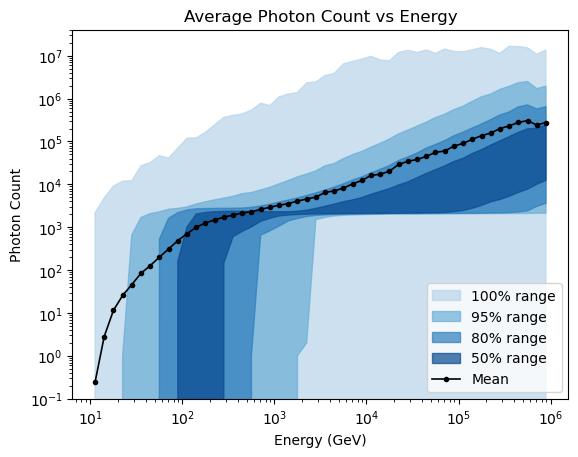

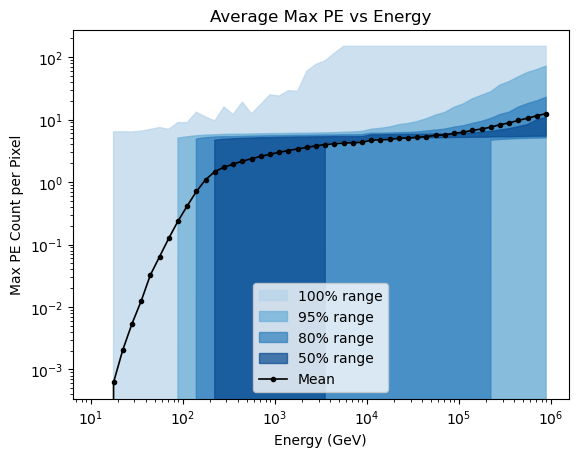

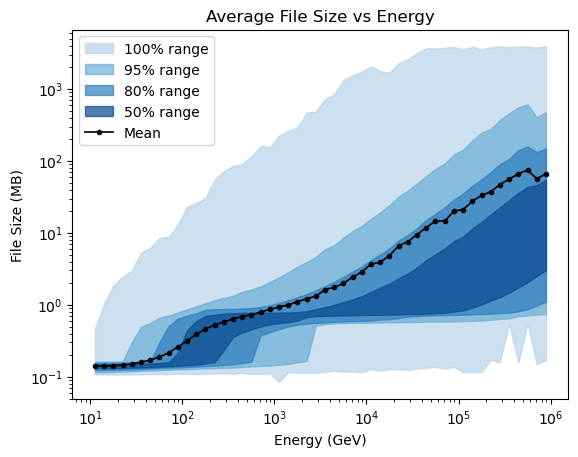

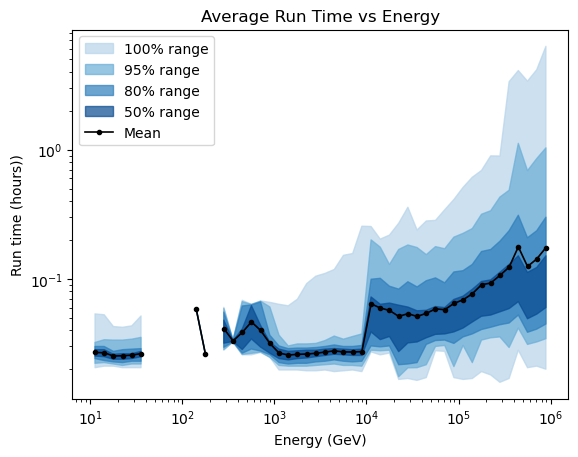

9.359598650356999 TB 4143.040145815816 photon per MB


In [161]:
#Extract data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import os
import sys
import math

# ── Configuration ─────────────────────────────────────────────────────────────
PE_THRESHOLD = 20
#N_BOOTSTRAP = 1000
#CI_LEVEL = 0.99
E_MIN_GEV = 1e1
E_MAX_GEV = 1e6
SEEDS = [1,2,3]
PID = 13
RADIUS = 5
BASE_DIR = "/scratch/general/vast/u1520754/muon_sim_chain_tree"


# ── Helper functions ─────────────────────────────────────────────────────────
def load_scan(csv_path: str) -> pd.DataFrame:
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV not found: {csv_path}")
    df = pd.read_csv(csv_path)
    n_missing = (df["file_found"] == 0).sum()
    if n_missing > 0:
        print(f"  WARNING: {n_missing} rows had file_found=0 and will be dropped.")
        index = (df["file_found"] == 0)
        """print("zenith",set(df["zen"][index]))
        print("azimuth",set(df["az"][index]))
        print("height",set(df["height"][index]))"""
    df = df[df["file_found"] == 1].copy()
    df["r"] = np.sqrt(df["tel_x"]**2 + df["tel_z"]**2).round(4)
    df["detected"] = (df["max_pe"] >= PE_THRESHOLD).astype(float)
    return df

def slant_depth(zem, obs_height, zenith_rad):
    theta = np.pi - zenith_rad
    arg = (obs_height / zem) * np.sin(theta)
    arg = np.clip(arg, -1.0, 1.0)
    beta = np.where(np.isfinite(arg), np.arcsin(arg), 0.0)
    beta = np.clip(beta, 0.0, np.pi/2)
    #beta = np.clip(np.arcsin((obs_height / zem) * np.sin(theta)), 0, np.pi/2)
    alpha = np.pi - theta - beta
    s = zem * np.sin(alpha) / np.sin(theta)
    return np.clip(s, 0, np.inf)
def incidence_angle(Zenith_deg, Azimuth_deg):
    Zenith = Zenith_deg
    Azimuth = Azimuth_deg
    cos_Zenith = np.cos(np.radians(Zenith))
    cos_Azimuth = np.cos(np.radians(Azimuth - 180))
    cos_Incidence = np.sqrt(1 - cos_Zenith**2 - cos_Azimuth**2)
    Incidence = np.degrees(np.arccos(cos_Incidence))
    return Incidence


import re
import os

def get_available_energies(base_dir, pid, radius, e_min_GeV, e_max_GeV):
    """
    Scan BASE_DIR for folders matching the given PID and RADIUS,
    extract energy values, and filter by [e_min_GeV, e_max_GeV].
    Returns sorted list of (energy_GeV, energy_str) tuples.
    """
    pattern = re.compile(
        rf"Muon_pid{pid}_E([0-9]+\.?[0-9]*e[+-]?[0-9]+)_R{radius}$"
    )
    found = {}
    for name in os.listdir(base_dir):
        m = pattern.match(name)
        if m:
            energy_str = m.group(1)
            energy_val = float(energy_str)
            if e_min_GeV <= energy_val <= e_max_GeV:
                found[energy_val] = energy_str

    return sorted(found.items())  # sorted by energy_GeV


available = get_available_energies(BASE_DIR, PID, RADIUS, E_MIN_GEV, E_MAX_GEV)
print(f"Found {len(available)} energy files between {E_MIN_GEV:.0e} and {E_MAX_GEV:.0e} GeV:")
for e_val, e_str in available:
    print(f"  E={e_str} ({e_val:.3e} GeV)")

# ── Load only those files ────────────────────────────────────────────────────
dfs = []
missing_energies = []
for energy_val, energy_str in available:
    for seed in SEEDS:
        csv_path = (f"{BASE_DIR}/Muon_pid{PID}_E{energy_str}_R{RADIUS}/"
                    f"csv_output/scan_care_pid{PID}_E{energy_str}_R{RADIUS}_y0_s{seed}.csv")
        try:
            df_tmp = load_scan(csv_path)
            df_tmp["seed"] = seed
            df_tmp["energy_string"] = energy_str
            df_tmp["energy_GeV"] = energy_val
            dfs.append(df_tmp)
            print(f"  Loaded E={energy_str} seed={seed}: {len(df_tmp)} rows")
        except Exception as e:
            missing_energies.append(energy_str)
            print(f"  ⚠ E={energy_str} seed={seed}: {e}")


df = pd.concat(dfs, ignore_index=True)
print(f"\nMerged: {len(df)} total rows from {len(dfs)} file(s)")
print(f"Energy range: {df['energy_GeV'].min():.1f} – {df['energy_GeV'].max():.1f} GeV")
if missing_energies:
    print(f"Missing energies: {sorted(set(missing_energies))}")

# ── Derived columns ──────────────────────────────────────────────────────────
R = np.array(df["r"])
X = np.array(df["tel_x"])
Z = np.array(df["tel_z"])
H = np.array(df["height"])
Zenith = np.array(df["zen"])
Azimuth = np.array(df["az"])
Max_PE = np.array(df["max_pe"])
Time_at_Max_PE = np.array(df["time_at_max_pe_ns"])
Avg_PE = np.array(df["avg_pe"])
Total_PE = np.array(df["total_pe"])
Energy_GeV = np.array(df["energy_GeV"])
Slant = slant_depth(H + 6371e3, 2944 + 6371e3, np.radians(Zenith))/1000 #km
cos_Zenith = np.cos(np.radians(Zenith))
cos_Azimuth = np.cos(np.radians(Azimuth - 180))
cos_Incidence = np.sqrt(1 - cos_Zenith**2 - cos_Azimuth**2)
Incidence = incidence_angle(Zenith, Azimuth)
#pulse_width = np.array(df["pulse_width_ns"])
#rise_time = np.array(df["rise_time_ns"])
#x_mag = np.array(df["correction_x_m"])
#y_mag = np.array(df["correction_y_m"])
file_size = np.array(df["file_size_MB"])
photon_count = np.array(df["cph_photon_count"])
#max_photon_10ns = np.array(df["cph_max_photons_10ns"])
E_list = np.sort(np.array(list(set(Energy_GeV))))
deleted_low_pe = np.array(df["deleted_low_pe"])
runtime_hours = np.array(df["runtime_seconds"])/3600 
File = []
Photon = []
PE = []
Time = []

Total_FIle_Size = np.nansum(file_size)/1000 - np.nansum(file_size[deleted_low_pe==1])/1000#MB to GB

# --- Coverage levels for nested bands ---
coverages = [50, 80, 95, 100]    # percent
cmap = plt.cm.Blues

# Storage for multi-coverage bands: dict[coverage] -> (lows, highs)
file_bands   = {c: ([], []) for c in coverages}
photon_bands = {c: ([], []) for c in coverages}
pe_bands     = {c: ([], []) for c in coverages}
time_bands     = {c: ([], []) for c in coverages}
for energy in E_list:
    mask = Energy_GeV == energy

    f  = np.nanmean(file_size[mask])
    p  = np.nanmean(photon_count[mask])
    pe = np.nanmean(Max_PE[mask])
    t = np.nanmean(runtime_hours[mask]) 

    File.append(f)
    Photon.append(p)
    PE.append(pe)
    Time.append(t)
    
    # Multi-coverage percentile bands
    for cov in coverages:
        lo_p = (100 - cov) / 2
        hi_p = 100 - lo_p
        file_bands[cov][0].append(np.nanpercentile(file_size[mask], lo_p))
        file_bands[cov][1].append(np.nanpercentile(file_size[mask], hi_p))
        photon_bands[cov][0].append(np.nanpercentile(photon_count[mask], lo_p))
        photon_bands[cov][1].append(np.nanpercentile(photon_count[mask], hi_p))
        pe_bands[cov][0].append(np.nanpercentile(Max_PE[mask], lo_p))
        pe_bands[cov][1].append(np.nanpercentile(Max_PE[mask], hi_p))
        time_bands[cov][0].append(np.nanpercentile(runtime_hours[mask], lo_p))
        time_bands[cov][1].append(np.nanpercentile(runtime_hours[mask], hi_p))
File   = np.array(File)
Photon = np.array(Photon)
PE     = np.array(PE)
Time   = np.array(Time)

for cov in coverages:
    file_bands[cov]   = (np.array(file_bands[cov][0]),   np.array(file_bands[cov][1]))
    photon_bands[cov] = (np.array(photon_bands[cov][0]), np.array(photon_bands[cov][1]))
    pe_bands[cov]     = (np.array(pe_bands[cov][0]),     np.array(pe_bands[cov][1]))
    time_bands[cov]   = (np.array(time_bands[cov][0]),     np.array(time_bands[cov][1]))

def plot_with_bands(E_list, mean, bands_dict, coverages, ylabel, title):
    fig, ax = plt.subplots()
    # Widest first (lightest), narrowest last (darkest)
    order = sorted(coverages, reverse=True)
    n = len(order)
    for i, cov in enumerate(order):
        lo, hi = bands_dict[cov]
        color = cmap(0.3 + 0.6 * (i / max(1, n - 1)))
        ax.fill_between(E_list, lo, hi, color=color, alpha=0.7,
                        label=f'{cov}% range')
    ax.plot(E_list, mean, 'k.-', lw=1.2, label='Mean')
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Energy (GeV)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    plt.show()


# --- Photon Count Plot ---
plot_with_bands(E_list, Photon, photon_bands, coverages,
                "Photon Count", "Average Photon Count vs Energy")

# --- PE Count Plot ---
plot_with_bands(E_list, PE, pe_bands, coverages,
                "Max PE Count per Pixel", "Average Max PE vs Energy")

plot_with_bands(E_list, File, file_bands, coverages,
                "File Size (MB)", "Average File Size vs Energy")

plot_with_bands(E_list, Time, time_bands, coverages,
                "Run time (hours))", "Average Run Time vs Energy")

print(Total_FIle_Size/1000, "TB", np.nanmean(Photon)/np.nanmean(File), "photon per MB")


/tmp/ipykernel_1935720/2668323990.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(Zenith[(Zenith>=89.9)&(Energy_GeV<=1e2)], Slant[(Zenith>=89.9)&(Energy_GeV<=1e2)], c = np.log10(photon_count[(Zenith>=89.9)&(Energy_GeV<=1e2)]), alpha = 0.5)


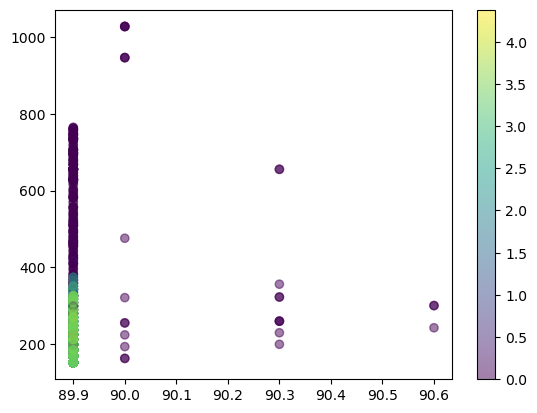

In [160]:
plt.scatter(Zenith[(Zenith>=89.9)&(Energy_GeV<=1e2)], Slant[(Zenith>=89.9)&(Energy_GeV<=1e2)], c = np.log10(photon_count[(Zenith>=89.9)&(Energy_GeV<=1e2)]), alpha = 0.5)
plt.colorbar()

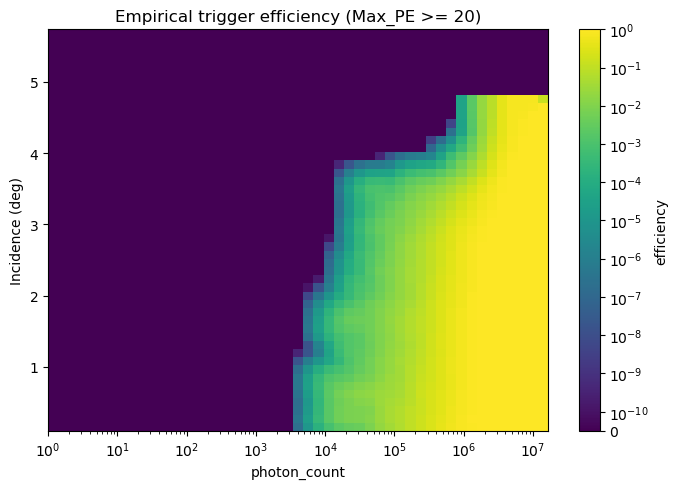

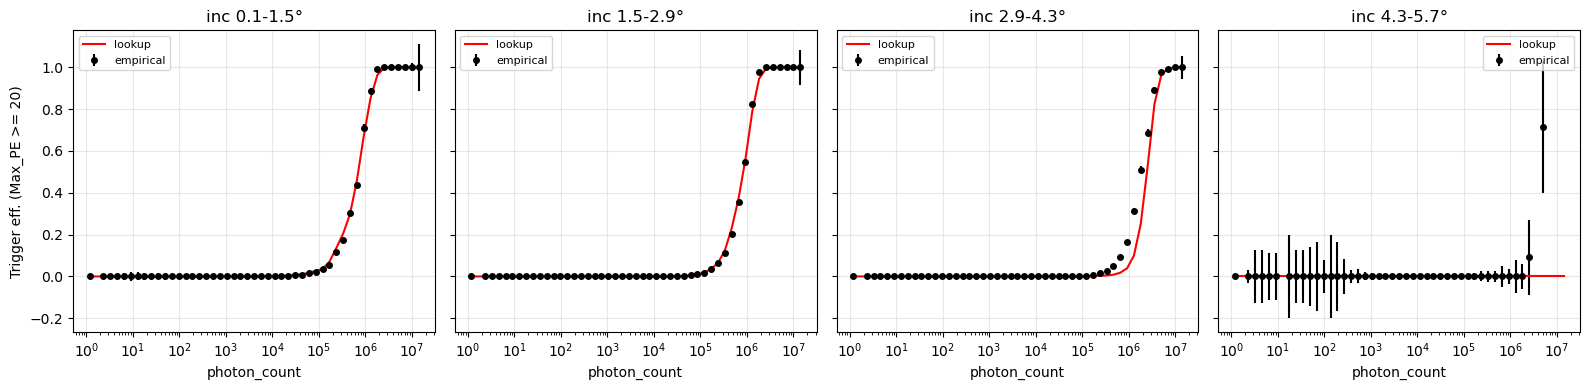

In [131]:
# Empirical trigger efficiency: P(Max_PE >= threshold | photon_count, incidence)
# =============================================================================
from scipy.ndimage import gaussian_filter
from matplotlib.colors import SymLogNorm

# ---------- 1. Clean inputs ----------
m = (np.isfinite(photon_count) & (photon_count > 0)
     & np.isfinite(Max_PE)     & (Max_PE >= 0)
     & np.isfinite(Incidence))
pc_  = photon_count[m]
pe_  = Max_PE[m]
inc_ = Incidence[m]
hit_ = (pe_ >= PE_THRESHOLD).astype(float)

# ---------- 2. Define 2-D bins ----------
pc_edges  = np.logspace(np.log10(pc_.min()), np.log10(pc_.max()), 50)
inc_edges = np.linspace(inc_.min(),inc_.max(), 50)
pc_cen    = np.sqrt(pc_edges[:-1] * pc_edges[1:])
inc_cen   = 0.5*(inc_edges[:-1] + inc_edges[1:])

# ---------- 3. Build empirical efficiency table ----------
N_tot, _, _ = np.histogram2d(pc_, inc_, bins=[pc_edges, inc_edges])
N_hit, _, _ = np.histogram2d(pc_, inc_, bins=[pc_edges, inc_edges], weights=hit_)

with np.errstate(invalid='ignore', divide='ignore'):
    eff = np.where(N_tot >= 5, N_hit / N_tot, np.nan)
    eff_err = np.where(N_tot >= 5, np.sqrt(eff*(1-eff)/N_tot), np.nan)

# Light smoothing to fill noisy bins (optional)
eff_smooth = eff.copy()
mask = np.isfinite(eff_smooth)
eff_smooth[~mask] = 0
weights = mask.astype(float)
eff_smooth = gaussian_filter(eff_smooth, sigma=0.8) / np.clip(
    gaussian_filter(weights, sigma=0.8), 1e-6, None)

# ---------- 4. Lookup function with bilinear interpolation ----------
from scipy.interpolate import RegularGridInterpolator
interp = RegularGridInterpolator(
    (np.log10(pc_cen), inc_cen), eff_smooth,
    bounds_error=False, fill_value=None, method='linear')

def trigger_eff(N_gamma, inc_deg):
    N_gamma = np.asarray(N_gamma, dtype=float)
    inc_deg = np.asarray(inc_deg, dtype=float)
    N_b, inc_b = np.broadcast_arrays(N_gamma, inc_deg)
    pts = np.column_stack([
        np.log10(np.clip(N_b.ravel(), pc_.min(), pc_.max())),
        np.clip(inc_b.ravel(), inc_.min(), inc_.max()),
    ])
    vals = np.clip(interp(pts), 0.0, 1.0)
    return vals.reshape(N_b.shape)

# ---------- 5. Plot the efficiency map ----------
fig, ax = plt.subplots(figsize=(7,5))
pcm = ax.pcolormesh(pc_edges, inc_edges, eff_smooth.T,
                    cmap='viridis', norm=SymLogNorm(linthresh=np.min(eff_smooth[np.where(eff_smooth>0)]), linscale=0.5, base=10))
ax.set_xscale('log')
ax.set_xlabel("photon_count"); ax.set_ylabel("Incidence (deg)")
ax.set_title(f"Empirical trigger efficiency (Max_PE >= {PE_THRESHOLD})")
plt.colorbar(pcm, ax=ax, label='efficiency')
plt.tight_layout(); plt.show()

# ---------- 6. Slice validation ----------
bounds = np.linspace(inc_.min(), inc_.max(), 5)
slices = list(zip(bounds[:-1], bounds[1:]))
fig, axes = plt.subplots(1, len(slices), figsize=(4*len(slices), 4), sharey=True)
for ax, (ilo, ihi) in zip(axes, slices):
    sel = (inc_ >= ilo) & (inc_ < ihi)
    emp, err = [], []
    for i in range(len(pc_cen)):
        s2 = sel & (pc_ >= pc_edges[i]) & (pc_ < pc_edges[i+1])
        n = s2.sum()
        if n >= 5:
            p = np.mean(hit_[s2]); emp.append(p)
            err.append(np.sqrt(p*(1-p)/n) + 1.0/n)
        else:
            emp.append(np.nan); err.append(np.nan)
    emp, err = np.array(emp), np.array(err)
    pred = trigger_eff(pc_cen, 0.5*(ilo+ihi))
    ax.errorbar(pc_cen, emp, yerr=err, fmt='ko', ms=4, label='empirical')
    ax.plot(pc_cen, pred, 'r-', label='lookup')
    ax.set_xscale('log')#; ax.set_ylim(-0.05, 1.1)
    #ax.set_yscale('log')
    ax.set_xlabel("photon_count")
    ax.set_title(f"inc {ilo:.1f}-{ihi:.1f}°")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
axes[0].set_ylabel(f"Trigger eff. (Max_PE >= {PE_THRESHOLD})")
plt.tight_layout(); plt.show()


PER-BIN LOGISTIC FIT DIAGNOSTICS (eff vs photon count, per incidence bin)
Fit equation: eff(logN) = b / (1 + exp(-(logN - x0) / w))
Error bars:   bootstrap 68% CI (N_boot=100)
--------------------------------------------------------------------------------
  inc_mean     b(sat)       +/-b   x0(logN50)      +/-x0    w(logN)       +/-w   chi2/dof     minN
--------------------------------------------------------------------------------
     0.100       1.01      0.012        5.690      0.028      0.088       0.03       1.18     6951
     0.200       1.01      0.011        5.689      0.023      0.126      0.035       1.40     6951
     0.300       1.01     0.0063        5.686      0.037      0.149      0.039       3.83    20959
     0.400       1.01      0.007        5.727      0.022      0.150      0.029       2.41    14081
     0.500       1.01     0.0074        5.717      0.022      0.127      0.024       2.22    14081
     0.600       1.01     0.0052        5.735      0.026      0.139 

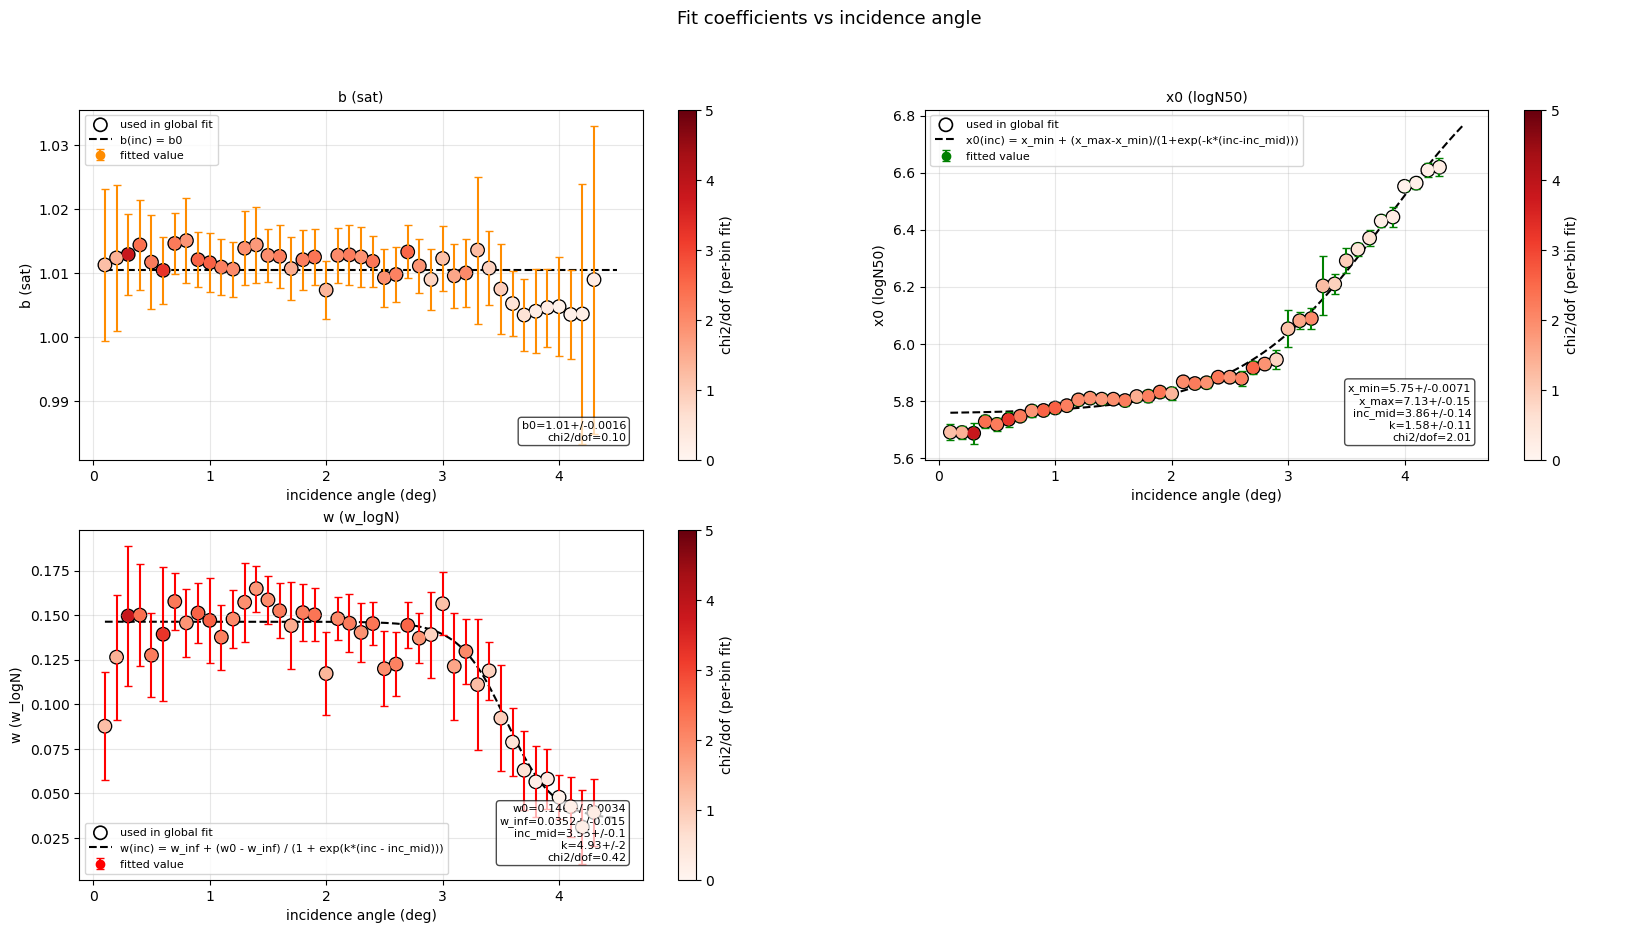


PHYSICAL MODEL FITS (coefficient vs incidence angle)

--- Model for parameter 'b' ---
Equation:  b(inc) = b0
            b0 = 1.011 +/- 0.0016
      chi2/dof = 0.099

--- Model for parameter 'x0' ---
Equation:  x0(inc) = x_min + (x_max-x_min)/(1+exp(-k*(inc-inc_mid)))
         x_min = 5.754 +/- 0.0071
         x_max = 7.134 +/- 0.15
       inc_mid = 3.861 +/- 0.14
             k = 1.576 +/- 0.11
      chi2/dof = 2.008

--- Model for parameter 'w' ---
Equation:  w(inc) = w_inf + (w0 - w_inf) / (1 + exp(k*(inc - inc_mid)))
            w0 = 0.1463 +/- 0.0034
         w_inf = 0.03515 +/- 0.015
       inc_mid = 3.547 +/- 0.1
             k = 4.928 +/- 2
      chi2/dof = 0.416


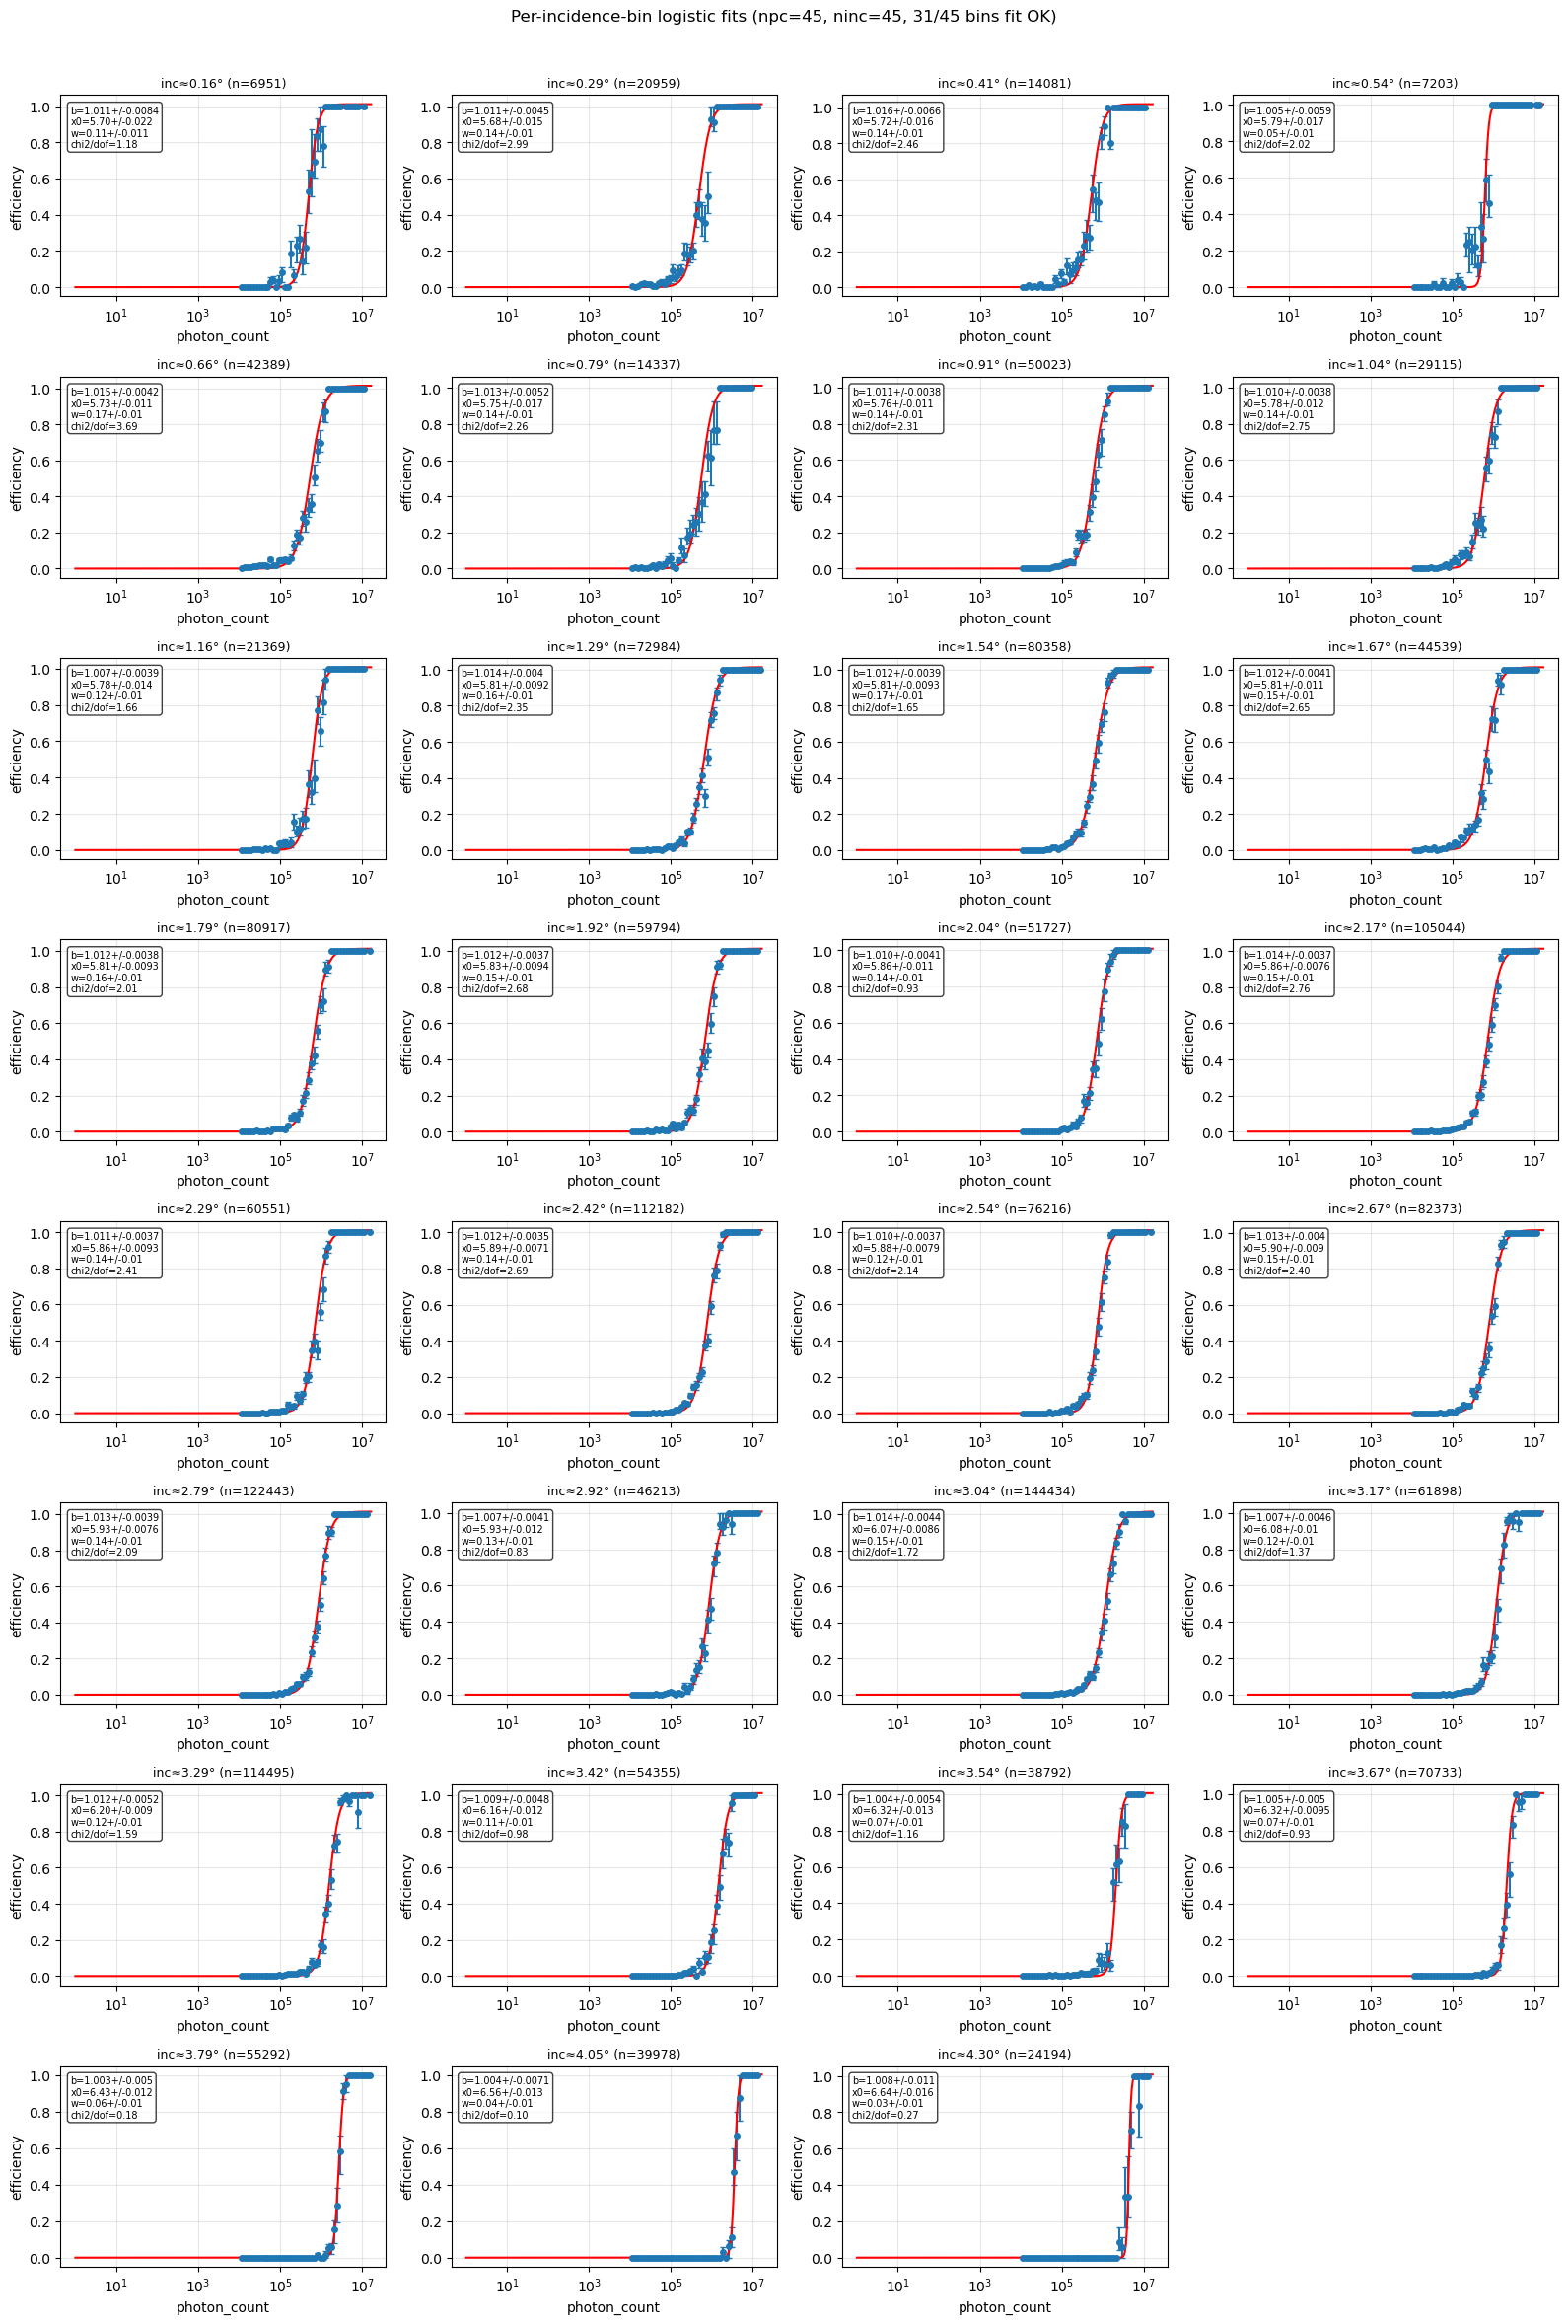

In [132]:
# Fitting Efficiency vs Photon Count Model (per incidence bin)
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.optimize import curve_fit

# --- User settings ---
#PE_THRESHOLD = 5
n_photon_bins = 20
n_inc_bins = 20
ncols = 5

MIN_EVENTS_PER_INC_BIN = 2
MIN_EVENTS_PER_PC_BIN = 5
MAX_CHI2_DOF = 5.0
MAX_X0_ERR_LOGN = 0.5
MAX_W_ERR_LOGN = 0.5
EFF_ERR_FLOOR = 0.01
B_ERR_FLOOR = 0.01
W_ERR_FLOOR = 0.01
SATURATION_EFF = 1

B_MODEL  = "const"   # options: "const", "linear"
X0_MODEL = "log_sigmoid"  # options: "linear", "quadratic", "log_sigmoid"
W_MODEL  = "sigmoid"   # options: "const", "linear", "powerlaw", "lognormal", "sigmoid"

N_BIN_VARIATIONS = 50
NPC_RANGE  = (10, 80)
NINC_RANGE = (10, 80)

N_BOOTSTRAP = 100
CI_LEVEL = 68  # percent 68
CI_ALPHA = (100.0 - CI_LEVEL) / 2.0

_RNG = np.random.default_rng(0)

# ---- preprocess ----
mask = (
    np.isfinite(photon_count) & (photon_count > 0) &
    np.isfinite(Max_PE) & (Max_PE >= 0) &
    np.isfinite(Incidence)
)

pc = photon_count[mask]
inc = Incidence[mask]
pe = Max_PE[mask]
trig = (pe >= PE_THRESHOLD).astype(float)

pc_for_edges = pc[trig > 0]
if pc_for_edges.size == 0:
    raise ValueError("No triggered events to define photon-count bin edges.")

pc_edges = np.logspace(np.log10(pc_for_edges.min()), np.log10(pc_for_edges.max()), n_photon_bins + 1)
n_photon_bins = len(pc_edges) - 1
inc_edges = np.linspace(inc.min(), inc.max(), n_inc_bins + 1)

def logistic_logN(logN, b, x0, w):
    exponent = np.clip(-(logN - x0) / w, -500, 500)
    return b / (1.0 + np.exp(exponent))

# ---- helper: compute bootstrap eff/err arrays for a slice ----
def compute_bootstrap_arrays(pc_slice, trig_slice, pc_edges_v, rng=_RNG):
    n_bins = len(pc_edges_v) - 1

    idx = np.digitize(pc_slice, pc_edges_v) - 1
    valid = (idx >= 0) & (idx < n_bins)
    idx = idx[valid]
    t = trig_slice[valid]

    total = np.bincount(idx, minlength=n_bins).astype(int)
    hits = np.bincount(idx, weights=t, minlength=n_bins)

    with np.errstate(invalid="ignore", divide="ignore"):
        p_hat = np.where(total > 0, hits / np.maximum(total, 1), np.nan)

    safe_n = np.where(total > 0, total, 1)
    safe_p = np.where(np.isfinite(p_hat), p_hat, 0.0)

    boot = rng.binomial(safe_n[None, :], safe_p[None, :],
                        size=(N_BOOTSTRAP, n_bins)) / safe_n[None, :]
    lo = np.percentile(boot, CI_ALPHA, axis=0)
    hi = np.percentile(boot, 100.0 - CI_ALPHA, axis=0)

    err_lo = p_hat - lo
    err_hi = hi - p_hat
    err = np.maximum((hi - lo) / 2.0, EFF_ERR_FLOOR)

    empty = (total == 0)
    for a in (p_hat, err, err_lo, err_hi):
        a[empty] = np.nan

    return p_hat, err, err_lo, err_hi, total


def fit_one_inc_bin(inc_lo, inc_hi, pc_edges_v, rng):
    inc_center = 0.5 * (inc_lo + inc_hi)
    sub = (inc >= inc_lo) & (inc < inc_hi)
    n_sub = int(sub.sum())

    res = {
        "inc_lo": inc_lo,
        "inc_hi": inc_hi,
        "inc_center": inc_center,
        "n_sub": n_sub,
        "ok": False,
        "skip_reason": None,
    }

    if n_sub < MIN_EVENTS_PER_INC_BIN:
        res["skip_reason"] = "low_events"
        return res

    pc_sub = pc[sub]
    trig_sub = trig[sub]

    eff, err, err_lo, err_hi, total = compute_bootstrap_arrays(
        pc_sub, trig_sub, pc_edges_v, rng=rng
    )
    pc_centers = np.sqrt(pc_edges_v[:-1] * pc_edges_v[1:])
    res.update({
        "pc_centers": pc_centers,
        "eff": eff,
        "err": err,
        "err_lo": err_lo,
        "err_hi": err_hi,
        "total": total,
    })

    eff_valid = eff[np.isfinite(eff)]
    saturated = bool(eff_valid.size > 0 and np.all(eff_valid >= SATURATION_EFF))
    good = np.isfinite(eff) & (total >= MIN_EVENTS_PER_PC_BIN)

    res.update({
        "good": good,
        "saturated": saturated,
        "min_total": int(np.min(total[total > 0])) if np.any(total > 0) else 0,
    })

    if good.sum() < 4:
        res["skip_reason"] = "low_stats"
        return res
    if saturated:
        res["skip_reason"] = "saturated"
        return res

    xd = np.log10(pc_centers[good])
    yd = eff[good]
    sd = np.where(err[good] > 0, err[good], EFF_ERR_FLOOR)

    x_range = xd.max() - xd.min()
    b0 = min(max(np.nanmax(yd), 0.05), 1.0)
    x0_0 = xd[np.argmin(np.abs(yd - 0.5 * b0))]
    w0 = max(0.1 * x_range, 1e-3)

    p0 = [b0, x0_0, w0]
    bounds = (
        [0.0, xd.min(), 1e-3],
        [1.05, xd.max(), 5.0],
    )

    def _logistic_logN_logw(logN, b, x0, log_w):
        """Wrapper that accepts log(w) so w is always positive."""
        return logistic_logN(logN, b, x0, np.exp(log_w))

    p0_lw    = [p0[0], p0[1], np.log(max(p0[2], 1e-3))]
    bounds_lw = (
        [bounds[0][0], bounds[0][1], np.log(1e-3)],
        [bounds[1][0], bounds[1][1], np.log(5.0)],
    )

    try:
        popt_lw, pcov_lw = curve_fit(
            _logistic_logN_logw, xd, yd, p0=p0_lw, sigma=sd,
            absolute_sigma=True, bounds=bounds_lw, maxfev=20000
        )
        # Convert back to (b, x0, w) space for all downstream code
        popt = np.array([popt_lw[0], popt_lw[1], np.exp(popt_lw[2])])
        # Propagate uncertainty via delta method: sigma_w = exp(log_w) * sigma_log_w
        perr_lw = np.sqrt(np.diag(pcov_lw))
        perr_w  = np.exp(popt_lw[2]) * perr_lw[2]
        # Rebuild pcov in (b, x0, w) space (off-diagonals are approximate)
        pcov = pcov_lw.copy()
        pcov[2, :] *= np.exp(popt_lw[2])
        pcov[:, 2] *= np.exp(popt_lw[2])
    except Exception:
        res["skip_reason"] = "fit_failed"
        return res

    perr = np.sqrt(np.diag(pcov))
    # Ensure w uncertainty is physically meaningful (always positive)
    perr[2] = max(perr[2], W_ERR_FLOOR)

    y_model = logistic_logN(xd, *popt)
    chi2 = np.sum(((yd - y_model) / sd) ** 2)
    dof = len(xd) - 3
    chi2_dof = chi2 / dof if dof > 0 else np.nan

    ok = True
    if not np.isfinite(chi2_dof) or chi2_dof >= MAX_CHI2_DOF:
        ok = False
    if perr[1] >= MAX_X0_ERR_LOGN or perr[2] >= MAX_W_ERR_LOGN:
        ok = False

    res.update({
        "popt": popt,
        "perr": perr,
        "chi2_dof": chi2_dof,
        "ok": ok,
    })

    if not ok:
        res["skip_reason"] = "quality_cuts"

    return res

# ======================================================================
# Bin-variation loop (binning systematic)
# ======================================================================
agg = defaultdict(list)
agg_perr = defaultdict(list)
agg_chi2 = defaultdict(list)
agg_nsub = defaultdict(list)
agg_skip = defaultdict(lambda: defaultdict(int))

log_pc_min = np.log10(pc_for_edges.min())
log_pc_max = np.log10(pc_for_edges.max())

bin_results = [] if N_BIN_VARIATIONS == 1 else None

for v in range(N_BIN_VARIATIONS):
    rng_v = np.random.default_rng(1000 + v)
    if N_BIN_VARIATIONS == 1:
        npc = n_photon_bins
        ninc = n_inc_bins
    else:
        npc = int(rng_v.integers(NPC_RANGE[0], NPC_RANGE[1] + 1))
        ninc = int(rng_v.integers(NINC_RANGE[0], NINC_RANGE[1] + 1))

    pc_edges_v = np.logspace(log_pc_min, log_pc_max, npc + 1)
    inc_edges_v = np.linspace(inc.min(), inc.max(), ninc + 1)

    for i in range(ninc):
        inc_lo, inc_hi = inc_edges_v[i], inc_edges_v[i + 1]
        res = fit_one_inc_bin(inc_lo, inc_hi, pc_edges_v, rng_v)

        if N_BIN_VARIATIONS == 1:
            bin_results.append(res)

        if not res.get("ok", False):
            reason = res.get("skip_reason", "unknown")
            key_r = round(res["inc_center"], 1)
            agg_skip[key_r][reason] += 1
            continue

        key = round(res["inc_center"], 1)
        agg[key].append(res["popt"])
        agg_perr[key].append(res["perr"])
        agg_chi2[key].append(res["chi2_dof"])
        agg_nsub[key].append(res["n_sub"])

# ======================================================================
# Aggregate across binning variations
# ======================================================================
keys_sorted = sorted(agg.keys())
inc_means = np.array(keys_sorted)

b_vals  = np.array([np.median([p[0] for p in agg[k]]) for k in keys_sorted])
x0_vals = np.array([np.median([p[1] for p in agg[k]]) for k in keys_sorted])
w_vals  = np.array([np.median([p[2] for p in agg[k]]) for k in keys_sorted])


def _combined_err(popts, perrs, idx):
    vals = np.array([p[idx] for p in popts])
    stat = np.array([e[idx] for e in perrs])
    syst = vals.std(ddof=1) if len(vals) > 1 else 0.0
    return np.sqrt(np.median(stat) ** 2 + syst ** 2)


b_errs  = np.array([_combined_err(agg[k], agg_perr[k], 0) for k in keys_sorted])
x0_errs = np.array([_combined_err(agg[k], agg_perr[k], 1) for k in keys_sorted])
w_errs  = np.array([_combined_err(agg[k], agg_perr[k], 2) for k in keys_sorted])

chi2_vals = np.array([np.median(agg_chi2[k]) for k in keys_sorted])
n_variations_per_key = np.array([len(agg[k]) for k in keys_sorted])
min_counts = np.array([int(np.median(agg_nsub[k])) for k in keys_sorted])

finite_mask = np.isfinite(b_vals) & np.isfinite(x0_vals) & np.isfinite(w_vals)
stats_mask = n_variations_per_key >= max(3, N_BIN_VARIATIONS // 10)
chi2_mask = chi2_vals < MAX_CHI2_DOF
quality_mask = finite_mask & stats_mask & chi2_mask

# ======================================================================
# Diagnostics print
# ======================================================================
print("=" * 80)
print("PER-BIN LOGISTIC FIT DIAGNOSTICS (eff vs photon count, per incidence bin)")
print("=" * 80)
print("Fit equation: eff(logN) = b / (1 + exp(-(logN - x0) / w))")
print(f"Error bars:   bootstrap {CI_LEVEL:.0f}% CI (N_boot={N_BOOTSTRAP})")
print("-" * 80)
print(f"{'inc_mean':>10} {'b(sat)':>10} {'+/-b':>10} {'x0(logN50)':>12} "
      f"{'+/-x0':>10} {'w(logN)':>10} {'+/-w':>10} {'chi2/dof':>10} {'minN':>8}")
print("-" * 80)
for i in range(len(inc_means)):
    print(f"{inc_means[i]:10.3f} "
          f"{b_vals[i]:10.3g} {b_errs[i]:10.2g} "
          f"{x0_vals[i]:12.3f} {x0_errs[i]:10.2g} "
          f"{w_vals[i]:10.3f} {w_errs[i]:10.2g} "
          f"{chi2_vals[i]:10.2f} {min_counts[i]:8d}")
print("-" * 80)
print(f"Bins fitted: {len(inc_means)} | Bins used for global fits: {int(np.sum(quality_mask))}")
print("=" * 80)
print("\nBIN STABILITY ACROSS BINNING VARIATIONS (skip_reason counts):")
print(f"{'inc_mean':>10} {'ok_count':>10} {'low_events':>12} {'low_stats':>10} "
      f"{'saturated':>10} {'fit_failed':>10} {'quality_cuts':>13} {'unknown':>8}")
print("-" * 90)
for k in keys_sorted:
    n_ok  = len(agg[k])
    skips = agg_skip.get(k, {})
    print(f"{k:10.3f} {n_ok:10d} "
          f"{skips.get('low_events', 0):12d} "
          f"{skips.get('low_stats', 0):10d} "
          f"{skips.get('saturated', 0):10d} "
          f"{skips.get('fit_failed', 0):10d} "
          f"{skips.get('quality_cuts', 0):13d} "
          f"{skips.get('unknown', 0):8d}")
print("-" * 90)
print(f"Note: ok_count + all skip counts should sum to approximately "
      f"N_BIN_VARIATIONS={N_BIN_VARIATIONS} per row (variation in ninc "
      f"means not every variation produces an inc bin at that center).")
dropped = ~quality_mask
if np.any(dropped):
    print("\nBins EXCLUDED from global fits:")
    print(f"{'inc_mean':>10} {'b/err_b':>10} {'chi2/dof':>10} {'minN':>8}  reasons")
    min_req = max(3, N_BIN_VARIATIONS // 10)
    for i in np.where(dropped)[0]:
        reasons = []
        if not finite_mask[i]:
            reasons.append("nonfinite")
        if not stats_mask[i]:
            reasons.append(f"minN<{min_req}")
        if not chi2_mask[i]:
            reasons.append(f"chi2>{MAX_CHI2_DOF}")
        bs = b_vals[i] / b_errs[i] if np.isfinite(b_errs[i]) and b_errs[i] > 0 else 0.0
        print(f"{inc_means[i]:10.3f} {bs:10.2f} {chi2_vals[i]:10.2f} "
              f"{min_counts[i]:8d}  " + ", ".join(reasons))

if len(inc_means) == 0:
    raise RuntimeError("No valid incidence bins available for global fits.")

# ======================================================================
# Global models: b(inc), x0(inc), w(inc)
# ======================================================================

def b_const(inc_deg, b0):
    return np.full_like(inc_deg, b0, dtype=float)


def b_linear(inc_deg, b0, s):
    return b0 + s * inc_deg


def x0_linear(inc_deg, a, s):
    return a + s * inc_deg


def x0_quadratic(inc_deg, a, s, q):
    return a + s * inc_deg + q * inc_deg**2


def x0_log_sigmoid(inc_deg, x_min, x_max, inc_mid, k):
    return x_min + (x_max - x_min) / (1.0 + np.exp(-k * (inc_deg - inc_mid)))


def w_const(inc_deg, w0):
    return np.full_like(inc_deg, w0, dtype=float)


def w_linear(inc_deg, w0, s):
    return w0 + s * inc_deg


def w_powerlaw(inc_deg, w0, k):
    return w0 * (1.0 + inc_deg) ** k


def w_lognormal(inc_deg, w0, mu, sigma):
    # Gaussian in log(inc); guard inc>0
    x = np.log(np.maximum(inc_deg, 1e-6))
    return w0 * np.exp(-((x - mu) / sigma) ** 2)

def w_sigmoid(inc_deg, w0, w_inf, inc_mid, k):
    # w0 at low inc, w_inf at high inc, transition at inc_mid with steepness k
    return w_inf + (w0 - w_inf) / (1.0 + np.exp(k * (inc_deg - inc_mid)))

inc_min = float(np.min(inc_means)) if len(inc_means) else float(np.min(inc))
inc_max = float(np.max(inc_means)) if len(inc_means) else float(np.max(inc))
x0_min = float(np.nanmin(x0_vals)) if len(x0_vals) else np.log10(pc_for_edges.min())
x0_max = float(np.nanmax(x0_vals)) if len(x0_vals) else np.log10(pc_for_edges.max())

b_model_cfg = {
    "const": {
        "fn": b_const,
        "p0": [np.nanmedian(b_vals)],
        "bounds": ([0.0], [1.05]),
        "label": "b(inc) = b0",
        "param_names": ["b0"],
    },
    "linear": {
        "fn": b_linear,
        "p0": [np.nanmedian(b_vals), 0.0],
        "bounds": ([0.0, -0.1], [1.05, 0.1]),
        "label": "b(inc) = b0 + s*inc",
        "param_names": ["b0", "s"],
    },
}

x0_model_cfg = {
    "linear": {
        "fn": x0_linear,
        "p0": [np.nanmedian(x0_vals), 0.0],
        "bounds": ([x0_min - 2.0, -1.0], [x0_max + 2.0, 1.0]),
        "label": "x0(inc) = a + s*inc",
        "param_names": ["a", "s"],
    },
    "quadratic": {
        "fn": x0_quadratic,
        "p0": [np.nanmedian(x0_vals), 0.0, 0.0],
        "bounds": ([x0_min - 2.0, -1.0, -0.1], [x0_max + 2.0, 1.0, 0.1]),
        "label": "x0(inc) = a + s*inc + q*inc^2",
        "param_names": ["a", "s", "q"],
    },
    "log_sigmoid": {
        "fn": x0_log_sigmoid,
        "p0": [x0_min, x0_max, 0.5 * (inc_min + inc_max), 1.0],
        "bounds": ([x0_min - 2.0, x0_min, inc_min, 0.01],
                   [x0_max, x0_max + 2.0, inc_max, 10.0]),
        "label": "x0(inc) = x_min + (x_max-x_min)/(1+exp(-k*(inc-inc_mid)))",
        "param_names": ["x_min", "x_max", "inc_mid", "k"],
    },
}

w_model_cfg = {
    "const": {
        "fn": w_const,
        "p0": [np.nanmedian(w_vals)],
        "bounds": ([1e-3], [5.0]),
        "label": "w(inc) = w0",
        "param_names": ["w0"],
    },
    "linear": {
        "fn": w_linear,
        "p0": [np.nanmedian(w_vals), 0.0],
        "bounds": ([1e-3, -1.0], [5.0, 1.0]),
        "label": "w(inc) = w0 + s*inc",
        "param_names": ["w0", "s"],
    },
    "powerlaw": {
        "fn": w_powerlaw,
        "p0": [np.nanmedian(w_vals), 0.0],
        "bounds": ([1e-3, -3.0], [5.0, 3.0]),
        "label": "w(inc) = w0 * (1 + inc)^k",
        "param_names": ["w0", "k"],
    },
    "lognormal": {
        "fn": w_lognormal,
        "p0": [np.nanmax(w_vals),
               np.log(max(inc_means[np.nanargmax(w_vals)], 1e-3)),
               1.0],
        "bounds": ([1e-3, np.log(max(inc_min, 1e-3)) - 5.0, 1e-2],
                   [5.0,  np.log(max(inc_max, 1e-3)) + 5.0, 10.0]),
        "label": "w(inc) = w0 * exp(-((log(inc) - mu)/sigma)^2)",
        "param_names": ["w0", "mu", "sigma"],
    },
    "sigmoid": {
        "fn": w_sigmoid,
        "p0": [
            np.nanmedian(w_vals),                 # w0: low-inc plateau
            min(0.01, np.nanmin(w_vals)),         # w_inf: high-inc asymptote
            0.5 * (inc_min + inc_max),            # inc_mid: transition point
            5.0,                                  # k: steepness
        ],
        "bounds": (
            [1e-3, 0.0, inc_min, 0.01],
            [5.0,  5.0, inc_max, 100.0],
        ),
        "label": "w(inc) = w_inf + (w0 - w_inf) / (1 + exp(k*(inc - inc_mid)))",
        "param_names": ["w0", "w_inf", "inc_mid", "k"],
    },
}

if B_MODEL not in b_model_cfg:
    raise ValueError(f"Unknown B_MODEL='{B_MODEL}'. Use 'const' or 'linear'.")
if X0_MODEL not in x0_model_cfg:
    raise ValueError(f"Unknown X0_MODEL='{X0_MODEL}'. Use 'linear', 'quadratic', or 'log_sigmoid'.")
if W_MODEL not in w_model_cfg:
    raise ValueError(f"Unknown W_MODEL='{W_MODEL}'. Use 'const', 'linear', 'powerlaw', 'lognormal', or 'sigmoid'.")


b_model = b_model_cfg[B_MODEL]
x0_model = x0_model_cfg[X0_MODEL]
w_model = w_model_cfg[W_MODEL]


def fit_model(fn, xdata, ydata, yerr, p0, bounds):
    sigma = np.where(yerr > 0, yerr, EFF_ERR_FLOOR)
    popt, pcov = curve_fit(
        fn, xdata, ydata, p0=p0, sigma=sigma,
        absolute_sigma=True, bounds=bounds, maxfev=20000
    )
    perr = np.sqrt(np.diag(pcov))
    residuals = ydata - fn(xdata, *popt)
    chi2 = np.sum((residuals / sigma) ** 2)
    dof = len(xdata) - len(popt)
    chi2_dof = chi2 / dof if dof > 0 else np.nan
    return popt, perr, pcov, chi2_dof


results = {}
results_meta = {}

ok_b = quality_mask & np.isfinite(b_errs)
ok_x0 = quality_mask & np.isfinite(x0_errs)
ok_w = quality_mask & np.isfinite(w_errs)

try:
    popt, perr, pcov, c2 = fit_model(
        b_model["fn"], inc_means[ok_b], b_vals[ok_b],
        np.maximum(b_errs[ok_b], B_ERR_FLOOR),
        p0=b_model["p0"], bounds=b_model["bounds"],
    )
    results["b"] = (popt, perr, pcov)
    results_meta["b"] = {"chi2_dof": c2, "model": B_MODEL}
except Exception as e:
    print(f"b model fit failed: {e}")

try:
    popt, perr, pcov, c2 = fit_model(
        x0_model["fn"], inc_means[ok_x0], x0_vals[ok_x0],
        np.maximum(x0_errs[ok_x0], W_ERR_FLOOR),
        p0=x0_model["p0"], bounds=x0_model["bounds"],
    )
    results["x0"] = (popt, perr, pcov)
    results_meta["x0"] = {"chi2_dof": c2, "model": X0_MODEL}
except Exception as e:
    print(f"x0 model fit failed: {e}")

try:
    popt, perr, pcov, c2 = fit_model(
        w_model["fn"], inc_means[ok_w], w_vals[ok_w],
        np.maximum(w_errs[ok_w], W_ERR_FLOOR),
        p0=w_model["p0"], bounds=w_model["bounds"],
    )
    results["w"] = (popt, perr, pcov)
    results_meta["w"] = {"chi2_dof": c2, "model": W_MODEL}
except Exception as e:
    print(f"w model fit failed: {e}")
# ======================================================================
# Empirical cross-group correlation of (b, x0, w) from binning variations
# ======================================================================
# For each quality-masked incidence bin, agg[k] holds a list of (b, x0, w)
# triplets — one per binning variation that passed quality cuts. The empirical
# 3x3 covariance of those triplets captures how b, x0, w co-vary in practice.
# Pooling across bins gives a representative correlation matrix that Cell 4
# uses to populate the off-diagonal blocks of the joint parameter covariance.

_emp_covs_list = []
for k, qm in zip(keys_sorted, quality_mask):
    if not qm:
        continue
    if len(agg[k]) < 4:          # need at least 4 samples for a meaningful estimate
        continue
    _triplets = np.array(agg[k])  # (n_variations, 3): columns = [b, x0, w]
    _emp_covs_list.append(np.cov(_triplets.T))   # (3, 3)

if len(_emp_covs_list) > 0:
    _EMP_JOINT_COV_3x3_raw = np.mean(_emp_covs_list, axis=0)   # (3, 3) pooled

    # Convert to correlation matrix: C_ij / (sigma_i * sigma_j)
    _std3 = np.sqrt(np.maximum(np.diag(_EMP_JOINT_COV_3x3_raw), 0.0))
    _outer_std = np.outer(_std3, _std3)
    EMP_JOINT_CORR_3x3 = np.where(
        _outer_std > 0,
        _EMP_JOINT_COV_3x3_raw / _outer_std,
        0.0,
    )
    # Clip to valid correlation range for numerical safety
    np.clip(EMP_JOINT_CORR_3x3, -1.0, 1.0, out=EMP_JOINT_CORR_3x3)
    # Force exact diagonal = 1 (rounding can push it slightly off)
    np.fill_diagonal(EMP_JOINT_CORR_3x3, 1.0)

    print("\nEmpirical cross-group correlation matrix (b, x0, w):")
    print(f"  Pooled from {len(_emp_covs_list)} quality bins "
          f"(min 4 variations each)")
    print(f"  ρ(b,  x0) = {EMP_JOINT_CORR_3x3[0, 1]:.4f}")
    print(f"  ρ(b,   w) = {EMP_JOINT_CORR_3x3[0, 2]:.4f}")
    print(f"  ρ(x0,  w) = {EMP_JOINT_CORR_3x3[1, 2]:.4f}")
else:
    EMP_JOINT_CORR_3x3 = np.eye(3, dtype=float)
    print("\nWarning: no quality bins had >= 4 binning variations. "
          "EMP_JOINT_CORR_3x3 set to identity (zero cross-group correlations).")

del _emp_covs_list
# ======================================================================
# Comparison plot: coefficients vs incidence
# ======================================================================
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
axes = axes.ravel()

inc_smooth = np.linspace(inc_means.min(), inc_means.max(), 300)

labels = ["b (sat)", "x0 (logN50)", "w (w_logN)"]
yvals = [b_vals, x0_vals, w_vals]
yerrs = [b_errs, x0_errs, w_errs]
colors = ["darkorange", "green", "red"]
model_keys = ["b", "x0", "w"]
model_fns = [b_model["fn"], x0_model["fn"], w_model["fn"]]
model_labels = {
    "b": b_model["label"],
    "x0": x0_model["label"],
    "w": w_model["label"],
}
param_names = {
    "b": b_model["param_names"],
    "x0": x0_model["param_names"],
    "w": w_model["param_names"],
}

for ax, lbl, yv, ye, col, mkey, mfn in zip(
        axes[:len(labels)], labels, yvals, yerrs, colors, model_keys, model_fns):

    qm = quality_mask
    ax.errorbar(inc_means[qm], yv[qm], yerr=ye[qm], fmt="o", color=col,
                capsize=3, label="fitted value", zorder=3)
    sc = ax.scatter(inc_means[qm], yv[qm], c=chi2_vals[qm], cmap="Reds",
                    vmin=0, vmax=5, zorder=5, s=60)
    plt.colorbar(sc, ax=ax, label="chi2/dof (per-bin fit)")
    ax.scatter(inc_means[qm], yv[qm],
               facecolors="none", edgecolors="black", s=90,
               linewidths=1.2, label="used in global fit")

    if mkey in results:
        popt, perr, _ = results[mkey]
        c2 = results_meta.get(mkey, {}).get("chi2_dof", np.nan)
        ax.plot(inc_smooth, mfn(inc_smooth, *popt), "k--",
                lw=1.5, label=model_labels[mkey])
        txt = "\n".join(f"{n}={v:.3g}+/-{e:.2g}"
                        for n, v, e in zip(param_names[mkey], popt, perr))
        txt += f"\nchi2/dof={c2:.2f}"
        ax.text(0.97, 0.05, txt, transform=ax.transAxes, fontsize=8,
                ha="right", va="bottom",
                bbox=dict(boxstyle="round", fc="white", alpha=0.7))

    ax.set_xlabel("incidence angle (deg)")
    ax.set_ylabel(lbl)
    ax.set_title(lbl, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

for ax in axes[len(labels):]:
    ax.axis("off")

fig.suptitle("Fit coefficients vs incidence angle", fontsize=13)
plt.show()

# ======================================================================
# Physical model summary
# ======================================================================
print("\n" + "=" * 80)
print("PHYSICAL MODEL FITS (coefficient vs incidence angle)")
print("=" * 80)
model_equations = {
    "b": b_model["label"],
    "x0": x0_model["label"],
    "w": w_model["label"],
}
for key in ["b", "x0", "w"]:
    print(f"\n--- Model for parameter '{key}' ---")
    print(f"Equation:  {model_equations[key]}")
    if key in results:
        popt, perr, _ = results[key]
        c2 = results_meta.get(key, {}).get("chi2_dof", np.nan)
        for name, val, err in zip(param_names[key], popt, perr):
            print(f"  {name:>12} = {val:.4g} +/- {err:.2g}")
        print(f"  {'chi2/dof':>12} = {c2:.3f}")
    else:
        print("  FIT FAILED or not available")
print("=" * 80)

# ======================================================================
# Per-incidence-bin efficiency curves and logistic fits
# ======================================================================
if N_BIN_VARIATIONS == 1:
    nrows = int(np.ceil(n_inc_bins / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharex=True, sharey=True
    )
    axes = np.atleast_1d(axes).ravel()

    N_smooth = np.logspace(np.log10(pc.min()), np.log10(pc.max()), 300)

    for i in range(n_inc_bins):
        ax = axes[i]
        r = bin_results[i]
        inc_lo, inc_hi = r["inc_lo"], r["inc_hi"]
        n_sub = r["n_sub"]
        inc_c = r["inc_center"]

        if n_sub == 0:
            ax.set_title(f"inc in [{inc_lo:.2f},{inc_hi:.2f}]\nN=0")
            continue

        if r.get("skip_reason") in ("low_events", "low_stats", "fit_failed", "saturated", "quality_cuts"):
            ax.set_title(f"inc in [{inc_lo:.2f},{inc_hi:.2f}]\nN={n_sub}")
            ax.text(0.5, 0.5, r.get("skip_reason", "skip"),
                    transform=ax.transAxes, ha="center", va="center",
                    fontsize=8, color="darkred")
            continue

        pc_centers = r["pc_centers"]
        eff = r["eff"]
        err_lo = r["err_lo"]
        err_hi = r["err_hi"]

        yerr_asym = np.array([
            np.where(np.isfinite(err_lo), err_lo, 0),
            np.where(np.isfinite(err_hi), err_hi, 0),
        ])

        ax.errorbar(pc_centers, eff, yerr=yerr_asym, fmt="o", capsize=2,
                    label=f"bootstrap {CI_LEVEL:.0f}% CI")

        popt = r["popt"]
        chi2_dof = r["chi2_dof"]
        ax.plot(N_smooth, logistic_logN(np.log10(N_smooth), *popt), "r-", lw=1.5)

        b, x0, w = popt
        txt = (f"b={b:.3f}\n"
               f"x0={x0:.2f}\n"
               f"w={w:.2f}\n"
               f"chi2/dof={chi2_dof:.2f}")
        ax.text(0.05, 0.95, txt, transform=ax.transAxes,
                fontsize=7, va="top", ha="left",
                bbox=dict(boxstyle="round", fc="white", alpha=0.75))

        ax.set_title(f"inc≈{inc_c:.2f}° (n={n_sub})", fontsize=9)
        ax.set_xscale("log")
        ax.set_xlabel("photon_count")
        ax.set_ylabel(f"Trigger eff. (Max_PE >= {PE_THRESHOLD})")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=7, loc="lower right")

    for j in range(n_inc_bins, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Trigger efficiency vs photon count | bootstrap {CI_LEVEL:.0f}% CI", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# --- Plot representative per-incidence-bin fits (median binning) ---
npc_plot = int(np.median(NPC_RANGE))
ninc_plot = int(np.median(NINC_RANGE))

pc_edges_plot = np.logspace(log_pc_min, log_pc_max, npc_plot + 1)
inc_edges_plot = np.linspace(inc.min(), inc.max(), ninc_plot + 1)

plot_results = []
for i in range(ninc_plot):
    res = fit_one_inc_bin(inc_edges_plot[i], inc_edges_plot[i + 1],
                          pc_edges_plot, _RNG)
    if res is not None and res.get("ok", False):
        plot_results.append(res)

n_plots = len(plot_results)
if n_plots == 0:
    print("No successful per-incidence-bin fits to plot.")
else:
    ncols_p = 4
    nrows_p = int(np.ceil(n_plots / ncols_p))
    fig, axes = plt.subplots(nrows_p, ncols_p,
                             figsize=(4 * ncols_p, 3 * nrows_p),
                             squeeze=False)
    axes = axes.flatten()

    N_smooth = np.logspace(np.log10(pc.min()), np.log10(pc.max()), 300)

    for ax, res in zip(axes, plot_results):
        pc_c = res["pc_centers"]
        eff = res["eff"]
        elo = res["err_lo"]
        ehi = res["err_hi"]
        popt = res["popt"]
        perr = res["perr"]
        c2 = res["chi2_dof"]
        inc_c = res["inc_center"]

        yerr = np.vstack([elo, ehi])

        ax.errorbar(pc_c, eff, yerr=yerr, fmt="o", color="C0",
                    capsize=2, ms=4, label="data")
        ax.plot(N_smooth, logistic_logN(np.log10(N_smooth), *popt),
                "r-", lw=1.5, label="fit")

        b, x0, w = popt
        be, x0e, we = perr
        txt = (f"b={b:.3f}+/-{be:.2g}\n"
               f"x0={x0:.2f}+/-{x0e:.2g}\n"
               f"w={w:.2f}+/-{we:.2g}\n"
               f"chi2/dof={c2:.2f}")
        ax.text(0.03, 0.95, txt, transform=ax.transAxes,
                fontsize=7, va="top", ha="left",
                bbox=dict(boxstyle="round", fc="white", alpha=0.75))

        ax.set_title(f"inc≈{inc_c:.2f}° (n={res['n_sub']})", fontsize=9)
        ax.set_xlabel("photon_count")
        ax.set_ylabel("efficiency")
        ax.set_xscale("log")
        ax.grid(alpha=0.3)

    for ax in axes[n_plots:]:
        ax.axis("off")

    fig.suptitle(
        f"Per-incidence-bin logistic fits "
        f"(npc={npc_plot}, ninc={ninc_plot}, {n_plots}/{ninc_plot} bins fit OK)",
        fontsize=12,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


In [133]:
# Bootstrap with combined statistical + binning systematics - store med/lo/hi only
# =============================================================================
# Key optimizations vs original:
#   1. _PARAM_CUBE      — loop over N_BOOT realizations replaced by a single
#                         vectorized call: params stacked → broadcast over grid
#   2. _EMP_CUBE        — serial loop over boot_interps parallelized with joblib
#   3. Legacy _cube     — same parallel pattern (was also a serial loop)
#   4. _sample_param_realizations — draws all N_BOOT samples in one
#                         multivariate_normal call, filters bad-w rows
#                         vectorially; no Python while-loop
# =============================================================================
import os
import numpy as np
from joblib import Parallel, delayed
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter, map_coordinates
from scipy.linalg import block_diag

# ---------- Config ----------
N_BOOT   = N_BOOTSTRAP
N_JOBS   = os.cpu_count()
SEED     = 0
MIN_CNT  = 5

NPC_RANGE    = (10, 80)
NINC_RANGE   = (10, 80)
SMOOTH_RANGE = (0.7, 0.9)
LOG10_PC_MIN_RANGE = (np.log10(pc_.min()), 1)
MIN_LOW_N_FRACTION = 0.05   # at least 5% of triggered events must exceed pc lower edge

if "B_MODEL" not in globals():
    B_MODEL = "const"
if "X0_MODEL" not in globals():
    X0_MODEL = "linear"
if "W_MODEL" not in globals():
    W_MODEL = "const"

if "results" not in globals():
    raise RuntimeError("Run the per-incidence fit cell before this bootstrap cell.")

N_COMMON_PC_DATA  = 40
N_COMMON_INC_DATA = 40


# =============================================================================
# Worker functions
# =============================================================================

def build_interp_from_edges(pc_s, inc_s, hit_s,
                            pc_edges, inc_edges, smooth, min_cnt=MIN_CNT):
    pc_cen  = np.sqrt(pc_edges[:-1] * pc_edges[1:])
    inc_cen = 0.5 * (inc_edges[:-1] + inc_edges[1:])
    N_tot, _, _ = np.histogram2d(pc_s, inc_s, bins=[pc_edges, inc_edges])
    N_hit, _, _ = np.histogram2d(pc_s, inc_s, bins=[pc_edges, inc_edges],
                                 weights=hit_s)
    with np.errstate(invalid='ignore', divide='ignore'):
        e = np.where(N_tot >= min_cnt, N_hit / N_tot, np.nan)
    mask     = np.isfinite(e)
    e_filled = np.where(mask, e, 0.0)
    w        = mask.astype(float)
    e_smooth = gaussian_filter(e_filled, sigma=smooth) / np.clip(
        gaussian_filter(w, sigma=smooth), 1e-6, None)
    return RegularGridInterpolator(
        (np.log10(pc_cen), inc_cen), e_smooth,
        bounds_error=False, fill_value=None, method='linear') #linear cubic


def _one_boot(seed, pc_, inc_, hit_):
    rng  = np.random.default_rng(seed)
    n    = pc_.shape[0]
    idx  = rng.integers(0, n, size=n)
    pcs, incs, hits = pc_[idx], inc_[idx], hit_[idx]
    npc    = rng.integers(NPC_RANGE[0],  NPC_RANGE[1]  + 1)
    ninc   = rng.integers(NINC_RANGE[0], NINC_RANGE[1] + 1)
    smooth = rng.uniform(*SMOOTH_RANGE)
    log_lo = rng.uniform(*LOG10_PC_MIN_RANGE)
    # Guard: ensure the lower edge does not cut off too many triggered events.
    # If fewer than MIN_LOW_N_FRACTION of events exceed 10^log_lo, pull log_lo
    # back toward the data minimum.
    _n_above = np.sum(pcs >= 10**log_lo)
    _n_total = pcs.shape[0]
    if _n_total > 0 and _n_above < MIN_LOW_N_FRACTION * _n_total:
        log_lo = np.log10(np.percentile(pcs, MIN_LOW_N_FRACTION * 100))
    pc_edges = np.logspace(log_lo, np.log10(pc_.max()), npc + 1)
    inc_edges = np.linspace(inc_.min(), inc_.max(), ninc + 1)
    return build_interp_from_edges(pcs, incs, hits, pc_edges, inc_edges, smooth)


def _eval_interp(bi, pts, shape):
    """Evaluate one interpolator on a flat point array, return float32 grid.
    """
    vals = bi(pts)
    return np.clip(vals, 0.0, 1.0).reshape(shape).astype(np.float32)


# =============================================================================
# Nominal interpolator
# =============================================================================

pc_edges_nom  = np.logspace(np.log10(pc_.min()), np.log10(pc_.max()), N_COMMON_PC_DATA + 1)
inc_edges_nom = np.linspace(inc_.min(), inc_.max(), N_COMMON_INC_DATA + 1)
interp = build_interp_from_edges(pc_, inc_, hit_,
                                 pc_edges_nom, inc_edges_nom, smooth=0.8)

# =============================================================================
# Bootstrap replicas — parallel
# =============================================================================

ss    = np.random.SeedSequence(SEED)
seeds = [s.generate_state(1)[0] for s in ss.spawn(N_BOOT)]
print(f"Running {N_BOOT} bootstrap replicas on {N_JOBS} CPUs...")
boot_interps = Parallel(n_jobs=N_JOBS, verbose=5)(
    delayed(_one_boot)(s, pc_, inc_, hit_) for s in seeds
)
print(f"Done: {len(boot_interps)} interpolators built.")

# =============================================================================
# Legacy empirical cube — parallel (was a serial loop)
# =============================================================================

COMMON_LOG_PC_DATA = np.linspace(np.log10(pc_.min()), np.log10(pc_.max()), N_COMMON_PC_DATA)
COMMON_INC_DATA    = np.linspace(inc_.min(), inc_.max(), N_COMMON_INC_DATA)
_PC2D_DATA, _INC2D_DATA = np.meshgrid(COMMON_LOG_PC_DATA, COMMON_INC_DATA, indexing='ij')
_grid_pts_data = np.column_stack([_PC2D_DATA.ravel(), _INC2D_DATA.ravel()])
_shape_data    = (N_COMMON_PC_DATA, N_COMMON_INC_DATA)

_cube_list = Parallel(n_jobs=N_JOBS)(
    delayed(_eval_interp)(bi, _grid_pts_data, _shape_data)
    for bi in boot_interps
)
_cube = np.stack(_cube_list, axis=0)   # (N_BOOT, NPC_DATA, NINC_DATA)
del _cube_list

# =============================================================================
# Step 1: Parametric model helpers
# =============================================================================

def _b_of_inc(inc_deg, *params):
    inc_deg = np.asarray(inc_deg, dtype=float)
    if B_MODEL == "const":
        (b0,) = params
        return np.full_like(inc_deg, b0, dtype=float)
    if B_MODEL == "linear":
        b0, s = params
        return b0 + s * inc_deg
    raise ValueError(f"Unsupported B_MODEL: {B_MODEL}")


def _x0_of_inc(inc_deg, *params):
    inc_deg = np.asarray(inc_deg, dtype=float)
    if X0_MODEL == "linear":
        a, s = params
        return a + s * inc_deg
    if X0_MODEL == "quadratic":
        a, s, q = params
        return a + s * inc_deg + q * inc_deg**2
    if X0_MODEL == "log_sigmoid":
        x_min, x_max, inc_mid, k = params
        return x_min + (x_max - x_min) / (1.0 + np.exp(-k * (inc_deg - inc_mid)))
    raise ValueError(f"Unsupported X0_MODEL: {X0_MODEL}")


def _w_of_inc(inc_deg, *params):
    inc_deg = np.asarray(inc_deg, dtype=float)
    if W_MODEL == "const":
        (w0,) = params
        return np.full_like(inc_deg, w0, dtype=float)
    if W_MODEL == "linear":
        w0, s = params
        return w0 + s * inc_deg
    if W_MODEL == "powerlaw":
        w0, k = params
        return w0 * (1.0 + inc_deg) ** k
    if W_MODEL == "lognormal":
        w0, mu, sigma = params
        x = np.log(np.maximum(inc_deg, 1e-6))
        return w0 * np.exp(-((x - mu) / sigma) ** 2)
    if W_MODEL == "sigmoid":
        w0, w_inf, inc_mid, k = params
        return w_inf + (w0 - w_inf) / (1.0 + np.exp(k * (inc_deg - inc_mid)))
    raise ValueError(f"Unsupported W_MODEL: {W_MODEL}")


def _parametric_eff(N, inc, b_params, x0_params, w_params):
    b      = np.clip(_b_of_inc(inc, *b_params), 0.0, 1.0)
    x0     = _x0_of_inc(inc, *x0_params)
    w      = np.maximum(_w_of_inc(inc, *w_params), 1e-3)
    logN   = np.log10(np.clip(N, 1e-30, None))
    exp_   = np.clip(-(logN - x0) / w, -500, 500)
    return b / (1.0 + np.exp(exp_))


# =============================================================================
# Step 2: Extended common grid
# =============================================================================

_DATA_LOG_PC_LO = np.log10(pc_.min())
_DATA_LOG_PC_HI = np.log10(pc_.max())
_DATA_INC_LO    = inc_.min()
_DATA_INC_HI    = inc_.max()

N_COMMON_PC  = int(N_COMMON_PC_DATA * 2)
N_COMMON_INC = int(N_COMMON_INC_DATA * 4)
COMMON_LOG_PC = np.linspace(_DATA_LOG_PC_LO - 1.0, _DATA_LOG_PC_HI + 2.0, N_COMMON_PC)
COMMON_INC    = np.linspace(0.0, 30.0, N_COMMON_INC)

# =============================================================================
# Step 3: Coverage mask
# =============================================================================

_PC2D, _INC2D = np.meshgrid(COMMON_LOG_PC, COMMON_INC, indexing='ij')
_inside = (
    (_PC2D >= _DATA_LOG_PC_LO) & (_PC2D <= _DATA_LOG_PC_HI) &
    (_INC2D >= _DATA_INC_LO)   & (_INC2D <= _DATA_INC_HI)
).astype(np.float32)
# sigma=1.0 gives a ~1-cell transition zone on the 80x80 grid.
# sigma=2.0 was too wide: it assigned ~50% parametric weight to grid points
# that still had empirical data, potentially biasing edge-of-range efficiency.
COV = gaussian_filter(_inside, sigma=1.0)
COV = np.clip(COV, 0.0, 1.0).astype(np.float32)

# =============================================================================
# Step 4: Parametric samples — vectorized batch draw, no while-loop
# =============================================================================

def _sample_param_realizations(n_real, seed):
    """
    Draw all parameter realizations from a single joint multivariate normal
    whose covariance has:
      - Diagonal blocks  : b_cov, x0_cov, w_cov from the individual global fits.
      - Off-diagonal blocks: empirical cross-group correlations ρ(b,x0), ρ(b,w),
        ρ(x0,w) estimated from the spread of (b, x0, w) triplets across binning
        variations in Cell 1 (stored in EMP_JOINT_CORR_3x3).

    This ensures that b, x0, and w parameter sets are drawn as a physically
    correlated joint sample rather than independently. If EMP_JOINT_CORR_3x3 is
    not available, the off-diagonal blocks fall back to zero (block-diagonal).

    A PSD correction is applied if the assembled covariance has negative
    eigenvalues (which can arise from finite-sample correlation estimates).

    Bad-w rows (W_MODEL='const') are resampled using w_cov only — the already-
    drawn b and x0 values for those rows are kept unchanged.
    """
    rng      = np.random.default_rng(seed)
    b_mean,  b_cov  = results['b'][0],  results['b'][2]
    x0_mean, x0_cov = results['x0'][0], results['x0'][2]
    w_mean,  w_cov  = results['w'][0],  results['w'][2]

    # Build joint block-diagonal distribution across all three parameter groups.
    # This ensures b, x0, w are always drawn as a consistent joint sample rather
    # than three independent samples that can produce unphysical combinations.
    # The off-diagonal cross-group blocks are zero (independence across groups),
    # matching the fact that b(inc), x0(inc), w(inc) were fitted separately.
    _nb  = len(b_mean)
    _nx0 = len(x0_mean)
    _nw  = len(w_mean)

    _joint_mean = np.concatenate([b_mean, x0_mean, w_mean])          # (nb+nx0+nw,)
    # --- Assemble joint covariance with empirical cross-group correlations ---

    # Diagonal blocks: from individual global model fits
    n_total    = _nb + _nx0 + _nw
    _joint_cov = np.zeros((n_total, n_total), dtype=float)
    _joint_cov[          :_nb,           :_nb          ] = b_cov
    _joint_cov[_nb       :_nb + _nx0,  _nb:_nb + _nx0  ] = x0_cov
    _joint_cov[_nb + _nx0:,        _nb + _nx0:          ] = w_cov

    # Off-diagonal blocks: empirical cross-group correlations from Cell 1
    # ρ(b,x0), ρ(b,w), ρ(x0,w) estimated from binning-variation spread in agg[k].
    # Falls back to zero (block-diagonal) if EMP_JOINT_CORR_3x3 is unavailable.
    if "EMP_JOINT_CORR_3x3" in globals():
        _ρ_b_x0 = float(EMP_JOINT_CORR_3x3[0, 1])
        _ρ_b_w  = float(EMP_JOINT_CORR_3x3[0, 2])
        _ρ_x0_w = float(EMP_JOINT_CORR_3x3[1, 2])
    else:
        _ρ_b_x0 = _ρ_b_w = _ρ_x0_w = 0.0
        print("[param sampling] EMP_JOINT_CORR_3x3 not found — "
              "using zero cross-group correlations (block-diagonal).")

    # Per-parameter standard deviations from global model covariances
    _σ_b  = np.sqrt(np.maximum(np.diag(b_cov),  0.0))   # (nb,)
    _σ_x0 = np.sqrt(np.maximum(np.diag(x0_cov), 0.0))   # (nx0,)
    _σ_w  = np.sqrt(np.maximum(np.diag(w_cov),  0.0))   # (nw,)

    # Cross-group covariance blocks: Cov(param_i_group_A, param_j_group_B)
    #   ≈ ρ(group_A, group_B) * σ_i * σ_j  (outer product scaled by correlation)
    _C_b_x0 = _ρ_b_x0 * np.outer(_σ_b,  _σ_x0)   # (nb,  nx0)
    _C_b_w  = _ρ_b_w  * np.outer(_σ_b,  _σ_w)    # (nb,  nw)
    _C_x0_w = _ρ_x0_w * np.outer(_σ_x0, _σ_w)    # (nx0, nw)

    # Fill off-diagonal blocks (and their transposes for symmetry)
    _joint_cov[          :_nb,         _nb:_nb + _nx0 ] = _C_b_x0
    _joint_cov[_nb       :_nb + _nx0,  :_nb           ] = _C_b_x0.T

    _joint_cov[          :_nb,         _nb + _nx0:    ] = _C_b_w
    _joint_cov[_nb + _nx0:,            :_nb           ] = _C_b_w.T

    _joint_cov[_nb       :_nb + _nx0,  _nb + _nx0:   ] = _C_x0_w
    _joint_cov[_nb + _nx0:,            _nb:_nb + _nx0 ] = _C_x0_w.T

    # Symmetrize for numerical precision (eliminates floating-point asymmetry)
    _joint_cov = 0.5 * (_joint_cov + _joint_cov.T)

    # PSD correction: empirical correlation estimates from finite samples can
    # produce a covariance matrix with small negative eigenvalues. Clip to zero.
    _eigvals, _eigvecs = np.linalg.eigh(_joint_cov)   # eigh: symmetric, ascending
    if np.any(_eigvals < 0):
        _n_neg = int((_eigvals < 0).sum())
        _eigvals = np.maximum(_eigvals, 0.0)
        _joint_cov = (_eigvecs * _eigvals) @ _eigvecs.T
        _joint_cov = 0.5 * (_joint_cov + _joint_cov.T)  # re-symmetrize
        print(f"[param sampling] PSD correction applied: "
              f"clipped {_n_neg} negative eigenvalue(s) in joint covariance.")

    # Single joint draw — shape (n_real, nb+nx0+nw)
    _joint_samples = rng.multivariate_normal(_joint_mean, _joint_cov, size=n_real)

    # Split back into the three parameter groups
    bp_all  = _joint_samples[:,            :_nb          ]  # (n_real, nb)
    x0p_all = _joint_samples[:, _nb        :_nb + _nx0   ]  # (n_real, nx0)
    wp_all  = _joint_samples[:, _nb + _nx0 :              ]  # (n_real, nw)

    # Clip b into physical range vectorially
    if B_MODEL == "const":
        bp_all = np.clip(bp_all, 1e-6, 1.0)
    elif B_MODEL == "linear":
        bp_all = np.clip(bp_all, 0.0, 1.0)

    # Resample bad-w rows individually until w > 0 (preserves distribution tails)
    if W_MODEL == "const":
        bad_w = wp_all[:, 0] <= 0
        n_bad = int(bad_w.sum())
        if n_bad:
            _resample_rng = np.random.default_rng(seed + 99999)
            _max_attempts = 20
            for _attempt in range(_max_attempts):
                bad_w = wp_all[:, 0] <= 0
                if not bad_w.any():
                    break
                wp_all[bad_w] = _resample_rng.multivariate_normal(
                    w_mean, w_cov, size=int(bad_w.sum())
                )
            # Any rows still bad after max attempts: fall back to |value|
            still_bad = wp_all[:, 0] <= 0
            if still_bad.any():
                wp_all[still_bad, 0] = np.abs(wp_all[still_bad, 0])
                wp_all[still_bad, 0] = np.maximum(wp_all[still_bad, 0], 1e-3)
            n_resolved = n_bad - int((wp_all[:, 0] <= 0).sum())
            print(f"[param sampling] resampled {n_bad} bad-w rows; "
                  f"{n_resolved} resolved, {n_bad - n_resolved} forced positive")
        else:
            print(f"[param sampling] kept={n_real}  (no bad-w rows)")

    if W_MODEL != "const":
        print(f"[param sampling] kept={n_real}  (batch draw, no rejection loop)")
    return [(bp_all[i], x0p_all[i], wp_all[i]) for i in range(n_real)]


PARAM_SAMPLES = _sample_param_realizations(N_BOOT, SEED)

# =============================================================================
# Step 5: Parametric cube — fully vectorized, zero Python loop
# =============================================================================
# Stack all parameter realizations into arrays, then broadcast over the grid.
# _b_of_inc / _x0_of_inc / _w_of_inc already handle array inputs; we add a
# leading realization axis so the result is (N_BOOT, N_PC, N_INC) directly.

N2D    = 10.0 ** _PC2D                            # (N_PC, N_INC)
_INC2D_f = _INC2D.astype(float)

# Extract param arrays: (N_BOOT, n_param_each)
_bp_arr  = np.array([s[0] for s in PARAM_SAMPLES])   # (N_BOOT, nb)
_x0p_arr = np.array([s[1] for s in PARAM_SAMPLES])   # (N_BOOT, nx0)
_wp_arr  = np.array([s[2] for s in PARAM_SAMPLES])   # (N_BOOT, nw)

# Broadcast: add realization axis to the grid → (1, N_PC, N_INC)
_N3D   = N2D[None, :, :]
_INC3D = _INC2D_f[None, :, :]

def _b_of_inc_batch(inc3d, bp_arr):
    """inc3d: (N_BOOT, NPC, NINC), bp_arr: (N_BOOT, nb) → (N_BOOT, NPC, NINC)"""
    if B_MODEL == "const":
        return np.clip(bp_arr[:, 0, None, None] * np.ones_like(inc3d), 0.0, 1.0)
    if B_MODEL == "linear":
        b0 = bp_arr[:, 0, None, None]
        s  = bp_arr[:, 1, None, None]
        return np.clip(b0 + s * inc3d, 0.0, 1.0)
    raise ValueError(f"Unsupported B_MODEL: {B_MODEL}")

def _x0_of_inc_batch(inc3d, x0p_arr):
    if X0_MODEL == "linear":
        a = x0p_arr[:, 0, None, None]
        s = x0p_arr[:, 1, None, None]
        return a + s * inc3d
    if X0_MODEL == "quadratic":
        a = x0p_arr[:, 0, None, None]
        s = x0p_arr[:, 1, None, None]
        q = x0p_arr[:, 2, None, None]
        return a + s * inc3d + q * inc3d**2
    if X0_MODEL == "log_sigmoid":
        x_min   = x0p_arr[:, 0, None, None]
        x_max   = x0p_arr[:, 1, None, None]
        inc_mid = x0p_arr[:, 2, None, None]
        k       = x0p_arr[:, 3, None, None]
        return x_min + (x_max - x_min) / (1.0 + np.exp(-k * (inc3d - inc_mid)))
    raise ValueError(f"Unsupported X0_MODEL: {X0_MODEL}")

def _w_of_inc_batch(inc3d, wp_arr):
    if W_MODEL == "const":
        return np.maximum(wp_arr[:, 0, None, None] * np.ones_like(inc3d), 1e-3)
    if W_MODEL == "linear":
        w0 = wp_arr[:, 0, None, None]
        s  = wp_arr[:, 1, None, None]
        return np.maximum(w0 + s * inc3d, 1e-3)
    if W_MODEL == "powerlaw":
        w0 = wp_arr[:, 0, None, None]
        k  = wp_arr[:, 1, None, None]
        return np.maximum(w0 * (1.0 + inc3d) ** k, 1e-3)
    if W_MODEL == "lognormal":
        w0    = wp_arr[:, 0, None, None]
        mu    = wp_arr[:, 1, None, None]
        sigma = wp_arr[:, 2, None, None]
        x     = np.log(np.maximum(inc3d, 1e-6))
        return np.maximum(w0 * np.exp(-((x - mu) / sigma) ** 2), 1e-3)
    if W_MODEL == "sigmoid":
        w0    = wp_arr[:, 0, None, None]
        w_inf = wp_arr[:, 1, None, None]
        inc_mid = wp_arr[:, 2, None, None]
        k     = wp_arr[:, 3, None, None]
        return np.maximum(w_inf + (w0 - w_inf) / (1.0 + np.exp(k * (inc3d - inc_mid))), 1e-3)
    raise ValueError(f"Unsupported W_MODEL: {W_MODEL}")

# Single vectorized call — (N_BOOT, N_PC, N_INC)
_INC3D_bc = np.broadcast_to(_INC3D, (_bp_arr.shape[0], N_COMMON_PC, N_COMMON_INC))
_b3d  = _b_of_inc_batch (_INC3D_bc, _bp_arr)
_x03d = _x0_of_inc_batch(_INC3D_bc, _x0p_arr)
_w3d  = _w_of_inc_batch (_INC3D_bc, _wp_arr)
_logN3d = np.log10(np.clip(_N3D, 1e-30, None))
_exp3d  = np.clip(-(_logN3d - _x03d) / _w3d, -500, 500)
_PARAM_CUBE = (_b3d / (1.0 + np.exp(_exp3d))).astype(np.float32)
np.clip(_PARAM_CUBE, 0.0, 1.0, out=_PARAM_CUBE)
del _b3d, _x03d, _w3d, _logN3d, _exp3d, _INC3D_bc   # free intermediates

# =============================================================================
# Step 6: Empirical cube — parallel (was a serial loop)
# =============================================================================

_PC2D_flat = np.column_stack([_PC2D.ravel(), _INC2D.ravel()])
_shape_ext  = (N_COMMON_PC, N_COMMON_INC)

_emp_list = Parallel(n_jobs=N_JOBS)(
    delayed(_eval_interp)(bi, _PC2D_flat, _shape_ext)
    for bi in boot_interps
)
_EMP_CUBE = np.stack(_emp_list, axis=0)   # (N_BOOT, N_PC, N_INC), float32
del _emp_list

# =============================================================================
# Step 7: Blend empirical + parametric cubes
# =============================================================================

BLEND_CUBE = COV[None, :, :] * _EMP_CUBE + (1.0 - COV[None, :, :]) * _PARAM_CUBE

# Diagnostic: variance across realizations at low-N slice
i_inc = np.argmin(np.abs(COMMON_INC - 4.0))
for i_pc in [0, 5, 10, 20, 30]:
    vals = BLEND_CUBE[:, i_pc, i_inc]
    print(f"logN={COMMON_LOG_PC[i_pc]:.2f}  "
          f"min={vals.min():.2e}  max={vals.max():.2e}  "
          f"std={vals.std():.2e}  unique={len(np.unique(vals))}")
del _cube   # legacy data-grid cube no longer needed; free memory now
# =============================================================================
# Step 8: Reduce blended cube to (med, lo, hi)
# =============================================================================

alpha     = (100.0 - CI_LEVEL) / 2.0
BOOT_MED  = np.nanmedian(BLEND_CUBE,           axis=0).astype(np.float32)
BOOT_MEAN = np.nanmean(BLEND_CUBE,             axis=0).astype(np.float32)
BOOT_LO   = np.nanpercentile(BLEND_CUBE, alpha,         axis=0).astype(np.float32)
BOOT_HI   = np.nanpercentile(BLEND_CUBE, 100 - alpha,   axis=0).astype(np.float32)
del _EMP_CUBE, _PARAM_CUBE, BLEND_CUBE
print(f"Stored 3 surfaces of shape {BOOT_MED.shape}, "
      f"total size: {(BOOT_MED.nbytes * 3) / 1e6:.1f} MB")

# =============================================================================
# Step 8b: Global (nominal) surface
# =============================================================================

_EMP_GLOBAL = np.clip(interp(_PC2D_flat), 0.0, 1.0).reshape(
    N_COMMON_PC, N_COMMON_INC).astype(np.float32)
# Suppress NaN from fill_value=np.nan for out-of-range extended grid points.
# COV weights these points to ~0 anyway, so substituting 0.0 is safe.
_EMP_GLOBAL = np.where(np.isfinite(_EMP_GLOBAL), _EMP_GLOBAL, 0.0)

b_popt  = results['b'][0]
x0_popt = results['x0'][0]
w_popt  = results['w'][0]
_PARAM_GLOBAL = np.clip(
    _parametric_eff(N2D, _INC2D_f, b_popt, x0_popt, w_popt),
    0.0, 1.0).astype(np.float32)

BOOT_GLOBAL = (COV * _EMP_GLOBAL + (1.0 - COV) * _PARAM_GLOBAL).astype(np.float32)

# =============================================================================
# Step 9: Grid scaling constants
# =============================================================================

_LOG_PC_LO, _LOG_PC_HI = COMMON_LOG_PC[0], COMMON_LOG_PC[-1]
_INC_LO,    _INC_HI    = COMMON_INC[0],    COMMON_INC[-1]
_SCALE_PC  = (N_COMMON_PC  - 1) / (_LOG_PC_HI - _LOG_PC_LO)
_SCALE_INC = (N_COMMON_INC - 1) / (_INC_HI    - _INC_LO)

# =============================================================================
# Step 10: Fast CI lookup via map_coordinates (unchanged — already optimal)
# =============================================================================

def trigger_eff_ci(N_gamma, inc_deg, reducer="global"):
    N_gamma = np.asarray(N_gamma, dtype=float)
    inc_deg = np.asarray(inc_deg, dtype=float)
    N_b, inc_b = np.broadcast_arrays(N_gamma, inc_deg)

    _N_raw  = N_b.ravel()
    _inc_raw = inc_b.ravel()

    _oob_pc_lo  = _N_raw < 10**_LOG_PC_LO
    _oob_pc_hi  = _N_raw > 10**_LOG_PC_HI
    _oob_inc_lo = _inc_raw < _INC_LO
    _oob_inc_hi = _inc_raw > _INC_HI
    _n_oob = int((_oob_pc_lo | _oob_pc_hi | _oob_inc_lo | _oob_inc_hi).sum())
    if _n_oob > 0:
        import warnings

        _oob_N_mask   = _oob_pc_lo | _oob_pc_hi
        _oob_inc_mask = _oob_inc_lo | _oob_inc_hi

        _N_oob_vals   = _N_raw[_oob_N_mask]
        _inc_oob_vals = _inc_raw[_oob_inc_mask]

        _N_range_str = (
            f"N_gamma OOB range: [{_N_oob_vals.min():.3g}, {_N_oob_vals.max():.3g}]"
            if _N_oob_vals.size > 0 else "N_gamma: none OOB"
        )
        _inc_range_str = (
            f"inc_deg OOB range: [{_inc_oob_vals.min():.3f}, {_inc_oob_vals.max():.3f}]"
            if _inc_oob_vals.size > 0 else "inc_deg: none OOB"
        )

        warnings.warn(
            f"trigger_eff_ci: {_n_oob} query point(s) are outside the grid "
            f"[logN: {_LOG_PC_LO:.2f}–{_LOG_PC_HI:.2f}, "
            f"inc: {_INC_LO:.2f}–{_INC_HI:.2f}]. "
            f"Values are clamped to the nearest grid boundary. "
            f"Out-of-range N counts: lo={int(_oob_pc_lo.sum())}, "
            f"hi={int(_oob_pc_hi.sum())}. "
            f"Out-of-range inc counts: lo={int(_oob_inc_lo.sum())}, "
            f"hi={int(_oob_inc_hi.sum())}. "
            f"{_N_range_str}. {_inc_range_str}.",
            stacklevel=2,
        )

    lp = np.log10(np.clip(_N_raw, 10**_LOG_PC_LO, 10**_LOG_PC_HI))
    ii = np.clip(_inc_raw, _INC_LO, _INC_HI)
    fx = (lp - _LOG_PC_LO) * _SCALE_PC
    fy = (ii - _INC_LO)    * _SCALE_INC
    coords = np.vstack([fx, fy])

    if reducer == "median":
        cen = map_coordinates(BOOT_MED,    coords, order=1, mode='nearest')
    elif reducer == "mean":
        cen = map_coordinates(BOOT_MEAN,   coords, order=1, mode='nearest')
    elif reducer == "global":
        cen = map_coordinates(BOOT_GLOBAL, coords, order=1, mode='nearest')
    else:
        raise ValueError(f"Unknown reducer: {reducer}")

    lo = map_coordinates(BOOT_LO, coords, order=1, mode='nearest')
    hi = map_coordinates(BOOT_HI, coords, order=1, mode='nearest')

    np.clip(cen, 0.0, 1.0, out=cen)
    np.clip(lo,  0.0, 1.0, out=lo)
    np.clip(hi,  0.0, 1.0, out=hi)

    return (cen.reshape(N_b.shape),
            lo.reshape(N_b.shape),
            hi.reshape(N_b.shape))


# =============================================================================
# Sanity check
# =============================================================================

# Sanity check — runs unconditionally when this cell is executed
N_test   = np.logspace(2, 7, 10)
inc_test = np.full_like(N_test, 1)
nom, lo, hi = trigger_eff_ci(N_test, inc_test)
for n_, e_, l_, h_ in zip(N_test, nom, lo, hi):
    print(f"N={n_:8.2e}, in={inc_test[0]},  med={e_:.3e} "
          f"CI{CI_LEVEL:g}%=[{l_:.3e}, {h_:.3e}]")

# =============================================================================
# Step 11: Save surfaces to disk
# =============================================================================

import os as _os

_SAVE_PATH = "/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/data/trigger_eff_surfaces.npz"
np.savez_compressed(
    _SAVE_PATH,
    BOOT_MED=BOOT_MED,
    BOOT_LO=BOOT_LO,
    BOOT_HI=BOOT_HI,
    BOOT_GLOBAL=BOOT_GLOBAL,
    COMMON_LOG_PC=COMMON_LOG_PC,
    COMMON_INC=COMMON_INC,
    CI_LEVEL=np.array([CI_LEVEL]),
    N_BOOT=np.array([N_BOOT]),
    B_MODEL=np.array([B_MODEL]),
    X0_MODEL=np.array([X0_MODEL]),
    W_MODEL=np.array([W_MODEL]),
)
print(f"\nSurfaces saved to '{_SAVE_PATH}' "
      f"({_os.path.getsize(_SAVE_PATH) / 1e6:.1f} MB). "
      f"Reload with: data = np.load('{_SAVE_PATH}'); "
      f"BOOT_MED = data['BOOT_MED']")

Running 100 bootstrap replicas on 56 CPUs...


[Parallel(n_jobs=56)]: Using backend LokyBackend with 56 concurrent workers.


[Parallel(n_jobs=56)]: Done  10 out of 100 | elapsed:   11.1s remaining:  1.7min
[Parallel(n_jobs=56)]: Done  31 out of 100 | elapsed:   12.6s remaining:   28.0s
[Parallel(n_jobs=56)]: Done  52 out of 100 | elapsed:   13.6s remaining:   12.6s
[Parallel(n_jobs=56)]: Done  73 out of 100 | elapsed:   15.4s remaining:    5.7s
[Parallel(n_jobs=56)]: Done  94 out of 100 | elapsed:   15.9s remaining:    1.0s
[Parallel(n_jobs=56)]: Done 100 out of 100 | elapsed:   16.0s finished


Done: 100 interpolators built.
[param sampling] PSD correction applied: clipped 1 negative eigenvalue(s) in joint covariance.
[param sampling] kept=100  (batch draw, no rejection loop)
logN=-1.00  min=0.00e+00  max=1.14e-38  std=0.00e+00  unique=6
logN=-0.35  min=0.00e+00  max=2.14e-35  std=0.00e+00  unique=10
logN=0.29  min=0.00e+00  max=1.85e-34  std=0.00e+00  unique=16
logN=1.59  min=0.00e+00  max=4.81e-13  std=4.78e-14  unique=2
logN=2.88  min=0.00e+00  max=4.40e-08  std=4.65e-09  unique=5
Stored 3 surfaces of shape (80, 160), total size: 0.2 MB
N=1.00e+02, in=1.0,  med=0.000e+00 CI68%=[0.000e+00, 0.000e+00]
N=3.59e+02, in=1.0,  med=0.000e+00 CI68%=[0.000e+00, 0.000e+00]
N=1.29e+03, in=1.0,  med=0.000e+00 CI68%=[0.000e+00, 7.654e-07]
N=4.64e+03, in=1.0,  med=1.332e-05 CI68%=[2.010e-08, 1.128e-04]
N=1.67e+04, in=1.0,  med=1.542e-03 CI68%=[5.718e-04, 2.519e-03]
N=5.99e+04, in=1.0,  med=1.328e-02 CI68%=[1.086e-02, 2.035e-02]
N=2.15e+05, in=1.0,  med=1.075e-01 CI68%=[9.719e-02, 1.358e-

/tmp/ipykernel_1935720/1560308129.py:6: RuntimeWarning: divide by zero encountered in divide
  skew = (BOOT_MEAN - BOOT_MED) / BOOT_MED
/tmp/ipykernel_1935720/1560308129.py:6: RuntimeWarning: invalid value encountered in divide
  skew = (BOOT_MEAN - BOOT_MED) / BOOT_MED
/uufs/chpc.utah.edu/common/home/u1520754/miniconda3/envs/jupyter_env/lib/python3.9/site-packages/numpy/ma/core.py:1186: RuntimeWarning: overflow encountered in divide
  result = self.f(da, db, *args, **kwargs)


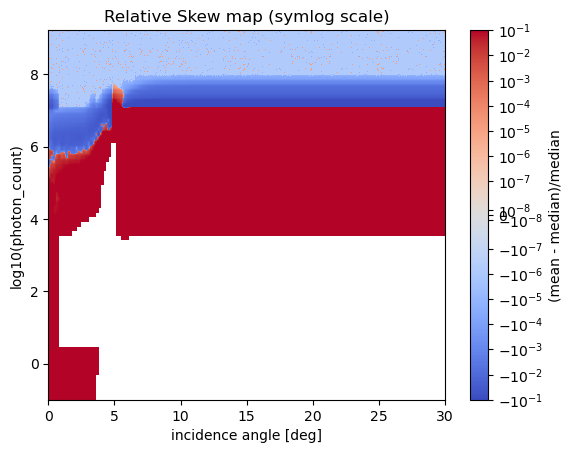

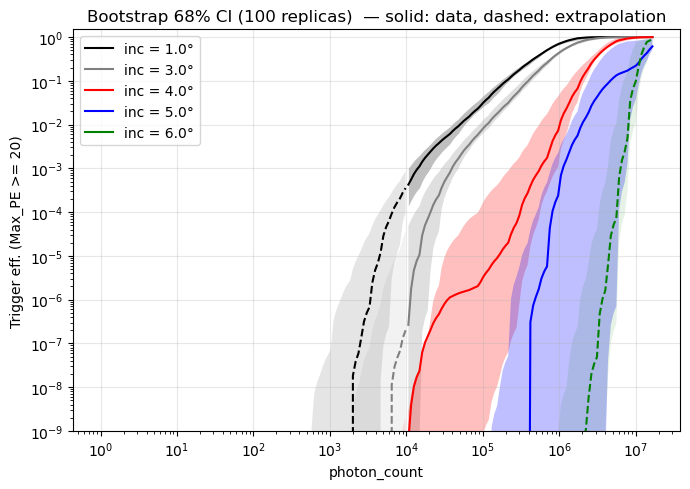

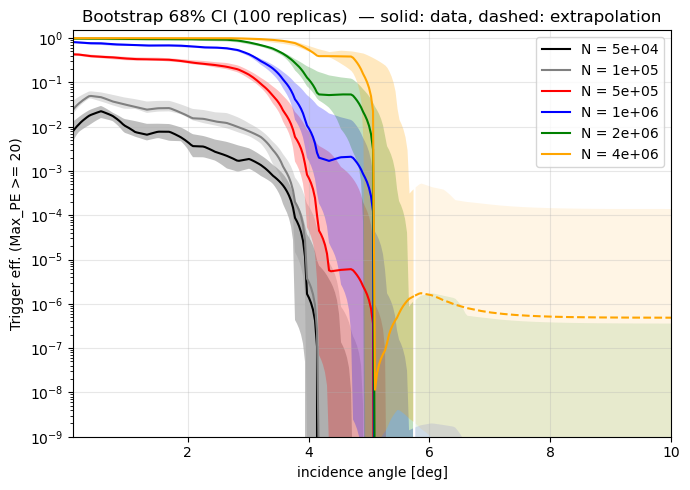

In [134]:
# Check Skewness
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
import numpy as np

skew = (BOOT_MEAN - BOOT_MED) / BOOT_MED

linthresh = np.min(skew[np.where(skew > 0)])
vmax = np.nanmax(np.abs(skew))

norm = SymLogNorm(linthresh=linthresh, linscale=1.0,
                  vmin=-vmax, vmax=vmax, base=10)

extent = [COMMON_INC[0], COMMON_INC[-1],
          COMMON_LOG_PC[0], COMMON_LOG_PC[-1]]

plt.imshow(skew, norm=norm, cmap="coolwarm", origin="lower",
           extent=extent, aspect="auto")
plt.ylabel("log10(photon_count)")
plt.xlabel("incidence angle [deg]")
plt.colorbar(label="(mean - median)/median")
plt.title("Relative Skew map (symlog scale)")
plt.show()

# ---------- Example: efficiency vs photon_count at a few incidences ----------
fig, ax = plt.subplots(figsize=(7, 5))
N_grid = np.logspace(np.log10(pc_.min()),
                     np.log10(pc_.max()) , 200)
log_N_grid = np.log10(N_grid)

for inc_val, color in zip([1, 3, 4, 5, 6], ['black', 'gray', 'red', 'blue', 'green']):
    eff_c, lo, hi = trigger_eff_ci(N_grid, inc_val)

    # Mask: True where we are inside the empirical data coverage box
    inside = (
        (log_N_grid >= np.log10(min(pc_[hit_>0]))) & (log_N_grid <= _DATA_LOG_PC_HI) &
        (inc_val   >= _DATA_INC_LO)    & (inc_val   <= _DATA_INC_HI)
    )

    # Solid segment (inside)
    eff_in = np.where(inside, eff_c, np.nan)
    ax.plot(N_grid, eff_in, color=color, linestyle='-',
            label=f"inc = {inc_val:.1f}°")

    # Dashed segment (extrapolation)
    eff_out = np.where(~inside, eff_c, np.nan)
    ax.plot(N_grid, eff_out, color=color, linestyle='--')

    # CI band everywhere (lighter alpha outside)
    ax.fill_between(N_grid, lo, hi, where=inside,
                    color=color, alpha=0.25, linewidth=0)
    ax.fill_between(N_grid, lo, hi, where=~inside,
                    color=color, alpha=0.10, linewidth=0)

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_ylim(1e-9, 1.5)
ax.set_xlabel("photon_count")
ax.set_ylabel(f"Trigger eff. (Max_PE >= {PE_THRESHOLD})")
ax.set_title(f"Bootstrap {CI_LEVEL}% CI ({N_BOOT} replicas)  "
             f"— solid: data, dashed: extrapolation")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()
# ---------- Example: efficiency vs incidence angle at a few photon counts ----------
fig, ax = plt.subplots(figsize=(7, 5))
inc_grid = np.linspace(inc_.min(), 10.0, 300)

N_values = [5e4, 1e5, 5e5, 1e6, 2e6, 4e6]
colors   = ['black', 'gray', 'red', 'blue', 'green', 'orange']

log_pc_lo = np.log10(min(pc_[hit_ > 0]))

for N_val, color in zip(N_values, colors):
    eff_c, lo, hi = trigger_eff_ci(N_val, inc_grid)

    # Mask: True where we are inside the empirical data coverage box
    inside = (
        (np.log10(N_val) >= log_pc_lo) & (np.log10(N_val) <= _DATA_LOG_PC_HI) &
        (inc_grid        >= _DATA_INC_LO) & (inc_grid     <= _DATA_INC_HI)
    )

    # Solid segment (inside)
    eff_in = np.where(inside, eff_c, np.nan)
    ax.plot(inc_grid, eff_in, color=color, linestyle='-',
            label=f"N = {N_val:.0e}")

    # Dashed segment (extrapolation, including inc > data range up to 10°)
    eff_out = np.where(~inside, eff_c, np.nan)
    ax.plot(inc_grid, eff_out, color=color, linestyle='--')

    # CI band
    ax.fill_between(inc_grid, lo, hi, where=inside,
                    color=color, alpha=0.25, linewidth=0)
    ax.fill_between(inc_grid, lo, hi, where=~inside,
                    color=color, alpha=0.10, linewidth=0)

ax.set_yscale('log')
ax.set_ylim(1e-9, 1.5)
ax.set_xlim(inc_.min(), 10.0)
ax.set_xlabel("incidence angle [deg]")
ax.set_ylabel(f"Trigger eff. (Max_PE >= {PE_THRESHOLD})")
ax.set_title(f"Bootstrap {CI_LEVEL}% CI ({N_BOOT} replicas)  "
             f"— solid: data, dashed: extrapolation")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()


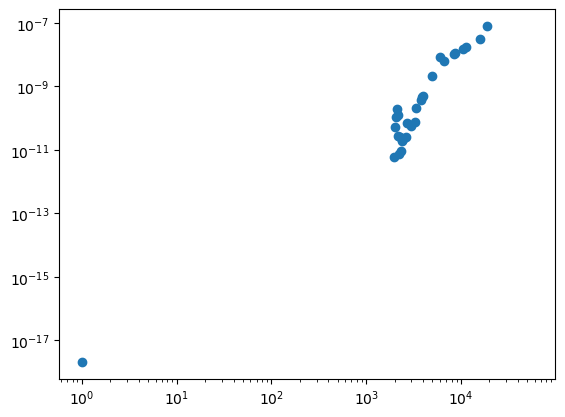

5.4625640465557054e-05 1.9181740065363126e-05 0.00010657633788989673
0.00015211648 9.759667e-05 0.00025556175


In [135]:
mask = (Energy_GeV<1e3)&(Energy_GeV>8e2)&(Slant>100)&(Slant<110)&(photon_count>0)&(Zenith>89)
log_pc = np.log10(photon_count[mask])
edges_log = np.histogram_bin_edges(log_pc, bins='fd')
edges = 10**edges_log  # all positive, geometric centres valid
count, _ = np.histogram(photon_count[mask], bins =edges, density=True)
pc = edges
pdf, pdf_lo, pdf_hi = trigger_eff_ci(pc, 1)
plt.plot(pc[:-1], count*pdf[:-1], "o")
#plt.plot(pc[:-1], count*pdf_lo[:-1])
#plt.plot(pc[:-1], count*pdf_hi[:-1])
plt.loglog()
plt.show()
print(np.sum(count*pdf[:-1]*np.diff(pc)), np.sum(count*pdf_lo[:-1]*np.diff(pc)), np.sum(count*pdf_hi[:-1]*np.diff(pc)))

pdf, pdf_lo, pdf_hi = trigger_eff_ci(photon_count[mask], 1)
print(np.mean(pdf), np.mean(pdf_lo), np.mean(pdf_hi))

In [136]:
# Empirical efficiency cube on (zenith, H, E) — OPTIMIZED version
# =============================================================================
# Key optimizations vs original:
#   1. ffill_along_H        — fully vectorized, no Python loops
#   2. efficiency_grid_H_E  — bin-membership computed once per (E,H) pair via
#                             np.digitize; tasks chunked by zenith so joblib
#                             overhead is ~N_Z_BINS jobs instead of N_tasks
#   3. _process_zen_slice   — phi/trig computed once per zenith, reused across
#                             all (H, E) bins in that slice; single batched
#                             trigger_eff_ci call per (H, E) bin
#   4. extrapolate_via_slant — same chunking strategy (one job per zen slice)
#   5. build_E_slant_pc_table — inner loop replaced with np.digitize + groupby
# =============================================================================

import os
import numpy as np
from joblib import Parallel, delayed
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import distance_transform_edt

# ---------- Config ----------
BOOT_SEED   = 123
N_BOOT_EFF  = N_BOOTSTRAP
MIN_PTS_EFF = 5
N_E_BINS    = 40 #40
N_H_BINS    = 20 #20
N_Z_BINS    = 15 #30
N_AZ_BINS   = 10
N_JOBS      = os.cpu_count()

ENERGY_MIN = 1e1
ENERGY_MAX = 1e6
ZEN_MIN    = 85
ZEN_MAX    = np.nanmax(Zenith)
AZIMUTH_RANGE = 10.0
H_MIN = np.nanmin(H) #5_000
H_MAX = np.nanmax(H) #50_000

OBS_HEIGHT_M   = 2_944.0
EARTH_RADIUS_M = 6_371_000.0

N_PARAMS   = 1
PARAM_ORDER = ["dummy"]
COV_FULL   = np.zeros((N_PARAMS, N_PARAMS))

# =============================================================================
# Helpers
# =============================================================================

def _phi_inc_grid(zen_deg, psi_deg, phi_max_deg, n_phi):
    """
    Precompute (phi, theta_inc) for a single zenith angle.
    Returns phi (n_phi,) and theta_inc (n_phi,) in degrees.
    Factored out so each zenith slice computes it exactly once.
    """
    theta_z  = np.radians(zen_deg)
    psi      = np.radians(psi_deg)
    phi      = np.linspace(0.0, np.radians(phi_max_deg), n_phi)
    cos_t    = (np.cos(psi) * np.cos(theta_z)
                + np.sin(psi) * np.sin(theta_z) * np.cos(phi))
    cos_t    = np.clip(cos_t, -1.0, 1.0)
    theta_inc = np.degrees(np.arccos(cos_t))   # (n_phi,)
    return phi, theta_inc


"""def _phi_avg_eff(pc_sel, theta_inc, phi, reducer="mean", n_pc_bins = "fd"):
    #Average trigger efficiency over phi for an array of photon counts.
    #Parameters
    #----------
    #pc_sel    : (Nsh,)   photon counts for showers in this bin
    #theta_inc : (n_phi,) incidence angles in degrees
    #phi       : (n_phi,) phi values in radians
    #reducer   : str      "mean" | "median" | "68_percentile" | "histogram"
    #n_pc_bins : int      number of log-spaced bins for histogram method. "fd": Freedman-Diaconis

    #Returns
    #-------
    #eff, eff_lo, eff_hi : scalars
    npts  = len(pc_sel)
    n_phi = len(phi)
    denom = phi[-1] - phi[0]

    def mean_fall_back():
        pc_b  = pc_sel[:, None]
        inc_b = np.broadcast_to(theta_inc, (npts, n_phi))
        med, lo, hi = trigger_eff_ci(pc_b, inc_b)                            # (Nsh, n_phi)
        med_phi = np.trapezoid(med, phi, axis=-1) / denom                    # (Nsh,)
        lo_phi  = np.trapezoid(lo,  phi, axis=-1) / denom
        hi_phi  = np.trapezoid(hi,  phi, axis=-1) / denom
        return float(np.mean(med_phi)), float(np.mean(lo_phi)), float(np.mean(hi_phi))
    if reducer == "histogram":
        pc_pos = pc_sel[pc_sel > 0]
        if len(pc_pos) < 2 or pc_pos.min() == pc_pos.max():
            return mean_fall_back()
        # use density=False, normalise manually to avoid /0
        
        # FD on log scale for adaptive log-spaced bins
        if n_pc_bins == "fd":
            log_pc = np.log10(pc_pos)
            edges_log = np.histogram_bin_edges(log_pc, bins='fd')
            edges = 10**edges_log  # all positive, geometric centres valid
            count, _ = np.histogram(pc_pos, bins=edges)
            n_pc_bins = len(count)
        else:
            pc_bins = np.logspace(np.log10(pc_pos.min()),np.log10(pc_pos.max()),n_pc_bins + 1)
            count, edges = np.histogram(pc_sel, bins="auto")          # raw counts
        #print(len(pc_sel), len(edges), min(edges), max(edges), max(count), min(count))
        dp     = np.diff(edges)                                     # bin width
        total  = count.sum()
        pdf = count / (total * dp) # (n_pc_bins, )
        pc_cen = np.sqrt(edges[:-1] * edges[1:])
        pc_b  = pc_cen[:, None]                                          # (n_pc_bins, 1)

        inc_b = np.broadcast_to(theta_inc, (n_pc_bins, n_phi))           # (n_pc_bins, n_phi)
        med, lo, hi = trigger_eff_ci(pc_b, inc_b)                        # (n_pc_bins, n_phi)

        med_phi = np.trapezoid(med, phi, axis=-1) / denom                    # (n_pc_bins,)
        lo_phi  = np.trapezoid(lo,  phi, axis=-1) / denom
        hi_phi  = np.trapezoid(hi,  phi, axis=-1) / denom

        weights = pdf * dp                                              # sums to ~1
        eff    = float(np.sum(weights * med_phi))
        eff_lo = float(np.sum(weights * lo_phi))
        eff_hi = float(np.sum(weights * hi_phi))

        return eff, eff_lo, eff_hi

    elif reducer == "mean":
        return mean_fall_back()
    else:
        raise ValueError(f"Unknown reducer: {reducer!r}")"""

def _phi_avg_eff(pc_sel, theta_inc, phi, reducer="mean",
                 n_pc_bins="fd", n_boot=100, rng=None):
    """
    Average trigger efficiency over phi for an array of photon counts,
    propagating BOTH model-side CI (from trigger_eff_ci) AND
    statistical sampling CI (from bootstrap over showers).

    Parameters
    ----------
    pc_sel    : (Nsh,) photon counts for showers in this bin
    theta_inc : (n_phi,) incidence angles in degrees
    phi       : (n_phi,) phi values in radians
    reducer   : "mean" | "histogram"
    n_pc_bins : int or "fd"  (only used for histogram reducer)
    n_boot    : int          number of bootstrap resamples
    rng       : np.random.Generator or None

    Returns
    -------
    eff, eff_lo, eff_hi : scalars  (nominal, 16th, 84th percentile of total CI)
    """
    npts  = len(pc_sel)
    n_phi = len(phi)
    denom = phi[-1] - phi[0]
    if rng is None:
        rng = np.random.default_rng()

    # -----------------------------------------------------------
    # Compute per-shower phi-averaged efficiency (med, lo, hi)
    # Shape: (Nsh,)
    # -----------------------------------------------------------
    pc_b  = pc_sel[:, None]                              # (Nsh, 1)
    inc_b = np.broadcast_to(theta_inc, (npts, n_phi))    # (Nsh, n_phi)
    med, lo, hi = trigger_eff_ci(pc_b, inc_b)            # each (Nsh, n_phi)
    med_phi = np.trapezoid(med, phi, axis=-1) / denom    # (Nsh,)
    lo_phi  = np.trapezoid(lo,  phi, axis=-1) / denom    # (Nsh,)
    hi_phi  = np.trapezoid(hi,  phi, axis=-1) / denom    # (Nsh,)

    if reducer == "mean":
        return _combine_uncertainty(med_phi, lo_phi, hi_phi, n_boot, rng)

    elif reducer == "histogram":
        # Build pc histogram, evaluate efficiency at bin centers, weight by PDF
        pc_pos = pc_sel[pc_sel > 0]
        if len(pc_pos) < 2 or pc_pos.min() == pc_pos.max():
            # Fall back to the per-shower mean path
            return _combine_uncertainty(med_phi, lo_phi, hi_phi, n_boot, rng)

        if n_pc_bins == "fd":
            log_pc = np.log10(pc_pos)
            edges_log = np.histogram_bin_edges(log_pc, bins='fd')
            edges = 10**edges_log
            count, _ = np.histogram(pc_pos, bins=edges)
            nb = len(count)
        else:
            edges = np.logspace(np.log10(pc_pos.min()),
                                np.log10(pc_pos.max()), n_pc_bins + 1)
            count, _ = np.histogram(pc_sel, bins=edges)
            nb = n_pc_bins

        dp     = np.diff(edges)
        total  = count.sum()
        if total == 0:
            return _combine_uncertainty(med_phi, lo_phi, hi_phi, n_boot, rng)
        pdf    = count / (total * dp)
        pc_cen = np.sqrt(edges[:-1] * edges[1:])

        pc_b  = pc_cen[:, None]
        inc_b = np.broadcast_to(theta_inc, (nb, n_phi))
        med_h, lo_h, hi_h = trigger_eff_ci(pc_b, inc_b)
        med_h_phi = np.trapezoid(med_h, phi, axis=-1) / denom    # (nb,)
        lo_h_phi  = np.trapezoid(lo_h,  phi, axis=-1) / denom
        hi_h_phi  = np.trapezoid(hi_h,  phi, axis=-1) / denom

        weights = pdf * dp                                       # (nb,)
        eff_nom = float(np.sum(weights * med_h_phi))

        # ---- model-side CI: weighted average of lo/hi over pc bins ----
        eff_model_lo = float(np.sum(weights * lo_h_phi))
        eff_model_hi = float(np.sum(weights * hi_h_phi))

        # ---- sampling CI: bootstrap the bin counts (Poisson / multinomial) ----
        if n_boot > 0 and total > 0:
            # Multinomial resample of the histogram counts
            boot_counts = rng.multinomial(int(total), count / total,
                                          size=n_boot)            # (n_boot, nb)
            boot_pdf    = boot_counts / (total * dp[None, :])     # (n_boot, nb)
            boot_w      = boot_pdf * dp[None, :]                  # (n_boot, nb)
            boot_eff    = boot_w @ med_h_phi                      # (n_boot,)
            stat_lo, stat_hi = np.percentile(boot_eff, [16, 84])
        else:
            stat_lo = stat_hi = eff_nom

        # Combine in quadrature
        sig_stat_lo = max(eff_nom - stat_lo, 0.0)
        sig_stat_hi = max(stat_hi - eff_nom, 0.0)
        sig_mod_lo  = max(eff_nom - eff_model_lo, 0.0)
        sig_mod_hi  = max(eff_model_hi - eff_nom, 0.0)
        eff_lo = eff_nom - np.hypot(sig_stat_lo, sig_mod_lo)
        eff_hi = eff_nom + np.hypot(sig_stat_hi, sig_mod_hi)
        return eff_nom, max(eff_lo, 0.0), min(eff_hi, 1.0)

    else:
        raise ValueError(f"Unknown reducer: {reducer!r}")


def _combine_uncertainty(med_phi, lo_phi, hi_phi, n_boot, rng):
    """
    Helper: combine model-side CI (lo/hi per shower) with bootstrap
    sampling CI over showers, returning (nominal, lo, hi).
    """
    npts = len(med_phi)
    eff_nom = float(np.mean(med_phi))

    # Model-side averaged CI
    eff_model_lo = float(np.mean(lo_phi))
    eff_model_hi = float(np.mean(hi_phi))

    # Bootstrap sampling CI
    if npts >= 2 and n_boot > 0:
        idx = rng.integers(0, npts, size=(n_boot, npts))
        boot_means = med_phi[idx].mean(axis=1)
        stat_lo, stat_hi = np.percentile(boot_means, [16, 84])
    else:
        stat_lo = stat_hi = eff_nom

    sig_stat_lo = max(eff_nom - stat_lo, 0.0)
    sig_stat_hi = max(stat_hi - eff_nom, 0.0)
    sig_mod_lo  = max(eff_nom - eff_model_lo, 0.0)
    sig_mod_hi  = max(eff_model_hi - eff_nom, 0.0)

    eff_lo = eff_nom - np.hypot(sig_stat_lo, sig_mod_lo)
    eff_hi = eff_nom + np.hypot(sig_stat_hi, sig_mod_hi)
    return eff_nom, max(eff_lo, 0.0), min(eff_hi, 1.0)

# =============================================================================
# 1. Forward-fill along H — fully vectorized
# =============================================================================

def ffill_along_H(EFF, *extras):
    """
    Forward-fill NaNs along the H axis (axis=1) for arrays of shape
    (n_zen, n_H, n_E[, ...]).  Fully vectorized — no Python loops.
    """
    n_zen, n_H, n_E = EFF.shape[:3]
    trailing = EFF.shape[3:]

    def _ffill_3d(arr):
        # Work on a copy; arr shape (n_zen, n_H, n_E)
        out = arr.copy()
        finite = np.isfinite(out)                      # (nz, nH, nE)
        # Build a "last finite H index" via cumulative max over the H axis
        h_idx  = np.where(finite, np.arange(n_H)[None, :, None], 0)
        np.maximum.accumulate(h_idx, axis=1, out=h_idx)
        # Gather
        z_idx = np.arange(n_zen)[:, None, None]
        e_idx = np.arange(n_E)[None, None, :]
        out   = out[z_idx, h_idx, e_idx]
        # Re-NaN positions that were NaN before any finite value appeared
        first_finite = np.argmax(finite, axis=1)       # (nz, nE)
        # argmax returns 0 when all False; mask those
        all_nan = ~finite.any(axis=1)                  # (nz, nE)
        h_range = np.arange(n_H)[None, :, None]        # (1, nH, 1)
        before  = h_range < first_finite[:, None, :]   # (nz, nH, nE)
        out[before | all_nan[:, None, :]] = np.nan
        return out

    def _ffill_4d(arr):
        # arr shape (n_zen, n_H, n_E, N_PARAMS)
        n_p = arr.shape[3]
        out = np.stack([_ffill_3d(arr[..., p]) for p in range(n_p)], axis=-1)
        return out

    out_eff = _ffill_3d(EFF)
    out_extras = []
    for arr in extras:
        if arr.ndim == 3:
            out_extras.append(_ffill_3d(arr))
        elif arr.ndim == 4:
            out_extras.append(_ffill_4d(arr))
        else:
            raise ValueError(f"ffill_along_H: unsupported ndim={arr.ndim}")

    if out_extras:
        return (out_eff, *out_extras)
    return out_eff


# =============================================================================
# 2. Per-zenith-slice worker  (used by efficiency_grid_H_E)
# =============================================================================

"""def _process_zen_slice_HE(k, zen_deg, bin_tasks, psi_deg, phi_max_deg, n_phi, reducer):
    #Process all (j, i, pc_sel) tasks for a single zenith angle.
    #Parameters
    #----------
    #k         : zenith index
    #zen_deg   : zenith angle in degrees
    #bin_tasks : list of (j, i, pc_sel)
    #psi_deg   : psi (deg)
    #phi_max_deg, n_phi : phi grid params

    #Returns
    #-------
    #list of (k, j, i, med, lo, hi)
    if not bin_tasks:
        return []

    phi, theta_inc = _phi_inc_grid(zen_deg, psi_deg, phi_max_deg, n_phi)

    out = []
    for j, i, pc_sel in bin_tasks:
        if len(pc_sel) == 0:
            out.append((k, j, i, np.nan, np.nan, np.nan))
            continue
        m, lo, hi = _phi_avg_eff(pc_sel, theta_inc, phi, reducer = reducer)
        out.append((k, j, i, m, lo, hi))
    return out"""
def _process_zen_slice_HE(k, zen_deg, bin_tasks, psi_deg, phi_max_deg, n_phi,
                          reducer, n_boot, rng_seed):
    if not bin_tasks:
        return []
    # Each worker gets its own RNG, seeded deterministically from the global seed + k
    rng = np.random.default_rng(rng_seed + k) if rng_seed is not None else np.random.default_rng()
    phi, theta_inc = _phi_inc_grid(zen_deg, psi_deg, phi_max_deg, n_phi)

    out = []
    for j, i, pc_sel in bin_tasks:
        if len(pc_sel) == 0:
            out.append((k, j, i, np.nan, np.nan, np.nan))
            continue
        m, lo, hi = _phi_avg_eff(pc_sel, theta_inc, phi,
                                 reducer=reducer, n_boot=n_boot, rng=rng)
        out.append((k, j, i, m, lo, hi))
    return out


# =============================================================================
# 3. Empirical efficiency cube  (parallel over zenith slices)
# =============================================================================

def efficiency_grid_H_E(
    E_edges, H_edges, Zen_grid,
    Energy_GeV, H, photon_count,
    psi_deg=90.0, phi_max_deg=3.0, n_phi=50,
    min_pts=5, reducer='mean',
    n_boot=200, rng=None, n_jobs=1,
):
    n_zen = len(Zen_grid)
    n_H   = len(H_edges) - 1
    n_E   = len(E_edges) - 1
    E_cen = np.sqrt(E_edges[:-1] * E_edges[1:])
    H_cen = 0.5 * (H_edges[:-1] + H_edges[1:])

    EFF    = np.full((n_zen, n_H, n_E), np.nan)
    EFF_LO = np.full((n_zen, n_H, n_E), np.nan)
    EFF_HI = np.full((n_zen, n_H, n_E), np.nan)
    COUNTS = np.zeros((n_zen, n_H, n_E), dtype=int)
    GRAD   = np.zeros((n_zen, n_H, n_E, N_PARAMS))
    pc_in_bin = [[[None] * n_E for _ in range(n_H)] for _ in range(n_zen)]

    # ------------------------------------------------------------------
    # Bin membership computed once with np.digitize (vectorized)
    # ------------------------------------------------------------------
    E_idx = np.digitize(Energy_GeV, E_edges) - 1   # 0-based; -1 or n_E = outside
    H_idx = np.digitize(H,          H_edges) - 1

    valid = (E_idx >= 0) & (E_idx < n_E) & (H_idx >= 0) & (H_idx < n_H)
    E_idx_v = E_idx[valid]
    H_idx_v = H_idx[valid]
    pc_v    = photon_count[valid]

    # Count hits per (H, E) bin  — same for every zenith
    flat_idx = H_idx_v * n_E + E_idx_v                # (N_valid,)
    counts_HE = np.bincount(flat_idx, minlength=n_H * n_E).reshape(n_H, n_E)

    # Build per-(j, i) pc arrays once
    _order  = np.argsort(flat_idx)
    _fi_s   = flat_idx[_order]
    _pc_s   = pc_v[_order]
    _splits = np.searchsorted(_fi_s, np.arange(n_H * n_E + 1))
    pc_HE   = {}                                       # {(j,i): pc_array}
    for flat in range(n_H * n_E):
        j, i = divmod(flat, n_E)
        sl   = slice(_splits[flat], _splits[flat + 1])
        cnt  = _splits[flat + 1] - _splits[flat]
        COUNTS[:, j, i] = cnt                          # same for every zenith
        if cnt >= min_pts:
            pc_HE[(j, i)] = _pc_s[sl]
            for k in range(n_zen):
                pc_in_bin[k][j][i] = _pc_s[sl]

    if not pc_HE:
        return (EFF, EFF_LO, EFF_HI, COUNTS, E_cen, H_cen, pc_in_bin, GRAD)

    # ------------------------------------------------------------------
    # Build per-zenith task lists and dispatch one job per zenith slice
    # ------------------------------------------------------------------
    zen_tasks = []
    for k, zen_deg in enumerate(Zen_grid):
        bin_tasks = [(j, i, arr) for (j, i), arr in pc_HE.items()]
        zen_tasks.append((k, zen_deg, bin_tasks))

    n_total_bins = len(Zen_grid) * len(pc_HE)
    print(f"efficiency_grid_H_E: {n_total_bins} bins "
          f"({len(Zen_grid)} zen × {len(pc_HE)} HE), {n_jobs} CPUs")

    #slice_results = Parallel(n_jobs=n_jobs, verbose=5)(
    #    delayed(_process_zen_slice_HE)(k, zen_deg, bin_tasks,
    #                                   psi_deg, phi_max_deg, n_phi, reducer)
    #    for k, zen_deg, bin_tasks in zen_tasks
    #)
    # Extract a deterministic seed from rng
    rng_seed = int(rng.integers(0, 2**31 - 1)) if rng is not None else None

    slice_results = Parallel(n_jobs=n_jobs, verbose=5)(
        delayed(_process_zen_slice_HE)(k, zen_deg, bin_tasks,
                                   psi_deg, phi_max_deg, n_phi, reducer,
                                   n_boot, rng_seed)
    for k, zen_deg, bin_tasks in zen_tasks
    )

    for slice_out in slice_results:
        for k, j, i, eff_v, lo_v, hi_v in slice_out:
            EFF[k, j, i]    = eff_v
            EFF_LO[k, j, i] = lo_v
            EFF_HI[k, j, i] = hi_v

    return (EFF, EFF_LO, EFF_HI, COUNTS, E_cen, H_cen, pc_in_bin, GRAD)


# =============================================================================
# 4. Build (E, Slant) photon-count lookup — vectorized inner loop
# =============================================================================

def build_E_slant_pc_table(E_edges, H_emit, Energy_GeV, photon_count,
                           Zenith_deg, n_slant_bins):
    E_edges      = np.asarray(E_edges,      dtype=float)
    H_emit       = np.asarray(H_emit,       dtype=float)
    Energy_GeV   = np.asarray(Energy_GeV,   dtype=float)
    photon_count = np.asarray(photon_count, dtype=float)
    Zenith_rad   = np.radians(np.asarray(Zenith_deg, dtype=float))

    Slant_km = slant_depth(
        H_emit + EARTH_RADIUS_M,
        OBS_HEIGHT_M + EARTH_RADIUS_M,
        Zenith_rad,
    ) / 1000.0

    S_edges = np.linspace(np.nanmin(Slant_km), np.nanmax(Slant_km), n_slant_bins + 1)
    S_cen   = 0.5 * (S_edges[:-1] + S_edges[1:])
    n_E     = len(E_edges) - 1

    # Bin membership — vectorized
    finite_mask = np.isfinite(photon_count) & (photon_count > 0)
    E_idx = np.digitize(Energy_GeV, E_edges) - 1       # 0-based
    S_idx = np.digitize(Slant_km,   S_edges) - 1

    valid = (finite_mask
             & (E_idx >= 0) & (E_idx < n_E)
             & (S_idx >= 0) & (S_idx < n_slant_bins))
    E_idx_v  = E_idx[valid]
    S_idx_v  = S_idx[valid]
    pc_v     = photon_count[valid]

    flat_idx = E_idx_v * n_slant_bins + S_idx_v
    order    = np.argsort(flat_idx)
    fi_s     = flat_idx[order]
    pc_s     = pc_v[order]
    splits   = np.searchsorted(fi_s, np.arange(n_E * n_slant_bins + 1))

    pc_ES = [[None] * n_slant_bins for _ in range(n_E)]
    for flat in range(n_E * n_slant_bins):
        i, s = divmod(flat, n_slant_bins)
        sl = slice(splits[flat], splits[flat + 1])
        arr = pc_s[sl]
        pc_ES[i][s] = arr if len(arr) > 0 else np.empty(0)

    return S_edges, S_cen, pc_ES


# =============================================================================
# 5. Slant-based extrapolation — parallel over zenith slices
# =============================================================================

"""def _process_zen_slice_slant(k, zen, j_tasks, psi_deg, phi_max_deg, n_phi, reducer):
    #j_tasks : list of (j, i, pc)
    #Returns : list of (k, j, i, eff, lo, hi)
    if not j_tasks:
        return []

    #reducer  = np.mean if reduce == 'mean' else np.median
    phi, theta_inc = _phi_inc_grid(zen, psi_deg, phi_max_deg, n_phi)

    out = []
    for j, i, pc in j_tasks:
        if len(pc) == 0:
            out.append((k, j, i, np.nan, np.nan, np.nan))
            continue
        m, lo, hi = _phi_avg_eff(pc, theta_inc, phi, reducer = reducer)
        #out.append((k, j, i, float(reducer([m])),
        #                       float(reducer([lo])),
        #                       float(reducer([hi]))))
        out.append((k, j, i, m, lo, hi))
    return out"""
def _process_zen_slice_slant(k, zen, j_tasks, psi_deg, phi_max_deg, n_phi,
                              reducer, n_boot, rng_seed):
    if not j_tasks:
        return []
    rng = np.random.default_rng(rng_seed + 1000 + k) if rng_seed is not None else np.random.default_rng()
    phi, theta_inc = _phi_inc_grid(zen, psi_deg, phi_max_deg, n_phi)

    out = []
    for j, i, pc in j_tasks:
        if len(pc) == 0:
            out.append((k, j, i, np.nan, np.nan, np.nan))
            continue
        m, lo, hi = _phi_avg_eff(pc, theta_inc, phi,
                                 reducer=reducer, n_boot=n_boot, rng=rng)
        out.append((k, j, i, m, lo, hi))
    return out


def extrapolate_via_slant(EFF, EFF_LO, EFF_HI,
                          E_cen, H_cen, zenith_deg, S_edges, pc_ES,
                          psi_deg=90.0, phi_max_deg=5.0, n_phi=20,
                          min_pts=5, reducer='mean', n_boot=200,
                          rng=None, n_jobs=N_JOBS):
    n_zen, n_H, n_E = EFF.shape

    # Build per-zenith task lists
    zen_tasks = []
    for k in range(n_zen):
        zen = zenith_deg[k]
        j_tasks = []
        for j in range(n_H):
            slant_km = slant_depth(
                H_cen[j] + EARTH_RADIUS_M,
                OBS_HEIGHT_M + EARTH_RADIUS_M,
                np.deg2rad(zen),
            ) / 1000.0
            si = int(np.clip(np.searchsorted(S_edges, slant_km) - 1,
                             0, len(S_edges) - 2))
            for i in range(n_E):
                if np.isfinite(EFF[k, j, i]):
                    continue
                pc = pc_ES[i][si]
                if pc is None or len(pc) < min_pts:
                    continue
                j_tasks.append((j, i, pc))
        if j_tasks:
            zen_tasks.append((k, zen, j_tasks))

    if not zen_tasks:
        return EFF, EFF_LO, EFF_HI

    n_total = sum(len(t[2]) for t in zen_tasks)
    print(f"extrapolate_via_slant: {n_total} bins "
          f"across {len(zen_tasks)} zenith slices, {n_jobs} CPUs")

    #slice_results = Parallel(n_jobs=n_jobs, verbose=5)(
    #    delayed(_process_zen_slice_slant)(k, zen, j_tasks,
    #                                      psi_deg, phi_max_deg, n_phi, reducer)
    #    for k, zen, j_tasks in zen_tasks
    #)
    rng_seed = int(rng.integers(0, 2**31 - 1)) if rng is not None else None

    slice_results = Parallel(n_jobs=n_jobs, verbose=5)(
    delayed(_process_zen_slice_slant)(k, zen, j_tasks,
                                      psi_deg, phi_max_deg, n_phi, reducer,
                                      n_boot, rng_seed)
    for k, zen, j_tasks in zen_tasks
    )

    for slice_out in slice_results:
        for k, j, i, eff_val, lo_val, hi_val in slice_out:
            if np.isfinite(eff_val):
                EFF[k, j, i]    = eff_val
                EFF_LO[k, j, i] = lo_val
                EFF_HI[k, j, i] = hi_val

    return EFF, EFF_LO, EFF_HI


# =============================================================================
# 6. Build efficiency interpolator (logic unchanged, calls optimized helpers)
# =============================================================================

def build_efficiency_interpolator(EFF, EFF_LO, EFF_HI,
                                  E_cen, H_cen, zenith_deg, S_edges, pc_ES,
                                  psi_deg=90.0, phi_max_deg=5.0, n_phi=20,
                                  min_pts=3, reducer='mean', n_boot=200,
                                  rng=None,
                                  H_extrap_range=(0.0, 120_000.0),
                                  n_H_extra=4,
                                  zen_extrap_range=None,
                                  n_zen_extra=2,
                                  n_jobs=N_JOBS):
    H_cen      = np.asarray(H_cen,      dtype=float)
    zenith_deg = np.asarray(zenith_deg, dtype=float)

    if n_H_extra > 0:
        H_lo      = np.linspace(H_extrap_range[0], H_cen[0],   n_H_extra + 1)[:-1]
        H_hi      = np.linspace(H_cen[-1], H_extrap_range[1],  n_H_extra + 1)[1:]
        H_cen_ext = np.concatenate([H_lo, H_cen, H_hi])
    else:
        H_cen_ext = H_cen.copy()

    if zen_extrap_range is not None and n_zen_extra > 0:
        Z_lo    = np.linspace(zen_extrap_range[0], zenith_deg[0],  n_zen_extra + 1)[:-1]
        Z_hi    = np.linspace(zenith_deg[-1], zen_extrap_range[1], n_zen_extra + 1)[1:]
        zen_ext = np.concatenate([Z_lo, zenith_deg, Z_hi])
    else:
        zen_ext = zenith_deg.copy()

    z_off     = int(np.searchsorted(zen_ext, zenith_deg[0]))
    h_off     = int(np.searchsorted(H_cen_ext, H_cen[0]))
    n_zen_ext = len(zen_ext)
    n_H_ext   = len(H_cen_ext)
    n_E       = EFF.shape[2]

    def _embed(arr_old):
        out = np.full((n_zen_ext, n_H_ext, n_E), np.nan)
        out[z_off:z_off + len(zenith_deg),
            h_off:h_off + len(H_cen), :] = arr_old
        return out

    EFF    = _embed(EFF)
    EFF_LO = _embed(EFF_LO)
    EFF_HI = _embed(EFF_HI)

    H_cen      = H_cen_ext
    zenith_deg = zen_ext

    EFF_filled    = EFF.copy()
    EFF_LO_filled = EFF_LO.copy()
    EFF_HI_filled = EFF_HI.copy()
    fill_mask     = ~np.isfinite(EFF)

    nan_mask = ~np.isfinite(EFF_filled)
    if np.any(nan_mask):
        _, idx = distance_transform_edt(nan_mask, return_indices=True)
        EFF_filled[nan_mask]    = EFF_filled[tuple(idx)][nan_mask]
        EFF_LO_filled[nan_mask] = EFF_LO_filled[tuple(idx)][nan_mask]
        EFF_HI_filled[nan_mask] = EFF_HI_filled[tuple(idx)][nan_mask]

    original_nan = ~np.isfinite(EFF)
    edge_mask = np.zeros_like(EFF_filled, dtype=bool)
    edge_mask[:, :2, :]  = True
    edge_mask[:2, :, :]  = True
    edge_mask[-2:, :, :] = True
    reopen = edge_mask & original_nan
    EFF_filled[reopen]    = np.nan
    EFF_LO_filled[reopen] = np.nan
    EFF_HI_filled[reopen] = np.nan

    EFF_filled, EFF_LO_filled, EFF_HI_filled = extrapolate_via_slant(
        EFF_filled, EFF_LO_filled, EFF_HI_filled,
        E_cen, H_cen, zenith_deg, S_edges, pc_ES,
        psi_deg=psi_deg, phi_max_deg=phi_max_deg, n_phi=n_phi,
        min_pts=min_pts, reducer=reducer, n_boot=n_boot, rng=rng,
        n_jobs=n_jobs,
    )

    remaining = ~np.isfinite(EFF_filled)
    if np.any(remaining):
        _, idx2 = distance_transform_edt(remaining, return_indices=True)
        EFF_filled[remaining]    = EFF_filled[tuple(idx2)][remaining]
        EFF_LO_filled[remaining] = EFF_LO_filled[tuple(idx2)][remaining]
        EFF_HI_filled[remaining] = EFF_HI_filled[tuple(idx2)][remaining]

    EFF_filled[~np.isfinite(EFF_filled)]       = 0.0
    EFF_LO_filled[~np.isfinite(EFF_LO_filled)] = 0.0
    EFF_HI_filled[~np.isfinite(EFF_HI_filled)] = 0.0

    log10_E = np.log10(E_cen)
    rgi_eff  = RegularGridInterpolator((zenith_deg, H_cen, log10_E),
                                       EFF_filled,    method='linear',
                                       bounds_error=False, fill_value=None)
    rgi_lo   = RegularGridInterpolator((zenith_deg, H_cen, log10_E),
                                       EFF_LO_filled, method='linear',
                                       bounds_error=False, fill_value=None)
    rgi_hi   = RegularGridInterpolator((zenith_deg, H_cen, log10_E),
                                       EFF_HI_filled, method='linear',
                                       bounds_error=False, fill_value=None)
    rgi_mask = RegularGridInterpolator((zenith_deg, H_cen, log10_E),
                                       fill_mask.astype(float), method='nearest',
                                       bounds_error=False, fill_value=1.0)

    def eff_func(E_GeV, H_m, zenith_deg_q):
        E_b, H_b, Z_b = np.broadcast_arrays(
            np.asarray(E_GeV, float),
            np.asarray(H_m,   float),
            np.asarray(zenith_deg_q, float))
        pts = np.column_stack([Z_b.ravel(), H_b.ravel(), np.log10(E_b.ravel())])
        return np.clip(rgi_eff(pts), 0.0, 1.0).reshape(E_b.shape)

    def eff_sigma_func(E_GeV, H_m, zenith_deg_q):
        """Returns (median, lo, hi)."""
        E_b, H_b, Z_b = np.broadcast_arrays(
            np.asarray(E_GeV, float),
            np.asarray(H_m,   float),
            np.asarray(zenith_deg_q, float))
        pts = np.column_stack([Z_b.ravel(), H_b.ravel(), np.log10(E_b.ravel())])
        med = np.clip(rgi_eff(pts), 0.0, 1.0).reshape(E_b.shape)
        lo  = np.clip(rgi_lo(pts),  0.0, 1.0).reshape(E_b.shape)
        hi  = np.clip(rgi_hi(pts),  0.0, 1.0).reshape(E_b.shape)
        return med, lo, hi

    def eff_fill_mask_func(E_GeV, H_m, zenith_deg_q):
        E_b, H_b, Z_b = np.broadcast_arrays(
            np.asarray(E_GeV, float),
            np.asarray(H_m,   float),
            np.asarray(zenith_deg_q, float))
        pts = np.column_stack([Z_b.ravel(), H_b.ravel(), np.log10(E_b.ravel())])
        return (rgi_mask(pts).reshape(E_b.shape) >= 0.5)

    extra = {
        "EFF_filled":    EFF_filled,
        "EFF_LO_filled": EFF_LO_filled,
        "EFF_HI_filled": EFF_HI_filled,
        "fill_mask":     fill_mask,
        "H_cen_ext":     H_cen,
        "zen_ext":       zenith_deg,
    }
    return eff_func, eff_sigma_func, eff_fill_mask_func, extra

def equal_count_bins(values, n_bins):
    """Bin edges such that each bin has ~equal number of points."""
    quantiles = np.linspace(0, 100, n_bins + 1)
    edges = np.percentile(values, quantiles)
    return edges

# =============================================================================
# Driver
# =============================================================================

rng     = np.random.default_rng(BOOT_SEED)
E_edges = equal_count_bins(Energy_GeV, N_E_BINS) #np.logspace(np.log10(ENERGY_MIN), np.log10(ENERGY_MAX), N_E_BINS + 1)
H_edges = equal_count_bins(H, N_H_BINS) #np.linspace(H_MIN, H_MAX, N_H_BINS + 1)
Zen_grid = np.linspace(ZEN_MIN, ZEN_MAX, N_Z_BINS)
REDUCER = "mean" # mean, histogram
photon_mask = np.where(photon_count > 0) #focus on surviving event only
(EFF, EFF_LO, EFF_HI, COUNTS, E_cen, H_cen, pc_in_bin, GRAD) = efficiency_grid_H_E(
    E_edges, H_edges, Zen_grid,
    Energy_GeV[photon_mask], H[photon_mask], photon_count[photon_mask],
    psi_deg=90.0, phi_max_deg=AZIMUTH_RANGE, n_phi=N_AZ_BINS,
    min_pts=MIN_PTS_EFF, reducer=REDUCER,
    n_boot=N_BOOT_EFF, rng=rng, n_jobs=N_JOBS,
)
filled_mask = ~np.isnan(EFF)  # before ffill
print(f"Filled bins: {filled_mask.sum()} / {EFF.size}  ({100*filled_mask.mean():.1f}%)")
sparse_mask = COUNTS < MIN_PTS_EFF
EFF[sparse_mask] = np.nan  # exclude from interpolation

EFF, EFF_LO, EFF_HI, GRAD = ffill_along_H(EFF, EFF_LO, EFF_HI, GRAD)

S_edges, S_cen, pc_ES = build_E_slant_pc_table(
    E_edges, H, Energy_GeV, photon_count, Zenith,
    n_slant_bins=N_H_BINS,
)

eff_func, eff_sigma_func, eff_fill_mask_func, eff_extra = build_efficiency_interpolator(
    EFF, EFF_LO, EFF_HI, E_cen, H_cen, Zen_grid, S_edges, pc_ES,
    psi_deg=90.0, phi_max_deg=AZIMUTH_RANGE, n_phi=N_AZ_BINS,
    min_pts=MIN_PTS_EFF, reducer=REDUCER,
    n_boot=N_BOOT_EFF, rng=rng, n_jobs=N_JOBS,
)

efficiency_grid_H_E: 11085 bins (15 zen × 739 HE), 56 CPUs


[Parallel(n_jobs=56)]: Using backend LokyBackend with 56 concurrent workers.
[Parallel(n_jobs=56)]: Done   4 out of  15 | elapsed:   13.6s remaining:   37.4s
[Parallel(n_jobs=56)]: Done   8 out of  15 | elapsed:   18.4s remaining:   16.1s
[Parallel(n_jobs=56)]: Done  12 out of  15 | elapsed:   19.2s remaining:    4.8s
[Parallel(n_jobs=56)]: Done  15 out of  15 | elapsed:   19.6s finished


Filled bins: 11085 / 12000  (92.4%)
extrapolate_via_slant: 1619 bins across 15 zenith slices, 56 CPUs


[Parallel(n_jobs=56)]: Using backend LokyBackend with 56 concurrent workers.
[Parallel(n_jobs=56)]: Done   4 out of  15 | elapsed:    1.0s remaining:    2.7s
[Parallel(n_jobs=56)]: Done   8 out of  15 | elapsed:    1.4s remaining:    1.2s
[Parallel(n_jobs=56)]: Done  12 out of  15 | elapsed:    2.2s remaining:    0.6s
[Parallel(n_jobs=56)]: Done  15 out of  15 | elapsed:    2.6s finished


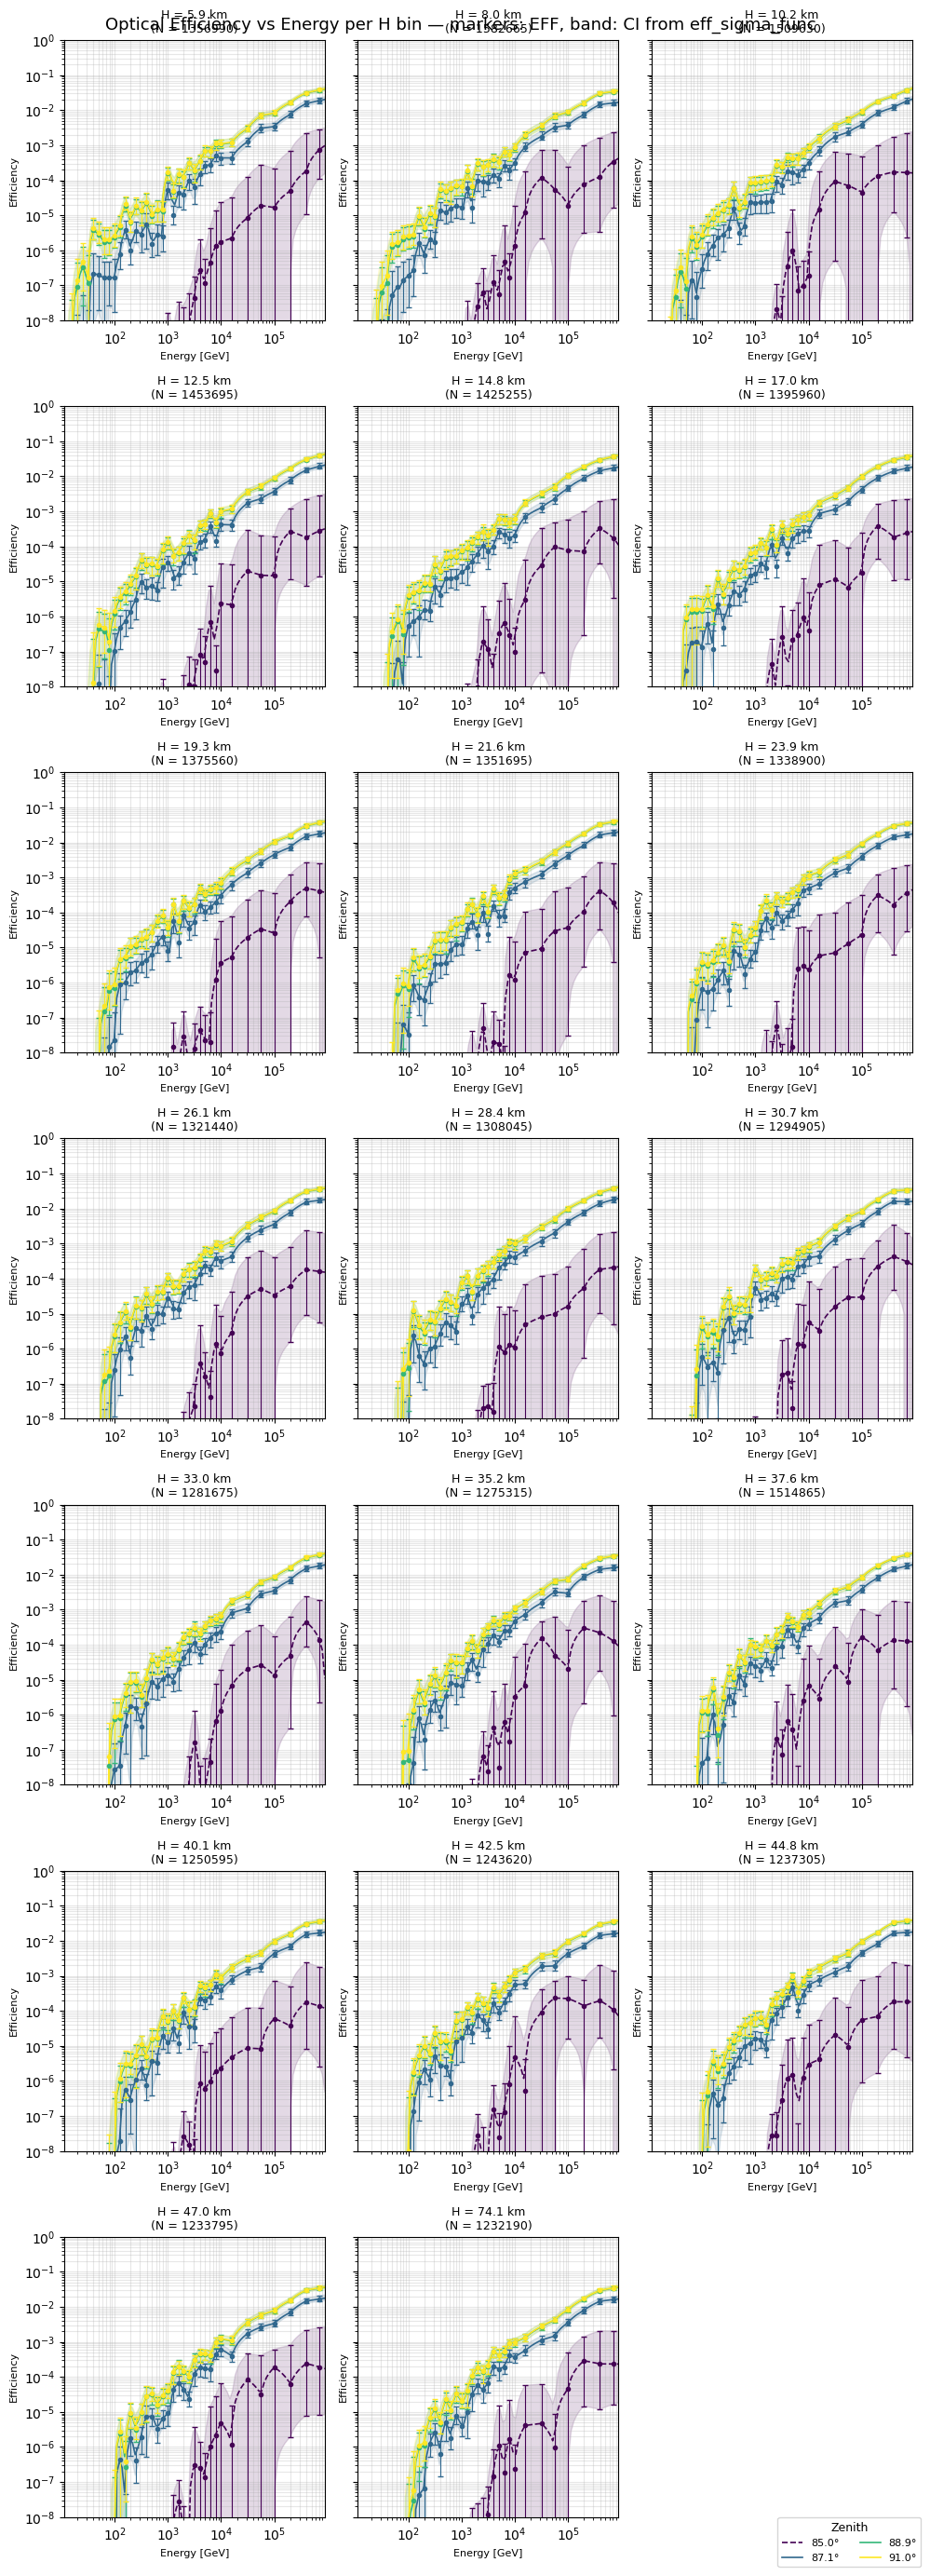

In [137]:
# Testing efficiency vs Energy per zenith
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

n_H = len(H_cen)
n_Z = len(Zen_grid)

ncols = 3
nrows = int(np.ceil(n_H / ncols))

MAX_ZEN_LINES = 4

# Subsample zenith indices to at most MAX_ZEN_LINES (evenly spaced)
if n_Z <= MAX_ZEN_LINES:
    zen_inds = np.arange(n_Z)
else:
    zen_inds = np.linspace(0, n_Z - 1, MAX_ZEN_LINES).round().astype(int)
    zen_inds = np.unique(zen_inds)

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(10, 4 * nrows),
    sharey=True,
)
axes = np.atleast_1d(axes).ravel()

colors = cm.viridis(np.linspace(0, 1, len(zen_inds)))

E_plot = np.logspace(np.log10(E_edges[0]), np.log10(E_edges[-1]), 100)

for j in range(n_H):
    ax = axes[j]
    H_val = H_cen[j]

    for ci, k in enumerate(zen_inds):
        zen = Zen_grid[k]
        # --- interpolator (smooth line + CI band) ---
        med_curve, lo_curve, hi_curve = eff_sigma_func(
            E_plot,
            np.full_like(E_plot, H_val),
            np.full_like(E_plot, zen),
        )

        ax.plot(
            E_plot, med_curve,
            color=colors[ci],
            linestyle='-' if zen > 87 else '--',
            linewidth=1.2,
            label=f"{zen:.1f}°",
        )
        ax.fill_between(E_plot, lo_curve, hi_curve,
                        color=colors[ci], alpha=0.15)

        # --- raw EFF with asymmetric error bars (markers) ---
        eff_row = EFF[k, j, :]
        valid = np.isfinite(eff_row)
        if valid.any():
            med_pts, lo_pts, hi_pts = eff_sigma_func(
                E_cen[valid],
                np.full_like(E_cen[valid], H_val),
                np.full_like(E_cen[valid], zen),
            )
            yerr = np.vstack([
                np.clip(eff_row[valid] - lo_pts, 0, None),
                np.clip(hi_pts - eff_row[valid], 0, None),
            ])
            ax.errorbar(
                E_cen[valid], eff_row[valid],
                yerr=yerr,
                color=colors[ci],
                marker='o',
                markersize=3,
                linestyle='none',
                elinewidth=0.8,
                capsize=2,
            )

    ax.set_xscale('log')
    ax.set_xlim(E_edges[0], E_edges[-1])
    ax.set_ylim(1e-8, 1)
    ax.set_yscale("log")
    ax.set_title(
        f"H = {H_cen[j]/1e3:.1f} km\n"
        f"(N = {COUNTS[:, j, :].sum()})",
        fontsize=9,
    )
    ax.set_xlabel("Energy [GeV]", fontsize=8)
    ax.set_ylabel("Efficiency",   fontsize=8)
    ax.grid(True, which='both', alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Zenith",
    loc='lower right',
    ncol=2,
    fontsize=8,
    title_fontsize=9,
    bbox_to_anchor=(1.0, 0.0),
)

for j in range(n_H, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Optical Efficiency vs Energy per H bin — markers: EFF, band: CI from eff_sigma_func",
             fontsize=13)
plt.tight_layout()
plt.show()


Extending from largest zenith 89.9503° up to 91.8°
Total zenith bins after extension: 68 (range 91.750° → 85.069°)
Slope     m = -3.588042e-03 ± 8.871475e-05
Intercept b = 2.258685e-02 ± 3.836463e-04
Weighted R² = 0.99332
Effective Area (central) = 412328.7528 cm²
Effective Area (MC mean) = 4125776221.44 ± 80757974.36 cm²


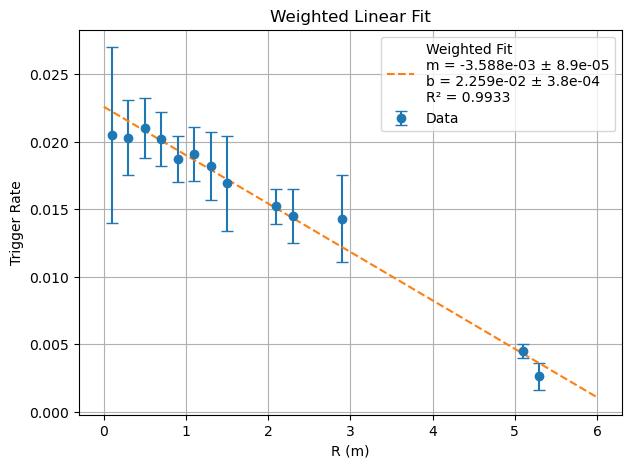

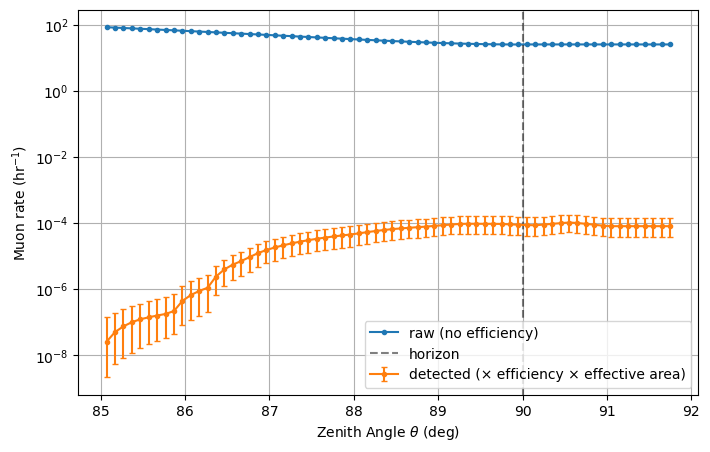

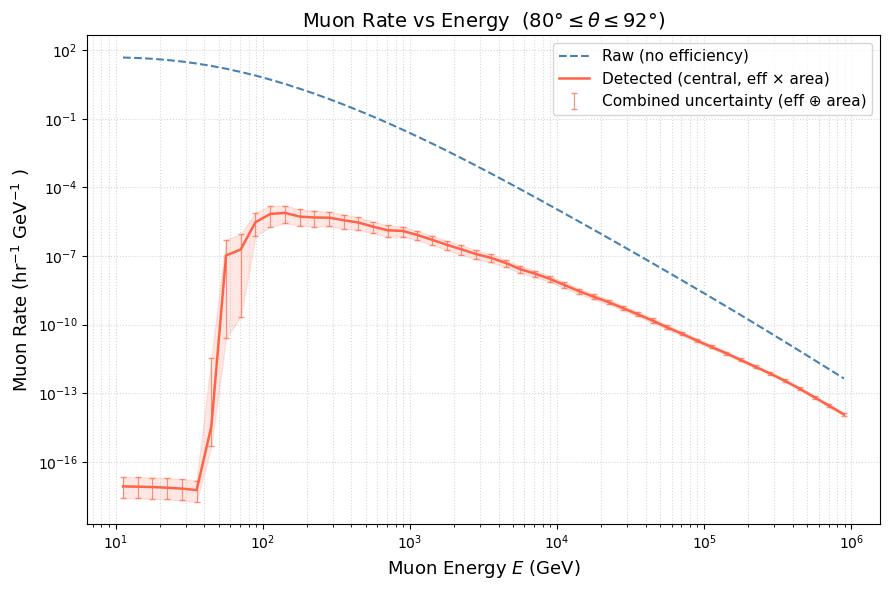


--- Muon Rates per Hour ---
Total (raw, no efficiency):  2731.791243556869
Detected (central):          0.0035426533417954997
  ± eff uncertainty (lo/hi): -0.0018378854489006942 / +0.002667669867474091
  ± area uncertainty:        ±6.934392278801335e-05
  ± combined (lo/hi):        -0.0018391931662847534 / +0.002668570984901257

Final: 0.0035426533417954997  [0.0017034601755107463, 0.006211224326696756]  muons/hour


In [163]:
# Extrapolate to high zenith
import pickle
import numpy as np
import matplotlib.pyplot as plt

# =========================================================================
# 2. Load the precomputed MCEq grid
# =========================================================================
with open('/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/data/'
          'mceq_grid_80_90deg.pkl', 'rb') as f:
    grid_data = pickle.load(f)

zen_centers_all = grid_data['zen_centers']
cos_edges       = grid_data['cos_edges']
E_GeV           = grid_data['E_GeV']
min_E           = ENERGY_MIN #grid_data['min_E']
max_E           = ENERGY_MAX #grid_data['max_E']

zen_min_use, zen_max_use = ZEN_MIN, 90.0
tele_azimuth = 270

zen_mask = (zen_centers_all >= zen_min_use) & (zen_centers_all <= zen_max_use)
if not np.any(zen_mask):
    raise ValueError(
        f"No zenith bins in [{zen_min_use}, {zen_max_use}] deg. "
        f"Available centers: {zen_centers_all}"
    )

zen_centers = zen_centers_all[zen_mask]

min_az, max_az = tele_azimuth - AZIMUTH_RANGE, tele_azimuth + AZIMUTH_RANGE
dphi = np.radians(max_az - min_az)
dcos = np.diff(cos_edges)
solid_angles_all = dphi * np.abs(dcos)
solid_angles     = solid_angles_all[zen_mask]

selected_entries = [e for e, keep in zip(grid_data['per_zenith'], zen_mask) if keep]

# =========================================================================
# 2b. EXTEND to 92°
# =========================================================================
extend_to_deg   = 91.8
extra_bin_width = 0.1

idx_max = int(np.argmax(zen_centers))
last_entry = selected_entries[idx_max]
last_theta = last_entry['theta']
print(f"Extending from largest zenith {last_theta:.4f}° up to {extend_to_deg}°")

extra_centers = np.arange(last_theta + extra_bin_width,
                          extend_to_deg + 1e-9,
                          extra_bin_width)

extra_solid_angles = []
for zc in extra_centers:
    c_lo = np.cos(np.radians(zc - extra_bin_width/2))
    c_hi = np.cos(np.radians(zc + extra_bin_width/2))
    extra_solid_angles.append(dphi * abs(c_lo - c_hi))
extra_solid_angles = np.array(extra_solid_angles)

extra_entries = []
for zc in extra_centers:
    extra_entries.append({
        'theta':    zc,
        'd_CDF':    last_entry['d_CDF'],
        'H_grid':   last_entry['H_grid'],
        'sum_mceq': last_entry['sum_mceq'],
        'X_grid':  last_entry['X_grid'],
    })

zen_centers      = np.concatenate([zen_centers, extra_centers])
solid_angles     = np.concatenate([solid_angles, extra_solid_angles])
selected_entries = selected_entries + extra_entries

order = np.argsort(zen_centers)[::-1]
zen_centers      = zen_centers[order]
solid_angles     = solid_angles[order]
selected_entries = [selected_entries[i] for i in order]

print(f"Total zenith bins after extension: {len(zen_centers)} "
      f"(range {zen_centers[0]:.3f}° → {zen_centers[-1]:.3f}°)")

# =========================================================================
# 3. Loop over zenith and apply efficiency via eff_func / eff_sigma_func
# =========================================================================
Total_flux_raw           = []
Total_flux_detected2     = []
Total_flux_detected2_lo  = []
Total_flux_detected2_hi  = []
eff_map     = []
eff_map_lo  = []
eff_map_hi  = []
flux_E_central_list = []
flux_E_lo_list      = []
flux_E_hi_list      = []
flux_E_raw_list     = []
for i, entry in enumerate(selected_entries):
    theta    = entry['theta']
    d_CDF    = entry['d_CDF']
    H_grid   = entry['H_grid']
    sum_mceq = entry['sum_mceq']
    X_grid = entry['X_grid'] #g/cm^2
    H_m = H_grid / 100.0 #cm to meter
    Solid_angle = solid_angles[i]

    theta_q = min(theta, Zen_grid[-1])

    H_mesh, E_mesh = np.meshgrid(H_m, E_GeV, indexing='ij')
    Z_mesh = np.full_like(H_mesh, theta_q)

    eff_HE2 = eff_func(E_mesh, H_mesh, Z_mesh)
    eff_HE2 = np.nan_to_num(eff_HE2, nan=0.0)

    med_HE2, lo_HE2, hi_HE2 = eff_sigma_func(E_mesh, H_mesh, Z_mesh)
    lo_HE2 = np.nan_to_num(lo_HE2, nan=0.0)
    hi_HE2 = np.nan_to_num(hi_HE2, nan=0.0)

    E_mask = (E_GeV >= min_E) & (E_GeV <= max_E)

    CDF = np.cumsum(d_CDF, axis=0)
    CDF_positive = np.cumsum(np.clip(d_CDF, 0, None), axis=0)
    survival_prob_per_E = abs(CDF[-1] / CDF_positive[-1])

    integrand_HE2 = np.clip(d_CDF, 0, None) * eff_HE2 * survival_prob_per_E
    d_CDF_det_E   = np.trapezoid(integrand_HE2[:, E_mask], E_GeV[E_mask], axis=1)
    detected_at_ground2 = np.cumsum(d_CDF_det_E, axis=0)[-1]

    integrand_lo = np.clip(d_CDF, 0, None) * lo_HE2 * survival_prob_per_E
    integrand_hi = np.clip(d_CDF, 0, None) * hi_HE2 * survival_prob_per_E
    d_CDF_det_E_lo = np.trapezoid(integrand_lo[:, E_mask], E_GeV[E_mask], axis=1)
    d_CDF_det_E_hi = np.trapezoid(integrand_hi[:, E_mask], E_GeV[E_mask], axis=1)
    detected_lo = np.cumsum(d_CDF_det_E_lo, axis=0)[-1]
    detected_hi = np.cumsum(d_CDF_det_E_hi, axis=0)[-1]

    weights = survival_prob_per_E * np.clip(d_CDF, 0, None)
    weight_sum = weights.sum(axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        eff_vs_E = np.where(
            weight_sum > 0,
            (weights * eff_HE2).sum(axis=0) / weight_sum,
            np.nan,
        )
        eff_vs_E_lo = np.where(
            weight_sum > 0,
            (weights * lo_HE2).sum(axis=0) / weight_sum,
            np.nan,
        )
        eff_vs_E_hi = np.where(
            weight_sum > 0,
            (weights * hi_HE2).sum(axis=0) / weight_sum,
            np.nan,
        )

    cos_factor = 1
    Total_flux_raw.append(          sum_mceq            * Solid_angle * cos_factor)
    Total_flux_detected2.append(    detected_at_ground2 * Solid_angle * cos_factor)
    Total_flux_detected2_lo.append( detected_lo         * Solid_angle * cos_factor)
    Total_flux_detected2_hi.append( detected_hi         * Solid_angle * cos_factor)
    eff_map.append(eff_vs_E)
    eff_map_lo.append(eff_vs_E_lo)
    eff_map_hi.append(eff_vs_E_hi)
    # =========================================================================
    # Energy-resolved flux: integrate over height only, keep E axis
    # shape: (n_E,)
    integrand_HE2_E = np.clip(d_CDF, 0, None) * eff_HE2 * survival_prob_per_E  # (n_H, n_E)
    
    flux_vs_E_central = np.sum(integrand_HE2_E, axis=0) #           # (n_E,)
    
    integrand_lo_E    = np.clip(d_CDF, 0, None) * lo_HE2 * survival_prob_per_E
    integrand_hi_E    = np.clip(d_CDF, 0, None) * hi_HE2 * survival_prob_per_E
    flux_vs_E_lo      = np.sum(integrand_lo_E, axis=0)#
    flux_vs_E_hi      = np.sum(integrand_hi_E, axis=0)#

    # raw: no efficiency
    flux_vs_E_raw     = np.sum(d_CDF, axis=0) #
    flux_E_central_list.append(flux_vs_E_central * Solid_angle * cos_factor)
    flux_E_lo_list.append(     flux_vs_E_lo      * Solid_angle * cos_factor)
    flux_E_hi_list.append(     flux_vs_E_hi      * Solid_angle * cos_factor)
    flux_E_raw_list.append(    flux_vs_E_raw      * Solid_angle * cos_factor)

Total_flux_raw          = np.array(Total_flux_raw)
Total_flux_detected2    = np.array(Total_flux_detected2)
Total_flux_detected2_lo = np.array(Total_flux_detected2_lo)
Total_flux_detected2_hi = np.array(Total_flux_detected2_hi)
eff_map    = np.array(eff_map)
eff_map_lo = np.array(eff_map_lo)
eff_map_hi = np.array(eff_map_hi)

# =========================================================================
# 4. Effective area from digitized trigger-rate data
# =========================================================================

# --- Digitized data ---
R_data = np.array([
    0.10, 0.30, 0.50, 0.70, 0.90,
    1.10, 1.30, 1.50, 2.10, 2.30,
    2.90, 5.10, 5.30
])

trigger_data = np.array([
    0.0205, 0.0203, 0.0210, 0.0202,
    0.0187, 0.0191, 0.0182, 0.0169,
    0.0152, 0.0145, 0.0143,
    0.0045, 0.0026
])

trigger_rate_err = np.array([
    0.0065, 0.0028, 0.0022, 0.0020,
    0.0017, 0.0020, 0.0025, 0.0035,
    0.0013, 0.0020, 0.0032, 0.0005,
    0.0010
])

# --- Weighted linear fit ---
fit_weights = 1.0 / trigger_rate_err**2

(p, cov_fit) = np.polyfit(
    R_data,
    trigger_data,
    deg=1,
    w=np.sqrt(fit_weights),
    cov=True
)

m_fit, b_fit = p
m_err = np.sqrt(cov_fit[0, 0])
b_err = np.sqrt(cov_fit[1, 1])

print(f"Slope     m = {m_fit:.6e} ± {m_err:.6e}")
print(f"Intercept b = {b_fit:.6e} ± {b_err:.6e}")

# --- Weighted R² ---
y_fit        = m_fit * R_data + b_fit
weighted_mean = np.average(trigger_data, weights=fit_weights)
ss_res = np.sum(fit_weights * (trigger_data - y_fit)**2)
ss_tot = np.sum(fit_weights * (trigger_data - weighted_mean)**2)
r_squared = 1 - ss_res / ss_tot
print(f"Weighted R² = {r_squared:.5f}")

# --- Central effective area ---
r_grid = np.linspace(0, 6, 10000)
trigger_rate_r      = np.clip(m_fit * r_grid + b_fit, 0, None)
trigger_rate_r_norm = trigger_rate_r / trigger_rate_r.max()
effective_area_central = 2 * np.pi * np.trapezoid(
    trigger_rate_r_norm * r_grid, x=r_grid
)
print(f"Effective Area (central) = {effective_area_central * 1e4:.4f} cm²")

# --- Monte Carlo uncertainty propagation ---
N_mc = 1000
samples = np.random.multivariate_normal(
    mean=[m_fit, b_fit],
    cov=cov_fit,
    size=N_mc
)

area_samples = []
for m_i, b_i in samples:
    trigger_i = np.clip(m_i * r_grid + b_i, 0, None)
    if trigger_i.max() <= 0:
        continue
    trigger_i_norm = trigger_i / trigger_i.max()
    area_i = 2 * np.pi * np.trapezoid(trigger_i_norm * r_grid, x=r_grid)
    area_samples.append(area_i)

area_samples = np.array(area_samples) * 1e4 #convert to cm^2

effective_area_mean = np.mean(area_samples) 
effective_area_std  = np.std(area_samples) 

print(f"Effective Area (MC mean) = {effective_area_mean * 1e4:.2f} ± "
      f"{effective_area_std * 1e4:.2f} cm²")

# --- Fit plot ---
plt.figure(figsize=(7, 5))
plt.errorbar(R_data, trigger_data, yerr=trigger_rate_err,
             fmt='o', capsize=4, label='Data')
plt.plot(r_grid, (m_fit * r_grid + b_fit), '--',
         label=(f'Weighted Fit\n'
                f'm = {m_fit:.3e} ± {m_err:.1e}\n'
                f'b = {b_fit:.3e} ± {b_err:.1e}\n'
                f'R² = {r_squared:.4f}'))
plt.xlabel("R (m)")
plt.ylabel("Trigger Rate")
plt.title("Weighted Linear Fit")
plt.grid(True)
plt.legend()
plt.show()

# =========================================================================
# 5. Muon rates with combined efficiency + effective-area uncertainties
# =========================================================================

# Summed fluxes (units: cm⁻² s⁻¹ sr⁻¹  ×  sr  →  cm⁻² s⁻¹)
flux_central = np.sum(Total_flux_detected2)
flux_lo      = np.sum(Total_flux_detected2_lo)
flux_hi      = np.sum(Total_flux_detected2_hi)
flux_raw     = np.sum(Total_flux_raw)

# Central rates  (× effective area [cm²] × seconds per hour)
seconds_per_hour = 3600.0
Rate_central = flux_central * effective_area_mean * seconds_per_hour
Rate_raw     = flux_raw     * effective_area_mean * seconds_per_hour

# --- Uncertainty from efficiency (asymmetric) ---
dRate_eff_lo = (flux_central - flux_lo) * effective_area_mean * seconds_per_hour
dRate_eff_hi = (flux_hi - flux_central) * effective_area_mean * seconds_per_hour

# --- Uncertainty from effective area (symmetric, from MC std) ---
dRate_area   = flux_central * effective_area_std * seconds_per_hour

# --- Combined uncertainties (add in quadrature) ---
dRate_total_lo = np.sqrt(dRate_eff_lo**2 + dRate_area**2)
dRate_total_hi = np.sqrt(dRate_eff_hi**2 + dRate_area**2)

# --- Plot muon rate per hour vs zenith ---
seconds_per_hour = 3600.0

# Convert fluxes → muons/hour using effective area (already in cm²)
Rate_raw_zen      = Total_flux_raw       * effective_area_mean * seconds_per_hour
Rate_det_zen      = Total_flux_detected2 * effective_area_mean * seconds_per_hour
Rate_det_zen_lo   = Total_flux_detected2_lo * effective_area_mean * seconds_per_hour
Rate_det_zen_hi   = Total_flux_detected2_hi * effective_area_mean * seconds_per_hour

# Efficiency-driven asymmetric uncertainty
dRate_eff_lo_zen = np.clip(Rate_det_zen - Rate_det_zen_lo, 0, None)
dRate_eff_hi_zen = np.clip(Rate_det_zen_hi - Rate_det_zen, 0, None)

# Effective-area symmetric uncertainty (per-bin)
dRate_area_zen   = Total_flux_detected2 * effective_area_std * seconds_per_hour

# Combined in quadrature
dRate_lo_zen = np.sqrt(dRate_eff_lo_zen**2 + dRate_area_zen**2)
dRate_hi_zen = np.sqrt(dRate_eff_hi_zen**2 + dRate_area_zen**2)

plt.figure(figsize=(8, 5))
plt.plot(zen_centers, Rate_raw_zen, '.-', label='raw (no efficiency)')
plt.errorbar(zen_centers, Rate_det_zen,
             yerr=np.vstack([dRate_lo_zen, dRate_hi_zen]),
             fmt='.-', capsize=2,
             label='detected (× efficiency × effective area)')
plt.axvline(90, color='k', ls='--', alpha=0.5, label='horizon')
plt.xlabel(r'Zenith Angle $\theta$ (deg)')
plt.ylabel(r'Muon rate (hr$^{-1}$)')
plt.yscale('log')
plt.legend(); plt.grid(); plt.show()

# =========================================================================
# AFTER the loop, sum over zenith bins → shape (n_E,)
# =========================================================================
flux_E_central = np.sum(flux_E_central_list, axis=0)   # (n_E,)
flux_E_lo      = np.sum(flux_E_lo_list,      axis=0)
flux_E_hi      = np.sum(flux_E_hi_list,      axis=0)
flux_E_raw     = np.sum(flux_E_raw_list,     axis=0)

# =========================================================================
# Convert to rates [muons / hour] per energy bin
# =========================================================================
seconds_per_hour = 3600.0

Rate_E_central = flux_E_central * effective_area_mean * seconds_per_hour
Rate_E_lo      = flux_E_lo      * effective_area_mean * seconds_per_hour
Rate_E_hi      = flux_E_hi      * effective_area_mean * seconds_per_hour
Rate_E_raw     = flux_E_raw     * effective_area_mean * seconds_per_hour

# Asymmetric efficiency uncertainty
dRate_E_eff_lo = np.clip(Rate_E_central - Rate_E_lo, 0, None)
dRate_E_eff_hi = np.clip(Rate_E_hi - Rate_E_central, 0, None)

# Effective-area symmetric uncertainty
dRate_E_area   = flux_E_central * effective_area_std * seconds_per_hour

# Combined in quadrature
dRate_E_lo = np.sqrt(dRate_E_eff_lo**2 + dRate_E_area**2)
dRate_E_hi = np.sqrt(dRate_E_eff_hi**2 + dRate_E_area**2)

# =========================================================================
# Apply energy mask (only plot energies inside [min_E, max_E])
# =========================================================================
E_mask = (E_GeV >= min_E) & (E_GeV <= max_E)
E_plot          = E_GeV[E_mask]
Rate_E_c_plot   = Rate_E_central[E_mask]
Rate_E_raw_plot = Rate_E_raw[E_mask]
dRate_lo_plot   = dRate_E_lo[E_mask]
dRate_hi_plot   = dRate_E_hi[E_mask]

# =========================================================================
# Plot
# =========================================================================
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(E_plot, Rate_E_raw_plot,
        color='steelblue', ls='--', lw=1.5,
        label='Raw (no efficiency)')

ax.errorbar(E_plot, Rate_E_c_plot,
            yerr=np.vstack([dRate_lo_plot, dRate_hi_plot]),
            fmt='none',
            ecolor='tomato', elinewidth=0.8, capsize=2, alpha=0.7,
            label='Combined uncertainty (eff ⊕ area)')

ax.plot(E_plot, Rate_E_c_plot,
        color='tomato', lw=1.8,
        label='Detected (central, eff × area)')

ax.fill_between(E_plot,
                Rate_E_c_plot - dRate_lo_plot,
                Rate_E_c_plot + dRate_hi_plot,
                color='tomato', alpha=0.15)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'Muon Energy $E$ (GeV)', fontsize=13)
ax.set_ylabel(r'Muon Rate (hr$^{-1}$ GeV$^{-1}$ )', fontsize=13)
ax.set_title(r'Muon Rate vs Energy  ($80° \leq \theta \leq 92°$)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, which='both', ls=':', alpha=0.5)
plt.tight_layout()
plt.show()


print("\n--- Muon Rates per Hour ---")
print(f"Total (raw, no efficiency):  {Rate_raw}")
print(f"Detected (central):          {Rate_central}")
print(f"  ± eff uncertainty (lo/hi): -{dRate_eff_lo} / +{dRate_eff_hi}")
print(f"  ± area uncertainty:        ±{dRate_area}")
print(f"  ± combined (lo/hi):        -{dRate_total_lo} / +{dRate_total_hi}")
print(f"\nFinal: {Rate_central}  [{Rate_central-dRate_total_lo}, {Rate_central+dRate_total_hi}]  muons/hour")


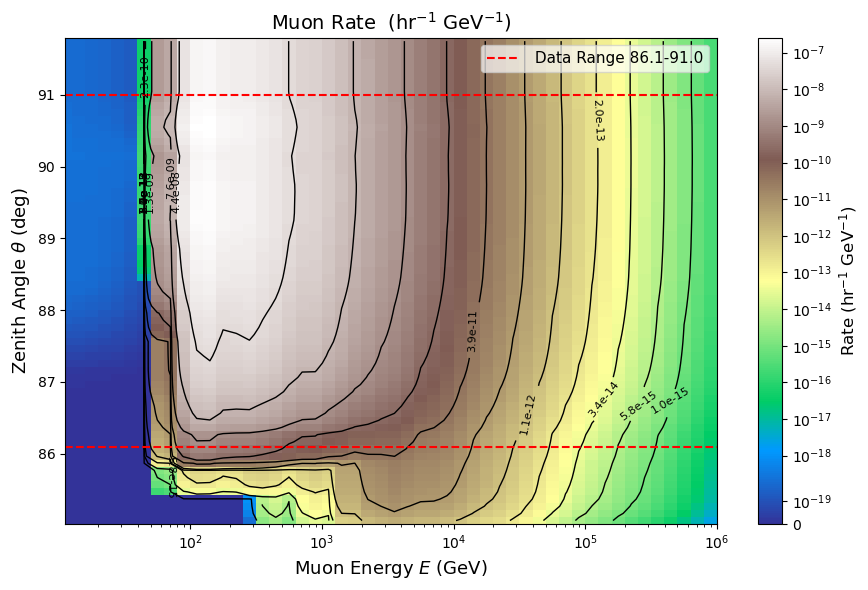

In [164]:
# 2D heatmap: muon rate per hour per GeV  vs  (Energy, Zenith)
# =========================================================================
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
import numpy as np

seconds_per_hour = 3600.0

# Stack into 2D array: shape (n_zen, n_E)
flux_E_2D = np.array(flux_E_central_list)            # (n_zen, n_E)
Rate_E_2D = flux_E_2D * effective_area_mean * seconds_per_hour  # muons/hr/GeV

# Apply energy mask
E_mask = (E_GeV >= min_E) & (E_GeV <= max_E)
E_plot = E_GeV[E_mask]
Rate_2D_plot = Rate_E_2D[:, E_mask]

# Sort zenith ascending
zen_sort_idx = np.argsort(zen_centers)
zen_plot     = zen_centers[zen_sort_idx]
Rate_2D_plot = Rate_2D_plot[zen_sort_idx, :]

# Build pcolormesh edges
logE = np.log10(E_plot)
logE_edges = np.concatenate([
    [logE[0] - 0.5*(logE[1]-logE[0])],
    0.5*(logE[:-1] + logE[1:]),
    [logE[-1] + 0.5*(logE[-1]-logE[-2])],
])
E_edges = 10**logE_edges

zen_edges = np.concatenate([
    [zen_plot[0] - 0.5*(zen_plot[1]-zen_plot[0])],
    0.5*(zen_plot[:-1] + zen_plot[1:]),
    [zen_plot[-1] + 0.5*(zen_plot[-1]-zen_plot[-2])],
])

# Mask zeros for log color scale
Z = np.where(Rate_2D_plot >= 0, Rate_2D_plot, np.nan)

fig, ax = plt.subplots(figsize=(9, 6))
pcm = ax.pcolormesh(
    E_edges, zen_edges, Z,
    norm=SymLogNorm(
        linthresh=np.nanpercentile(Z, 10),
        linscale=1.0,
        vmin=0,
        vmax=np.nanmax(Z),
        base=10,
    ),
    cmap='terrain'
)

# ---- Contour lines overlay ----
E_mesh, Zen_mesh = np.meshgrid(E_plot, zen_plot)
# Log-spaced contour levels spanning the data range
zmin = np.nanpercentile(Z, 20)
zmax = np.nanmax(Z)
if zmin > 0 and zmax > zmin:
    levels = np.logspace(-15, np.log10(zmax), 12)
    cs = ax.contour(
        E_mesh, Zen_mesh, Z,
        levels=levels,
        colors='black', linewidths=1, alpha=1,
    )
    ax.clabel(cs, inline=True, fontsize=8, fmt='%.1e')

ax.set_xscale('log')
ax.set_xlabel(r'Muon Energy $E$ (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle $\theta$ (deg)', fontsize=13)
ax.set_title(r'Muon Rate  (hr$^{-1}$ GeV$^{-1}$)', fontsize=14)

# Horizon line
ax.axhline(np.min(Zenith), color='red', ls='--', lw=1.5, label=f' Data Range {np.min(Zenith)}-{np.max(Zenith)}')
ax.axhline(np.max(Zenith), color='red', ls='--', lw=1.5)
ax.legend(loc='upper right', fontsize=11, framealpha=0.7)

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r'Rate (hr$^{-1}$ GeV$^{-1}$)', fontsize=12)

plt.tight_layout()
plt.show()


In [168]:
# 3D surface plot: muon rate per hour per GeV vs (Energy, Zenith)
# =========================================================================
import plotly.graph_objects as go
import numpy as np

seconds_per_hour = 3600.0

# Stack into 2D array: shape (n_zen, n_E)
flux_E_2D = np.array(flux_E_central_list)            # (n_zen, n_E)
Rate_E_2D = flux_E_2D * effective_area_mean * seconds_per_hour  # muons/hr/GeV

# Apply energy mask
E_mask = (E_GeV >= min_E) & (E_GeV <= max_E)
E_plot = E_GeV[E_mask]
Rate_2D_plot = Rate_E_2D[:, E_mask]

# Sort zenith ascending
zen_sort_idx = np.argsort(zen_centers)
zen_plot     = zen_centers[zen_sort_idx]
Rate_2D_plot = Rate_2D_plot[zen_sort_idx, :]

# Build meshgrid for 3D surface
E_mesh, Zen_mesh = np.meshgrid(E_plot, zen_plot)

# Replace non-positive values with NaN for log scaling
Z = np.where(Rate_2D_plot > 0, Rate_2D_plot, np.nan)

# Log10 of rate for the Z axis (makes the surface readable)
Z_log = np.log10(Z)

# ---- Build hover text ----
hover_text = np.array([
    [
        f"Energy: {E_mesh[i, j]:.3g} GeV<br>"
        f"Zenith: {Zen_mesh[i, j]:.1f}°<br>"
        f"Rate: {Z[i, j]:.3e} hr⁻¹ GeV⁻¹"
        for j in range(Z.shape[1])
    ]
    for i in range(Z.shape[0])
])

# ---- 3D Surface ----
surface = go.Surface(
    x=np.log10(E_mesh),   # log10(Energy) on X axis
    y=Zen_mesh,            # Zenith angle on Y axis
    z=Z_log,               # log10(Rate) on Z axis
    surfacecolor=Z_log,
    colorscale="Viridis",
    colorbar=dict(
        title=dict(text="log₁₀(Rate)<br>[hr⁻¹ GeV⁻¹]", side="right"),
        thickness=18,
        len=0.75,
    ),
    text=hover_text,
    hoverinfo="text",
    opacity=0.92,
    contours=dict(
        z=dict(
            show=True,
            usecolormap=True,
            highlightcolor="white",
            project_z=False,
            width=1,
        ),
        x=dict(show=False),
        y=dict(show=False),
    ),
    lighting=dict(
        ambient=0.6,
        diffuse=0.8,
        roughness=0.5,
        specular=0.3,
    ),
)

# ---- Horizon / zenith range planes ----
zen_min_val = float(np.min(Zenith))
zen_max_val = float(np.max(Zenith))

logE_range = [float(np.log10(E_plot.min())), float(np.log10(E_plot.max()))]
z_range    = [float(np.nanmin(Z_log)),        float(np.nanmax(Z_log))]

def zenith_plane(zen_val, color, name):
    """Vertical plane at a fixed zenith angle."""
    xs = np.array([[logE_range[0], logE_range[1]],
                   [logE_range[0], logE_range[1]]])
    ys = np.full_like(xs, zen_val)
    zs = np.array([[z_range[0], z_range[0]],
                   [z_range[1], z_range[1]]])
    return go.Surface(
        x=xs, y=ys, z=zs,
        colorscale=[[0, color], [1, color]],
        showscale=False,
        opacity=0.25,
        name=name,
        hoverinfo="skip",
    )

plane_min = zenith_plane(zen_min_val, "red",  f"θ = {zen_min_val:.0f}°")
plane_max = zenith_plane(zen_max_val, "red",  f"θ = {zen_max_val:.0f}°")

# ---- Tick marks for log10(E) axis ----
# Show integer powers of 10 within the energy range
log_ticks  = np.arange(
    np.ceil(np.log10(E_plot.min())),
    np.floor(np.log10(E_plot.max())) + 1,
    dtype=int,
)
tick_vals  = log_ticks.tolist()
tick_text  = [f"10<sup>{v}</sup>" for v in log_ticks]

# ---- Tick marks for log10(Rate) Z axis ----
z_log_min = np.floor(np.nanmin(Z_log))
z_log_max = np.ceil(np.nanmax(Z_log))
z_ticks   = np.arange(z_log_min, z_log_max + 1, dtype=int).tolist()
z_tick_text = [f"10<sup>{v}</sup>" for v in z_ticks]

# ---- Layout ----
fig = go.Figure(data=[surface, plane_min, plane_max])

fig.update_layout(
    title=dict(
        text="Muon Rate  (hr⁻¹ GeV⁻¹) vs Energy & Zenith Angle",
        x=0.5,
        font=dict(size=16),
    ),
    scene=dict(
        xaxis=dict(
            title="Muon Energy (GeV)",
            tickvals=tick_vals,
            ticktext=tick_text,
            showgrid=True,
            gridcolor="lightgrey",
            backgroundcolor="rgb(240,240,255)",
        ),
        yaxis=dict(
            title="Zenith Angle θ (deg)",
            showgrid=True,
            gridcolor="lightgrey",
            backgroundcolor="rgb(240,255,240)",
        ),
        zaxis=dict(
            title="Rate (hr⁻¹ GeV⁻¹)",
            tickvals=z_ticks,
            ticktext=z_tick_text,
            showgrid=True,
            gridcolor="lightgrey",
            backgroundcolor="rgb(255,245,240)",
        ),
        camera=dict(
            eye=dict(x=1.6, y=-1.6, z=0.9),  # initial viewing angle
        ),
        aspectmode="manual",
        aspectratio=dict(x=1.4, y=1.0, z=0.9),
    ),
    margin=dict(l=0, r=0, t=60, b=0),
    width=950,
    height=720,
    legend=dict(
        x=0.01, y=0.95,
        bgcolor="rgba(255,255,255,0.7)",
        bordercolor="grey",
        borderwidth=1,
    ),
)

fig.show()
fig.write_html("/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/plot/muon_rate_3d.html")

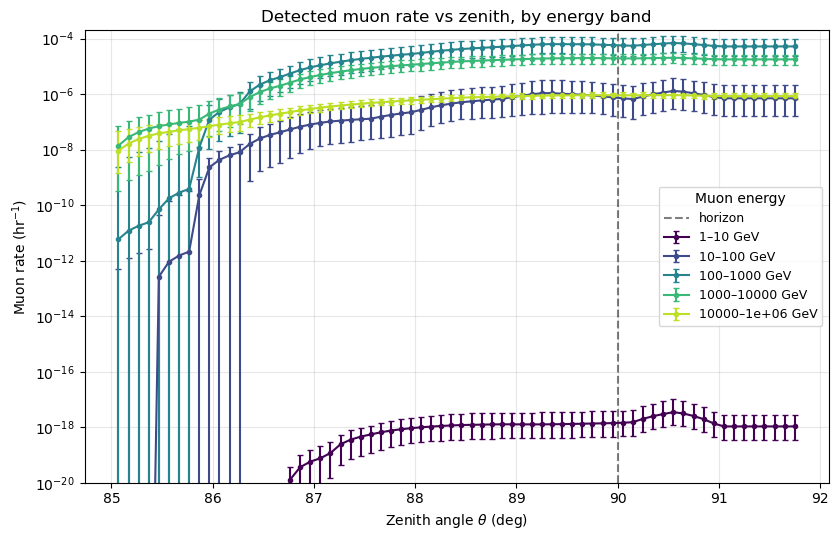

In [140]:
#Muon rate per hour vs zenith, split by energy band
# =========================================================================

# Define energy bands [GeV] — edit as needed
E_bands = [
    (1.0,    10.0),
    (10.0,   100.0),
    (100.0,  1e3),
    (1e3,    1e4),
    (1e4,    1e6),
]
band_labels = [f"{lo:g}–{hi:g} GeV" for lo, hi in E_bands]

n_zen   = len(selected_entries)
n_bands = len(E_bands)

flux_band     = np.zeros((n_bands, n_zen))
flux_band_lo  = np.zeros((n_bands, n_zen))
flux_band_hi  = np.zeros((n_bands, n_zen))

for i, entry in enumerate(selected_entries):
    theta    = entry['theta']
    d_CDF    = entry['d_CDF']
    H_grid   = entry['H_grid']
    H_m      = H_grid / 100.0
    Solid_angle = solid_angles[i]
    theta_q  = min(theta, Zen_grid[-1])

    H_mesh, E_mesh = np.meshgrid(H_m, E_GeV, indexing='ij')
    Z_mesh = np.full_like(H_mesh, theta_q)

    eff_HE2 = np.nan_to_num(eff_func(E_mesh, H_mesh, Z_mesh), nan=0.0)
    med_HE2, lo_HE2, hi_HE2 = eff_sigma_func(E_mesh, H_mesh, Z_mesh)
    lo_HE2 = np.nan_to_num(lo_HE2, nan=0.0)
    hi_HE2 = np.nan_to_num(hi_HE2, nan=0.0)

    CDF = np.cumsum(d_CDF, axis=0)
    CDF_pos = np.cumsum(np.clip(d_CDF, 0, None), axis=0)
    survival_prob_per_E = CDF[-1] / CDF_pos[-1]

    integrand    = np.clip(d_CDF, 0, None) * eff_HE2 * survival_prob_per_E
    integrand_lo = np.clip(d_CDF, 0, None) * lo_HE2  * survival_prob_per_E
    integrand_hi = np.clip(d_CDF, 0, None) * hi_HE2  * survival_prob_per_E

    for b, (E_lo, E_hi) in enumerate(E_bands):
        mask = (E_GeV >= E_lo) & (E_GeV <= E_hi)
        if mask.sum() < 2:
            continue
        d_E    = np.trapezoid(integrand[:,    mask], E_GeV[mask], axis=1)
        d_E_lo = np.trapezoid(integrand_lo[:, mask], E_GeV[mask], axis=1)
        d_E_hi = np.trapezoid(integrand_hi[:, mask], E_GeV[mask], axis=1)

        flux_band[b, i]    = np.cumsum(d_E,    axis=0)[-1] * Solid_angle
        flux_band_lo[b, i] = np.cumsum(d_E_lo, axis=0)[-1] * Solid_angle
        flux_band_hi[b, i] = np.cumsum(d_E_hi, axis=0)[-1] * Solid_angle

# Convert to muons/hour
Rate_band    = flux_band    * effective_area_mean * seconds_per_hour
Rate_band_lo = flux_band_lo * effective_area_mean * seconds_per_hour
Rate_band_hi = flux_band_hi * effective_area_mean * seconds_per_hour

# Asymmetric eff errors + symmetric area error, in quadrature
dLo_eff = np.clip(Rate_band    - Rate_band_lo, 0, None)
dHi_eff = np.clip(Rate_band_hi - Rate_band,    0, None)
dArea   = flux_band * effective_area_std * seconds_per_hour

dLo = np.sqrt(dLo_eff**2 + dArea**2)
dHi = np.sqrt(dHi_eff**2 + dArea**2)

# Sort by zenith for clean lines
order_z = np.argsort(zen_centers)
zc_sorted = zen_centers[order_z]

plt.figure(figsize=(8.5, 5.5))
colors = plt.cm.viridis(np.linspace(0, 0.9, n_bands))
for b in range(n_bands):
    y   = Rate_band[b, order_z]
    elo = dLo[b, order_z]
    ehi = dHi[b, order_z]
    plt.errorbar(zc_sorted, y, yerr=np.vstack([elo, ehi]),
                 fmt='.-', capsize=2, color=colors[b],
                 label=band_labels[b])

plt.axvline(90, color='k', ls='--', alpha=0.5, label='horizon')
plt.xlabel(r'Zenith angle $\theta$ (deg)')
plt.ylabel(r'Muon rate (hr$^{-1}$)')
plt.yscale('log')
plt.ylim(1e-20, 2e-4)
plt.title('Detected muon rate vs zenith, by energy band')
plt.grid(True, which='both', alpha=0.3)
plt.legend(title='Muon energy', fontsize=9)
plt.tight_layout()
plt.show()


In [141]:
import pickle
from matplotlib.colors import SymLogNorm
#E_mask_plot = (E_GeV > 5e1) & (E_GeV < 5e5)

# =========================================================================
# Build flux_raw_map from selected_entries (shape: n_zen x n_E)
# Each entry['d_CDF'] has shape (n_H, n_E); sum over H axis to get per-E flux
# =========================================================================
flux_raw_map = np.full((len(selected_entries), len(E_GeV)), np.nan)
for i, entry in enumerate(selected_entries):
    d = entry['d_CDF']
    # d_CDF may be (n_H, n_E) or (n_E,) depending on MCEq grid structure
    flux_raw_map[i, :] = d.sum(axis=0) if d.ndim == 2 else d

# =========================================================================
# Efficiency asymmetric half-widths  (n_zen, n_E)
# =========================================================================
eff_map_err_lo = np.clip(eff_map - eff_map_lo, 0, None)   # downward uncertainty
eff_map_err_hi = np.clip(eff_map_hi - eff_map, 0, None)   # upward uncertainty
eff_map_err    = 0.5 * (eff_map_err_lo + eff_map_err_hi)  # symmetric mid-point for plotting

# Muon flux × efficiency
flux_x_eff_map     = flux_raw_map * eff_map      # (n_zen, n_E)
flux_x_eff_err_map = flux_raw_map * eff_map_err  # (n_zen, n_E)

E_save_mask = (E_GeV >= 1e1) & (E_GeV <= 1e6)

eff_map_output = {
    'zen_centers':   zen_centers,
    'E_GeV':         E_GeV[E_save_mask],
    'H_grid':        selected_entries[0]['H_grid'],
    'eff_map':       eff_map[:, E_save_mask],
    'eff_map_lo':    eff_map_lo[:, E_save_mask],
    'eff_map_hi':    eff_map_hi[:, E_save_mask],
    'eff_map_err':   eff_map_err[:, E_save_mask],   # symmetric half-width
    'min_E':         1e1,
    'max_E':         1e6,
    'zen_range':     (zen_min_use, zen_max_use),
    'extend_to_deg': extend_to_deg,
}

out_path = '/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/data/eff_map_80_92deg.pkl'
with open(out_path, 'wb') as f:
    pickle.dump(eff_map_output, f)

print(f"Saved eff_map to {out_path}")
print(f"  E range:           {E_GeV[E_save_mask].min():.1e} – {E_GeV[E_save_mask].max():.1e} GeV  ({E_save_mask.sum()} bins)")
print(f"  eff_map shape:     {eff_map[:, E_save_mask].shape}")
print(f"  eff_map_lo shape:  {eff_map_lo[:, E_save_mask].shape}")
print(f"  eff_map_hi shape:  {eff_map_hi[:, E_save_mask].shape}")
print(f"  eff_map_err shape: {eff_map_err[:, E_save_mask].shape}")


Saved eff_map to /uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/data/eff_map_80_92deg.pkl
  E range:           1.1e+01 – 8.9e+05 GeV  (50 bins)
  eff_map shape:     (68, 50)
  eff_map_lo shape:  (68, 50)
  eff_map_hi shape:  (68, 50)
  eff_map_err shape: (68, 50)


Zenith bins: 68  (91.75° → 85.07°)
Energy bins: 50  (1.12e+01 → 8.91e+05 GeV)
eff_map shape:     (68, 50)
eff_map_lo shape:  (68, 50)
eff_map_hi shape:  (68, 50)
eff_map_err shape: (68, 50)


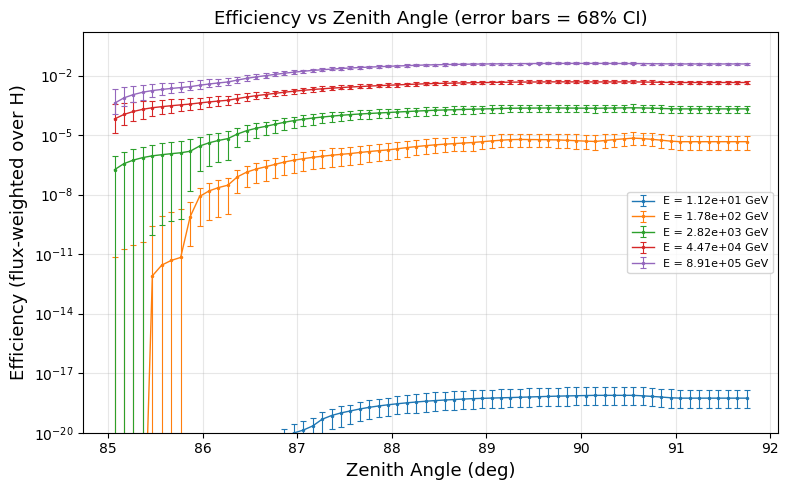

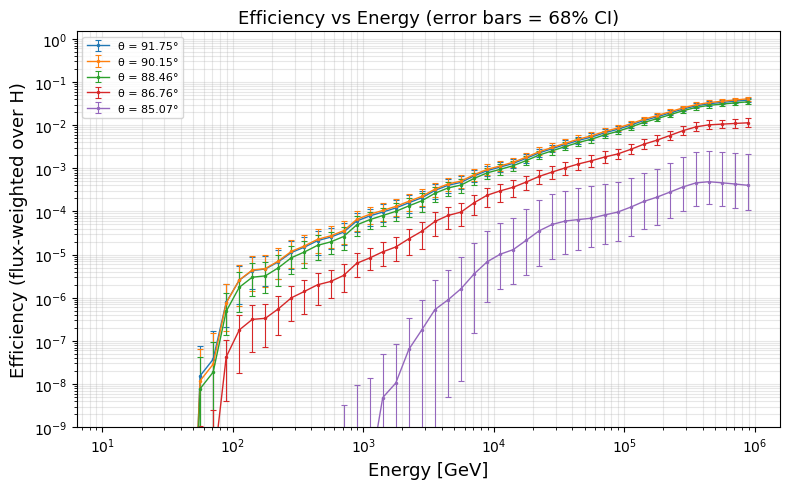

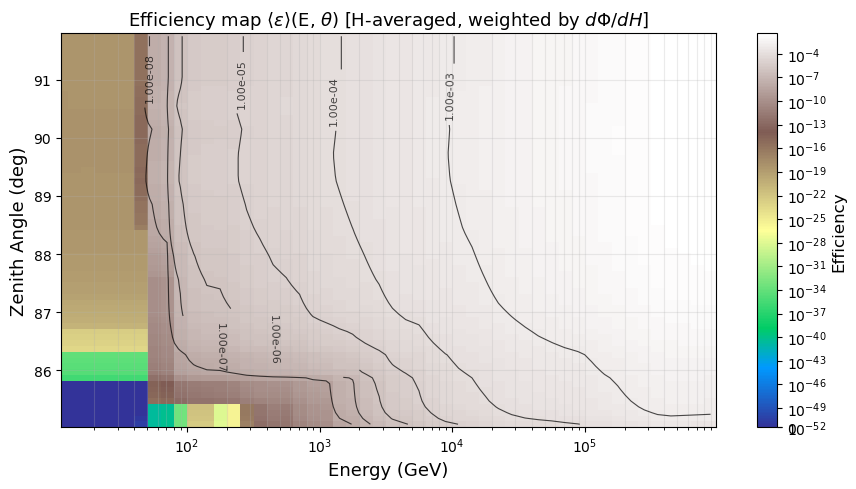

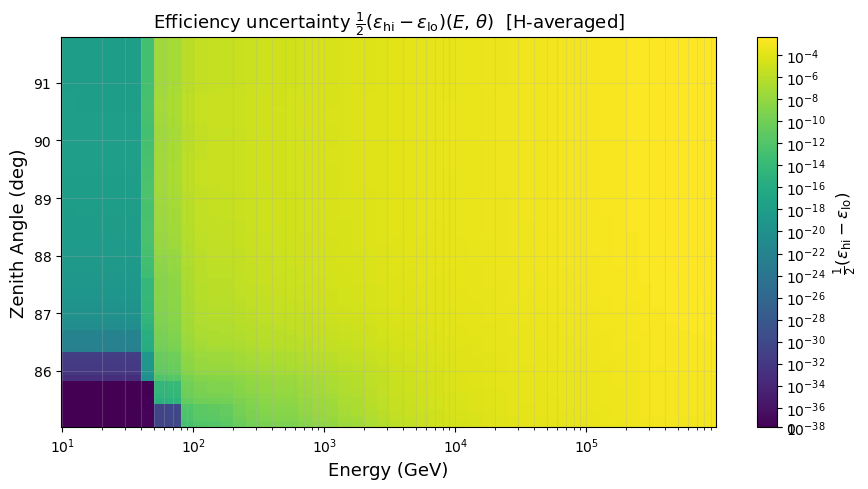

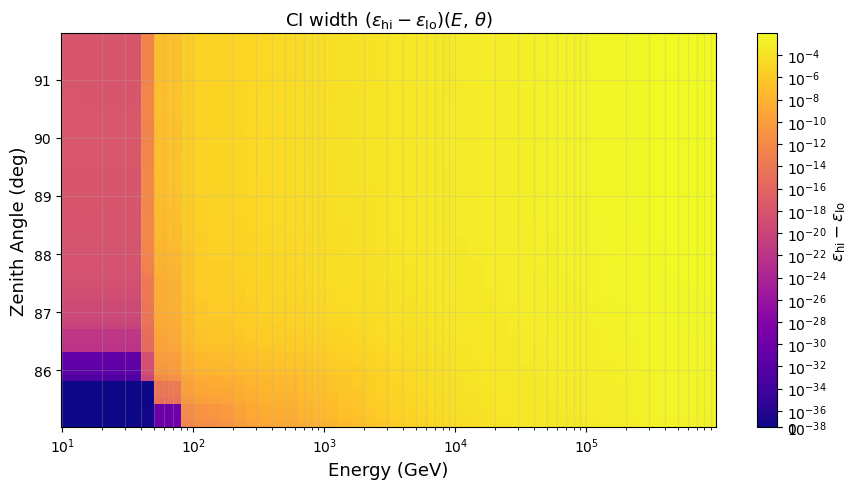

/tmp/ipykernel_1935720/1497762145.py:168: RuntimeWarning: divide by zero encountered in divide
  rel_err = np.where(eff_map > 0, eff_map_err / eff_map, np.nan)
/tmp/ipykernel_1935720/1497762145.py:168: RuntimeWarning: invalid value encountered in divide
  rel_err = np.where(eff_map > 0, eff_map_err / eff_map, np.nan)


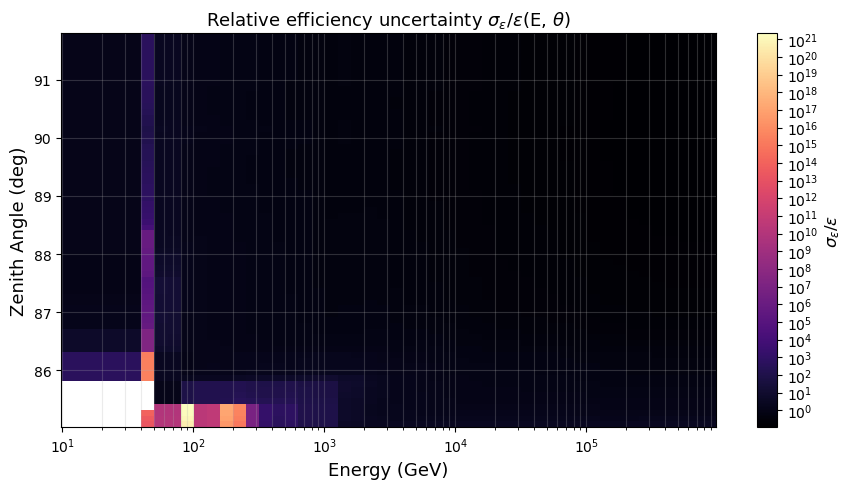

In [142]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm

in_path = '/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/data/eff_map_80_92deg.pkl'

with open(in_path, 'rb') as f:
    data = pickle.load(f)

zen_centers = data['zen_centers']
E_GeV       = data['E_GeV']
eff_map     = data['eff_map']
eff_map_lo  = data['eff_map_lo']
eff_map_hi  = data['eff_map_hi']
eff_map_err = data['eff_map_err']   # symmetric half-width

# Asymmetric half-widths for error bars
err_lo = np.clip(eff_map - eff_map_lo, 0, None)  # downward
err_hi = np.clip(eff_map_hi - eff_map, 0, None)  # upward

print(f"Zenith bins: {len(zen_centers)}  ({zen_centers[0]:.2f}° → {zen_centers[-1]:.2f}°)")
print(f"Energy bins: {len(E_GeV)}  ({E_GeV[0]:.2e} → {E_GeV[-1]:.2e} GeV)")
print(f"eff_map shape:     {eff_map.shape}")
print(f"eff_map_lo shape:  {eff_map_lo.shape}")
print(f"eff_map_hi shape:  {eff_map_hi.shape}")
print(f"eff_map_err shape: {eff_map_err.shape}")

def _symlog_norm(data, fallback=1e-12):
    pos = data[np.isfinite(data) & (data > 0)]
    linthresh = pos.min() if pos.size else fallback
    return SymLogNorm(linthresh=linthresh, linscale=np.min(data[np.where(data>0)]), base=10)
# =========================================================================
# 1a. Efficiency vs Zenith (line plot with asymmetric error bands)
# =========================================================================
fig, ax = plt.subplots(figsize=(8, 5))

# Pick a few energy bins to display (e.g., 5 evenly spaced across the array)
n_show_E = min(5, len(E_GeV))
idxs_E = np.linspace(0, len(E_GeV) - 1, n_show_E, dtype=int)

for j in idxs_E:
    # eff_map has shape (N_zenith, N_energy), so we slice [:, j] to get all zenith bins for energy j
    ax.errorbar(
        zen_centers, eff_map[:, j],
        yerr=[err_lo[:, j], err_hi[:, j]],          # asymmetric CI
        label=f"E = {E_GeV[j]:.2e} GeV",
        marker='.', markersize=3, linewidth=1,
        capsize=2, capthick=0.8, elinewidth=0.8,
    )

ax.set_yscale('log')
ax.set_ylim(1e-20, 1.5)
ax.set_xlabel('Zenith Angle (deg)', fontsize=13)
ax.set_ylabel('Efficiency (flux-weighted over H)', fontsize=13)
ax.set_title('Efficiency vs Zenith Angle (error bars = 68% CI)', fontsize=13)
ax.legend(fontsize=8)
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
plt.show()

# =========================================================================
# 1b. Efficiency vs Energy (line plot with asymmetric error bands)
# =========================================================================
fig, ax = plt.subplots(figsize=(8, 5))
n_show = min(5, len(zen_centers))
idxs = np.linspace(0, len(zen_centers) - 1, n_show, dtype=int)
for i in idxs:
    ax.errorbar(
        E_GeV, eff_map[i],
        yerr=[err_lo[i], err_hi[i]],          # asymmetric CI
        label=f"θ = {zen_centers[i]:.2f}°",
        marker='.', markersize=3, linewidth=1,
        capsize=2, capthick=0.8, elinewidth=0.8,
    )
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e-9, 1.5)
ax.set_xlabel('Energy [GeV]', fontsize=13)
ax.set_ylabel('Efficiency (flux-weighted over H)', fontsize=13)
ax.set_title('Efficiency vs Energy (error bars = 68% CI)', fontsize=13)
ax.legend(fontsize=8)
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
plt.show()

# =========================================================================
# 2. Efficiency 2D heatmap
# =========================================================================
n_contours = 6  # <-- user sets number of contour lines here

fig, ax = plt.subplots(figsize=(9, 5))
pcm = ax.pcolormesh(
    E_GeV, zen_centers, eff_map,
    shading='auto', cmap='terrain',
    norm=_symlog_norm(eff_map),
)

# --- contours in log scale ---
vmin = np.nanmin(eff_map[eff_map > 0])   # lowest positive value
vmax = np.nanmax(eff_map)
contour_levels = np.logspace(-8, -3, n_contours)

cs = ax.contour(
    E_GeV, zen_centers, eff_map,
    levels=contour_levels,
    colors='black',
    linewidths=0.8,
    alpha=0.7,
)
ax.clabel(cs, fmt='%.2e', fontsize=8, inline=True)

ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
ax.set_title(r'Efficiency map $\langle\varepsilon\rangle$(E, $\theta$) '
             r'[H-averaged, weighted by $d\Phi/dH$]', fontsize=13)
fig.colorbar(pcm, ax=ax).set_label('Efficiency', fontsize=12)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()


# =========================================================================
# 3a. Efficiency uncertainty 2D heatmap  (symmetric half-width)
# =========================================================================
fig, ax = plt.subplots(figsize=(9, 5))
pcm_err = ax.pcolormesh(
    E_GeV, zen_centers, eff_map_err,
    shading='auto', cmap='viridis',
    norm=_symlog_norm(eff_map_err),
)
ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
ax.set_title(r'Efficiency uncertainty $\frac{1}{2}(\varepsilon_\mathrm{hi}-\varepsilon_\mathrm{lo})$'
             r'$(E,\,\theta)$  [H-averaged]', fontsize=13)
fig.colorbar(pcm_err, ax=ax).set_label(
    r'$\frac{1}{2}(\varepsilon_\mathrm{hi}-\varepsilon_\mathrm{lo})$', fontsize=12)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()

# =========================================================================
# 3b. Asymmetric CI width: hi - lo
# =========================================================================
ci_width = np.clip(eff_map_hi - eff_map_lo, 0, None)
fig, ax = plt.subplots(figsize=(9, 5))
pcm_ci = ax.pcolormesh(
    E_GeV, zen_centers, ci_width,
    shading='auto', cmap='plasma',
    norm=_symlog_norm(ci_width),
)
ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
ax.set_title(r'CI width $(\varepsilon_\mathrm{hi}-\varepsilon_\mathrm{lo})$'
             r'$(E,\,\theta)$', fontsize=13)
fig.colorbar(pcm_ci, ax=ax).set_label(
    r'$\varepsilon_\mathrm{hi}-\varepsilon_\mathrm{lo}$', fontsize=12)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()

# =========================================================================
# 4. Relative uncertainty 2D heatmap  (sigma / eff)
# =========================================================================
rel_err = np.where(eff_map > 0, eff_map_err / eff_map, np.nan)

fig, ax = plt.subplots(figsize=(9, 5))
pcm_rel = ax.pcolormesh(
    E_GeV, zen_centers, rel_err,
    shading='auto', cmap='magma',
    norm=_symlog_norm(rel_err),
)
ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
ax.set_title(r'Relative efficiency uncertainty $\sigma_\varepsilon / \varepsilon$(E, $\theta$)',
             fontsize=13)
fig.colorbar(pcm_rel, ax=ax).set_label(
    r'$\sigma_\varepsilon / \varepsilon$', fontsize=12)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()


In [143]:
from scipy.interpolate import RegularGridInterpolator

# Build interpolators on log10(E), zenith
logE_grid = np.log10(E_GeV)

# Use log10(eff) for smoother interpolation; mask non-positive
def _build_log_eff_interp(eff_2d):
    safe = np.where(eff_2d > 0, eff_2d, np.nan)
    log_eff = np.log10(safe)
    return RegularGridInterpolator(
        (zen_centers, logE_grid), log_eff,
        method='linear', bounds_error=False, fill_value=None,
    )

_interp_eff    = _build_log_eff_interp(eff_map)
_interp_eff_lo = _build_log_eff_interp(eff_map_lo)
_interp_eff_hi = _build_log_eff_interp(eff_map_hi)

def n_events_for_one_trigger(E_GeV_query, zen_deg_query):
    """
    Estimate number of events that must be generated at given (E, zenith)
    to obtain on average 1 triggered event: N = 1 / efficiency.

    Parameters
    ----------
    E_GeV_query : float or array
        Energy in GeV.
    zen_deg_query : float or array
        Zenith angle in degrees.

    Returns
    -------
    dict with keys:
        'eff', 'eff_lo', 'eff_hi' : interpolated efficiency and 68% CI
        'N', 'N_lo', 'N_hi'       : required event count (N_hi from eff_lo, etc.)
    """
    E_q   = np.atleast_1d(E_GeV_query).astype(float)
    zen_q = np.atleast_1d(zen_deg_query).astype(float)
    pts = np.column_stack([zen_q, np.log10(E_q)])

    eff    = 10 ** _interp_eff(pts)
    eff_lo = 10 ** _interp_eff_lo(pts)
    eff_hi = 10 ** _interp_eff_hi(pts)

    with np.errstate(divide='ignore', invalid='ignore'):
        N    = 1.0 / eff
        N_lo = 1.0 / eff_hi   # high eff -> low N
        N_hi = 1.0 / eff_lo   # low  eff -> high N

    return {
        'E_GeV':  E_q,
        'zen':    zen_q,
        'eff':    eff,
        'eff_lo': eff_lo,
        'eff_hi': eff_hi,
        'N':      N,
        'N_lo':   N_lo,
        'N_hi':   N_hi,
    }


# ---------- example usage ----------
E_query   = [0.5e6, 1e5, 2e1]      # GeV
zen_query = [86, 89.0, 91.0]     # deg

for E, z in zip(E_query, zen_query):
    r = n_events_for_one_trigger(E, z)
    print(f"E = {E:.2e} GeV, θ = {z:.2f}°  ->  "
          f"eff = {r['eff'][0]:.3e} "
          f"[{r['eff_lo'][0]:.2e}, {r['eff_hi'][0]:.2e}],  "
          f"N_needed = {r['N'][0]:.3e} "
          f"[{r['N_lo'][0]:.2e}, {r['N_hi'][0]:.2e}]")


E = 5.00e+05 GeV, θ = 86.00°  ->  eff = 3.453e-03 [2.40e-03, 6.06e-03],  N_needed = 2.896e+02 [1.65e+02, 4.16e+02]
E = 1.00e+05 GeV, θ = 89.00°  ->  eff = 8.957e-03 [7.80e-03, 1.06e-02],  N_needed = 1.116e+02 [9.42e+01, 1.28e+02]
E = 2.00e+01 GeV, θ = 91.00°  ->  eff = 5.561e-19 [1.74e-19, 1.45e-18],  N_needed = 1.798e+18 [6.90e+17, 5.75e+18]


In [144]:
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import distance_transform_edt

# =========================================================================
# Build (Energy, Zenith) grid of runtime statistics
# =========================================================================
Zen_list = np.sort(np.unique(Zenith))
E_arr    = np.asarray(E_list, dtype=float)

runtime_mean  = np.full((len(E_arr), len(Zen_list)), np.nan)
filesize_mean = np.full((len(E_arr), len(Zen_list)), np.nan)

runtime_band_lo = {c: np.full_like(runtime_mean, np.nan) for c in coverages}
runtime_band_hi = {c: np.full_like(runtime_mean, np.nan) for c in coverages}

for i, E in enumerate(E_arr):
    for j, z in enumerate(Zen_list):
        m = (Energy_GeV == E) & (Zenith == z)
        if not m.any():
            continue
        runtime_mean[i, j]  = np.nanmean(runtime_hours[m])
        filesize_mean[i, j] = np.nanmean(file_size[m])
        for cov in coverages:
            lo_p = (100 - cov) / 2
            hi_p = 100 - lo_p
            runtime_band_lo[cov][i, j] = np.nanpercentile(runtime_hours[m], lo_p)
            runtime_band_hi[cov][i, j] = np.nanpercentile(runtime_hours[m], hi_p)

# =========================================================================
# Nearest-neighbor fill for NaN cells
# =========================================================================
def nn_fill(grid_2d):
    """Replace NaN entries by the value of the nearest non-NaN cell (in index space)."""
    arr = np.asarray(grid_2d, dtype=float).copy()
    mask = np.isnan(arr)
    if not mask.any():
        return arr
    if mask.all():
        return arr  # nothing to fill from
    # Indices of nearest non-NaN cell
    _, (ii, jj) = distance_transform_edt(mask, return_indices=True)
    arr[mask] = arr[ii[mask], jj[mask]]
    return arr

runtime_mean  = nn_fill(runtime_mean)
filesize_mean = nn_fill(filesize_mean)
for cov in coverages:
    runtime_band_lo[cov] = nn_fill(runtime_band_lo[cov])
    runtime_band_hi[cov] = nn_fill(runtime_band_hi[cov])

# =========================================================================
# Interpolators on (log10 E, Zenith). Use log10 of runtime for smoothness.
# =========================================================================
logE_axis = np.log10(E_arr)

def _make_interp(grid_2d, log_y=True):
    vals = np.log10(grid_2d) if log_y else grid_2d.copy()
    return RegularGridInterpolator(
        (logE_axis, Zen_list), vals,
        method='linear', bounds_error=False, fill_value=None,
    )

_interp_runtime    = _make_interp(runtime_mean,  log_y=True)
_interp_filesize   = _make_interp(filesize_mean, log_y=True)
_interp_runtime_lo = {c: _make_interp(runtime_band_lo[c], log_y=True) for c in coverages}
_interp_runtime_hi = {c: _make_interp(runtime_band_hi[c], log_y=True) for c in coverages}

def runtime_per_event(E_GeV_query, zen_deg_query, coverage=None):
    E_q   = np.atleast_1d(E_GeV_query).astype(float)
    zen_q = np.atleast_1d(zen_deg_query).astype(float)
    pts = np.column_stack([np.log10(E_q), zen_q])

    out = {
        'E_GeV':       E_q,
        'zen':         zen_q,
        'runtime_hr':  10 ** _interp_runtime(pts),
        'filesize_MB': 10 ** _interp_filesize(pts),
    }
    if coverage is not None:
        if coverage not in coverages:
            raise ValueError(f"coverage must be one of {coverages}")
        out['runtime_lo'] = 10 ** _interp_runtime_lo[coverage](pts)
        out['runtime_hi'] = 10 ** _interp_runtime_hi[coverage](pts)
    return out

def cpu_hours_per_trigger(E_GeV_query, zen_deg_query, coverage=95):
    rt = runtime_per_event(E_GeV_query, zen_deg_query, coverage=coverage)
    ne = n_events_for_one_trigger(E_GeV_query, zen_deg_query)
    return {
        **rt,
        'N_needed':  ne['N'],
        'cpu_hr':    ne['N']    * rt['runtime_hr'],
        'cpu_hr_lo': ne['N_lo'] * rt['runtime_lo'],
        'cpu_hr_hi': ne['N_hi'] * rt['runtime_hi'],
    }

# ---------- example ----------
E_query   = [1e3, 1e4, 1e5]
zen_query = [85.0, 89.0, 91.0]
for E, z in zip(E_query, zen_query):
    r = runtime_per_event(E, z, coverage=95)
    print(f"E={E:.1e} GeV, θ={z:.1f}°  ->  "
          f"runtime = {r['runtime_hr'][0]:.3e} hr "
          f"[{r['runtime_lo'][0]:.2e}, {r['runtime_hi'][0]:.2e}],  "
          f"file = {r['filesize_MB'][0]:.2f} MB")


/tmp/ipykernel_1935720/777851050.py:21: RuntimeWarning: Mean of empty slice
  runtime_mean[i, j]  = np.nanmean(runtime_hours[m])


E=1.0e+03 GeV, θ=85.0°  ->  runtime = 2.382e-02 hr [2.08e-02, 2.97e-02],  file = 0.80 MB
E=1.0e+04 GeV, θ=89.0°  ->  runtime = 4.127e-02 hr [2.52e-02, 6.42e-02],  file = 3.25 MB
E=1.0e+05 GeV, θ=91.0°  ->  runtime = 2.111e-02 hr [1.98e-02, 2.24e-02],  file = 0.12 MB


Energy:1.122020e+01 , Number of Seed 3255144150609832960 49447186366059632
Number of event per Energy: 5468642173024519372800 83071273094980181760
Total runtime per event 4.009164865762854e+20
Total Sim time 1.0022912164407136e+17 hours
 
Energy:1.412540e+01 , Number of Seed 3249999618706067968 49482960515669696
Number of event per Energy: 5459999359426194186240 83131373666325089280
Total runtime per event 4.002828655873192e+20
Total Sim time 1.0007071639682981e+17 hours
 
Energy:1.778280e+01 , Number of Seed 3256024806371163136 49441200773767888
Number of event per Energy: 5470121674703554068480 83061217299930051840
Total runtime per event 4.010249516387772e+20
Total Sim time 1.002562379096943e+17 hours
 
Energy:2.238720e+01 , Number of Seed 3251854312569988608 49470250126443600
Number of event per Energy: 5463115245117580861440 83110020212425248000
Total runtime per event 4.0051129705246904e+20
Total Sim time 1.0012782426311726e+17 hours
 
Energy:2.818380e+01 , Number of Seed 3243921

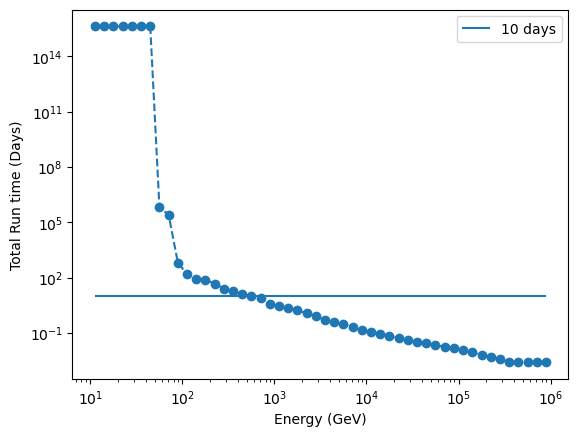

In [145]:
zeniths = [f"{z:.1f}" for z in np.arange(87.0, 90.0, 0.3)] #
zeniths_full = [f"{z:.1f}" for z in np.arange(86.1, 89.9, 0.3)]
if "89.9" not in zeniths:
    zeniths.append("89.9")
    zeniths_full.append("89.9")
zeniths_extended = list(set(zeniths_full)-set(zeniths))

azimuths = [f"{a:.1f}" for a in np.arange(267.0, 273.3, 0.3)] #["270.0"]#
azimuths_full = [f"{a:.1f}" for a in np.arange(266.1, 274.3, 0.3)]
azimuths_extended = list(set(azimuths_full) - set(azimuths)) 
T_sim = []
for e in E_list:
    Num_job = 200
    time_per_job = 20
    Zen = zeniths
    N_zen = len(zeniths_extended)
    N_azimuth = len(azimuths_full)
    N_h = 20
    N_min = n_events_for_one_trigger(e, Zen[0])['N'][0]
    N_max = n_events_for_one_trigger(e, Zen[-1])['N'][0]
    T_min = runtime_per_event(E, Zen[0], coverage=95)['runtime_hr'][0]
    T_max = runtime_per_event(E, Zen[-1], coverage=95)['runtime_hr'][0]
    T_mean = (T_min+T_max)/2
    num_seed_min = int(N_min/N_azimuth)
    num_seed_max = int(N_max/N_azimuth)
    Total_Sim_Time =  (N_zen*N_azimuth*20*num_seed_min*T_max/(Num_job*time_per_job))
    print(f"Energy:{e:e}",", Number of Seed", num_seed_min, num_seed_max)
    print("Number of event per Energy:", N_zen*len(azimuths_full)*N_h*num_seed_min, N_zen*len(azimuths_full)*20*num_seed_max)
    print("Total runtime per event", N_zen*len(azimuths_full)*N_h*num_seed_min*T_max)
    print(f"Total Sim time", Total_Sim_Time, "hours")
    print(" ")
    T_sim.append(Total_Sim_Time)

plt.plot(E_list, np.array(T_sim)/(24),"--o")
plt.hlines(10, min(E_list), max(E_list), label="10 days")
plt.xlabel("Energy (GeV)")
plt.ylabel("Total Run time (Days)")
plt.loglog()
plt.legend()